In [1]:
import pandas
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import h5py

import chroma

plt.style.use("chroma.tex")

# nuclear bodies as fields

## chr1


In [23]:
chromosome = 1
folder_num = 4 if chromosome == 1 else 5

data_path = f"/scratch/mm146/Polarization/{folder_num}_IMR-90_hg38_chr{chromosome}/4_analysis/msd/data/msd-average-per-compartment.h5"

In [24]:
msd = {}
with h5py.File(
    data_path,
    "r",
) as f_in:
    for condition in f_in.keys():
        msd[condition] = {}
        for compartment in f_in[condition].keys():
            msd[condition][compartment] = f_in[condition][
                compartment
            ][()]

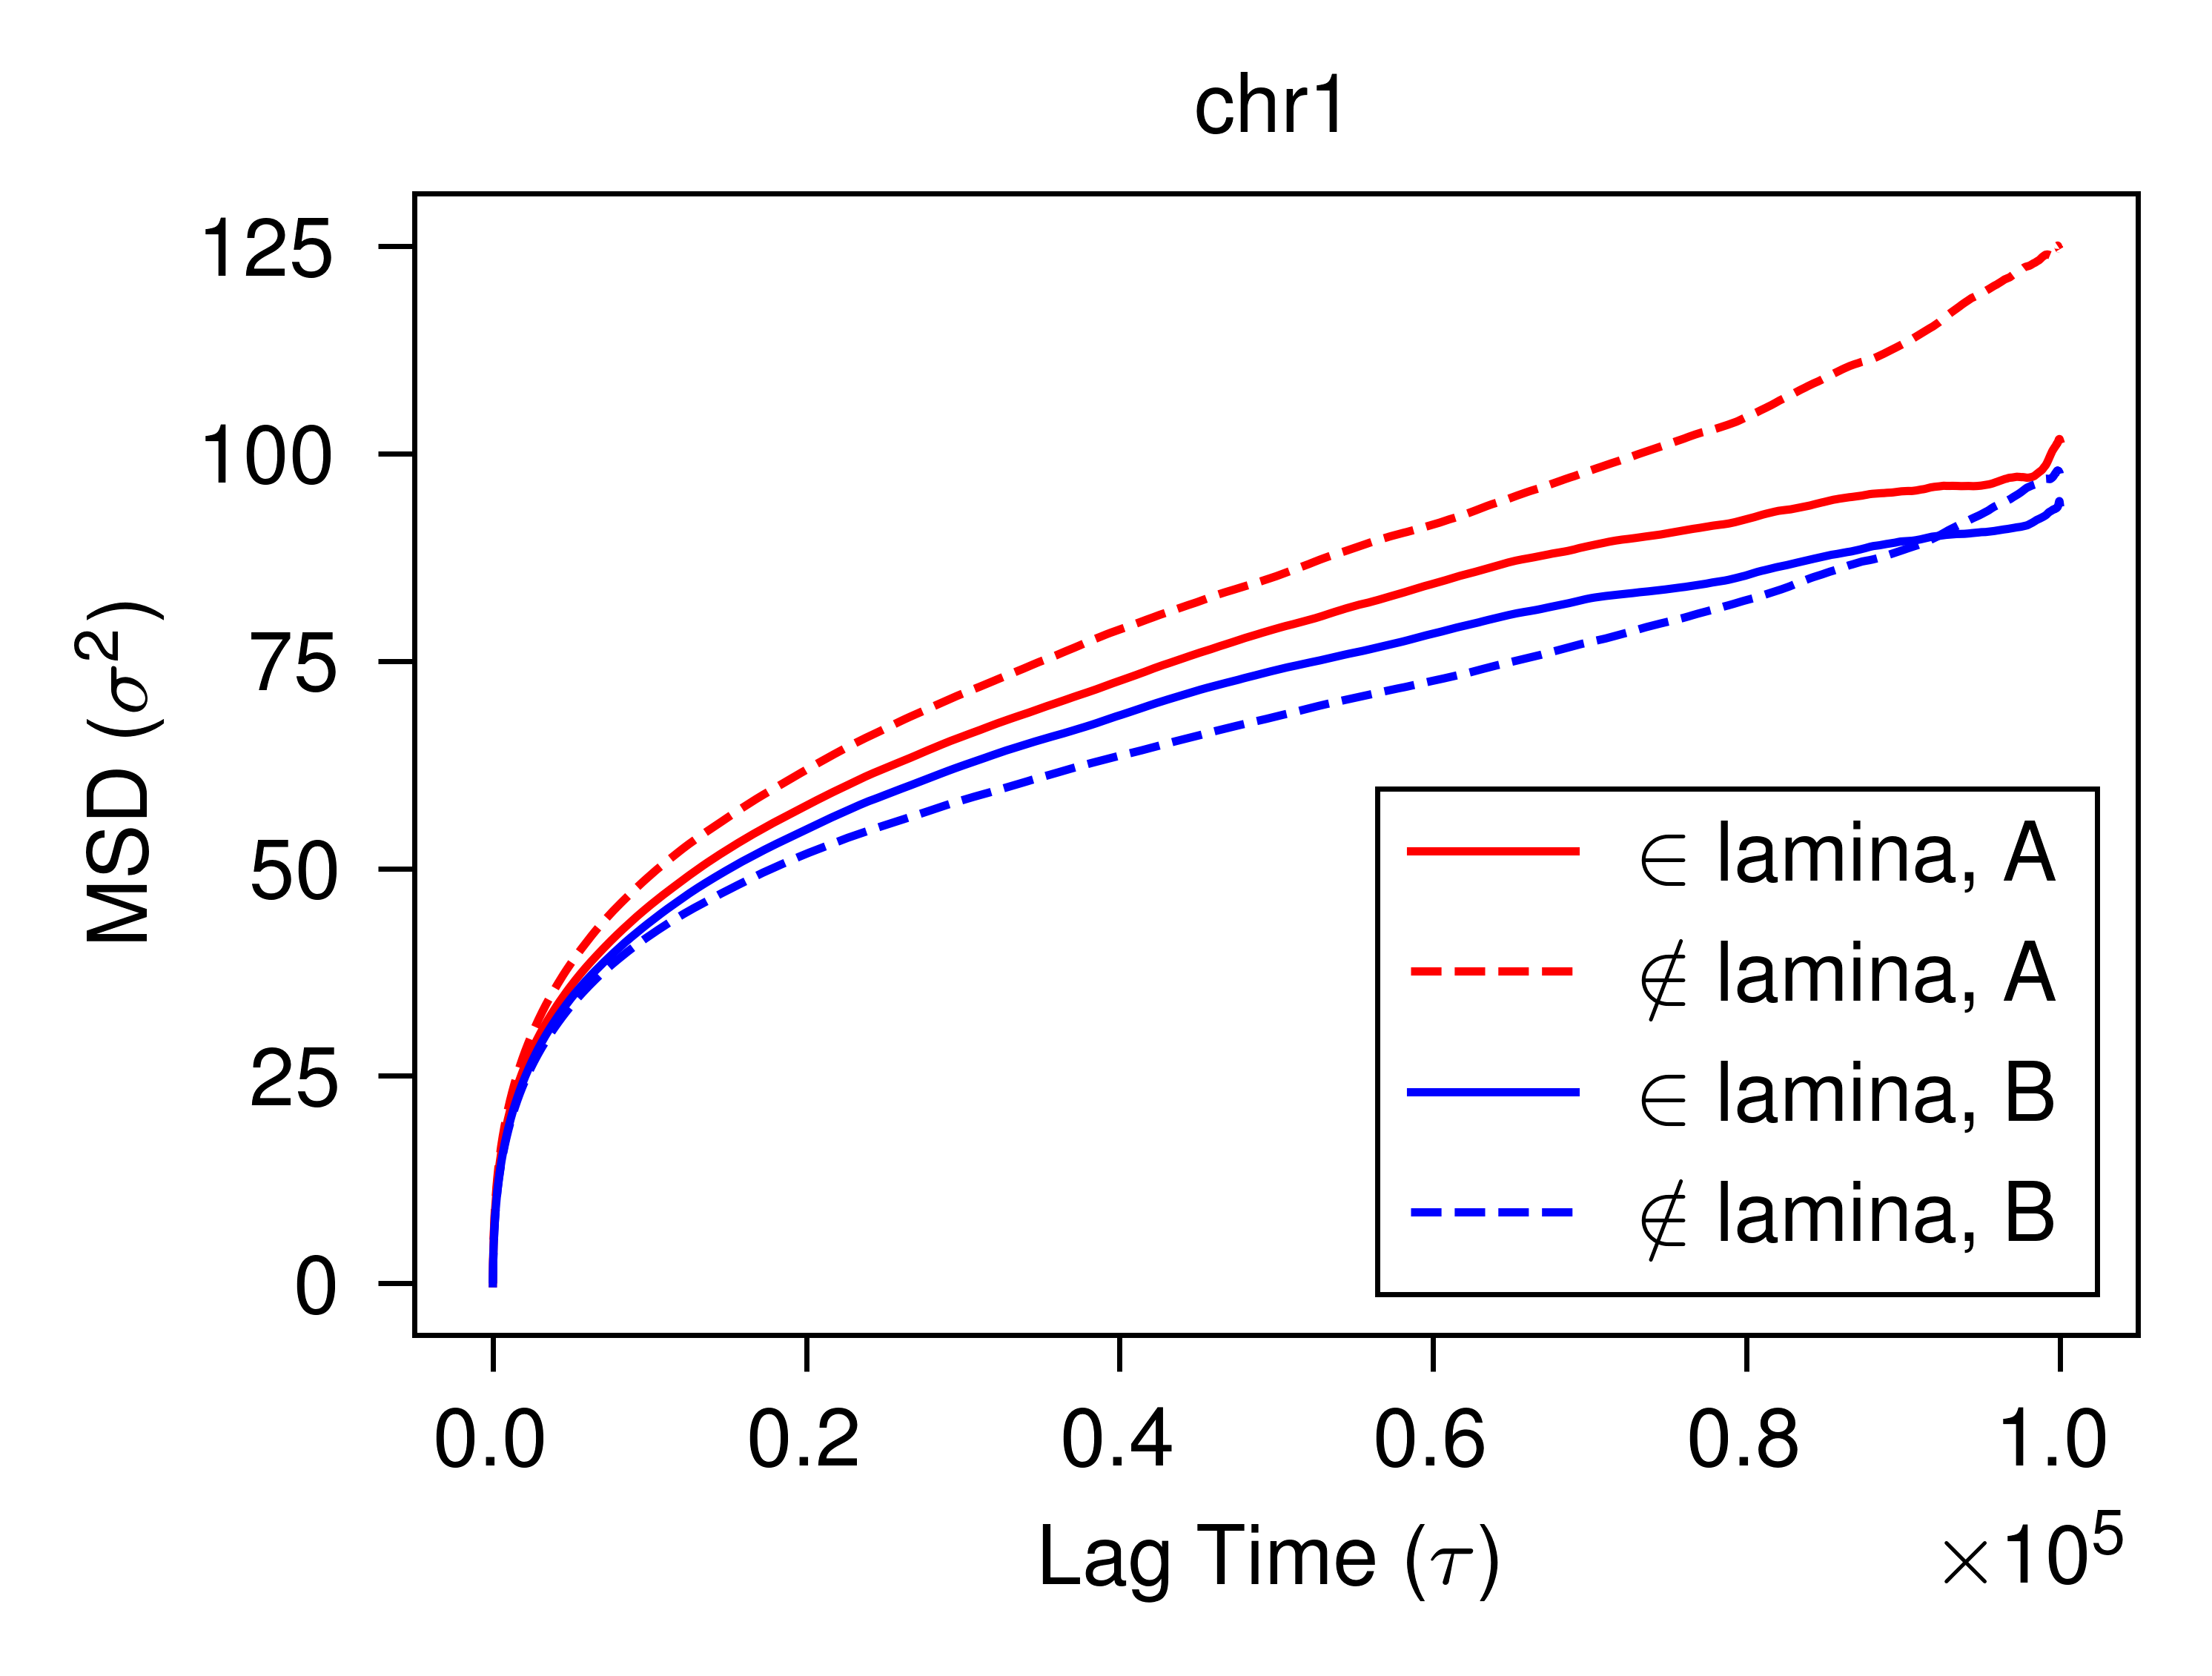

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

lag = np.arange(msd["complete"]["A"].shape[0]) * 1000 * 0.01  # in tau

ax.plot(
    lag,
    msd["complete"]["A"],
    label=r"$\in$ lamina, A",
    color="red",
)
ax.plot(
    lag,
    msd["nucleolus"]["A"],
    "--",
    label=r"$\notin$ lamina, A",
    color="red",
)
ax.plot(
    lag,
    msd["complete"]["B"],
    label=r"$\in$ lamina, B",
    color="blue",
)
ax.plot(
    lag,
    msd["nucleolus"]["B"],
    "--",
    label=r"$\notin$ lamina, B",
    color="blue",
)

ax.set_ylabel(r"MSD ($\sigma^2$)")
ax.set_xlabel(r"Lag Time ($\tau$)")

ax.legend()

ax.set_title(f"chr{chromosome}", fontsize=8)

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation
ax.xaxis.set_major_formatter(formatter)

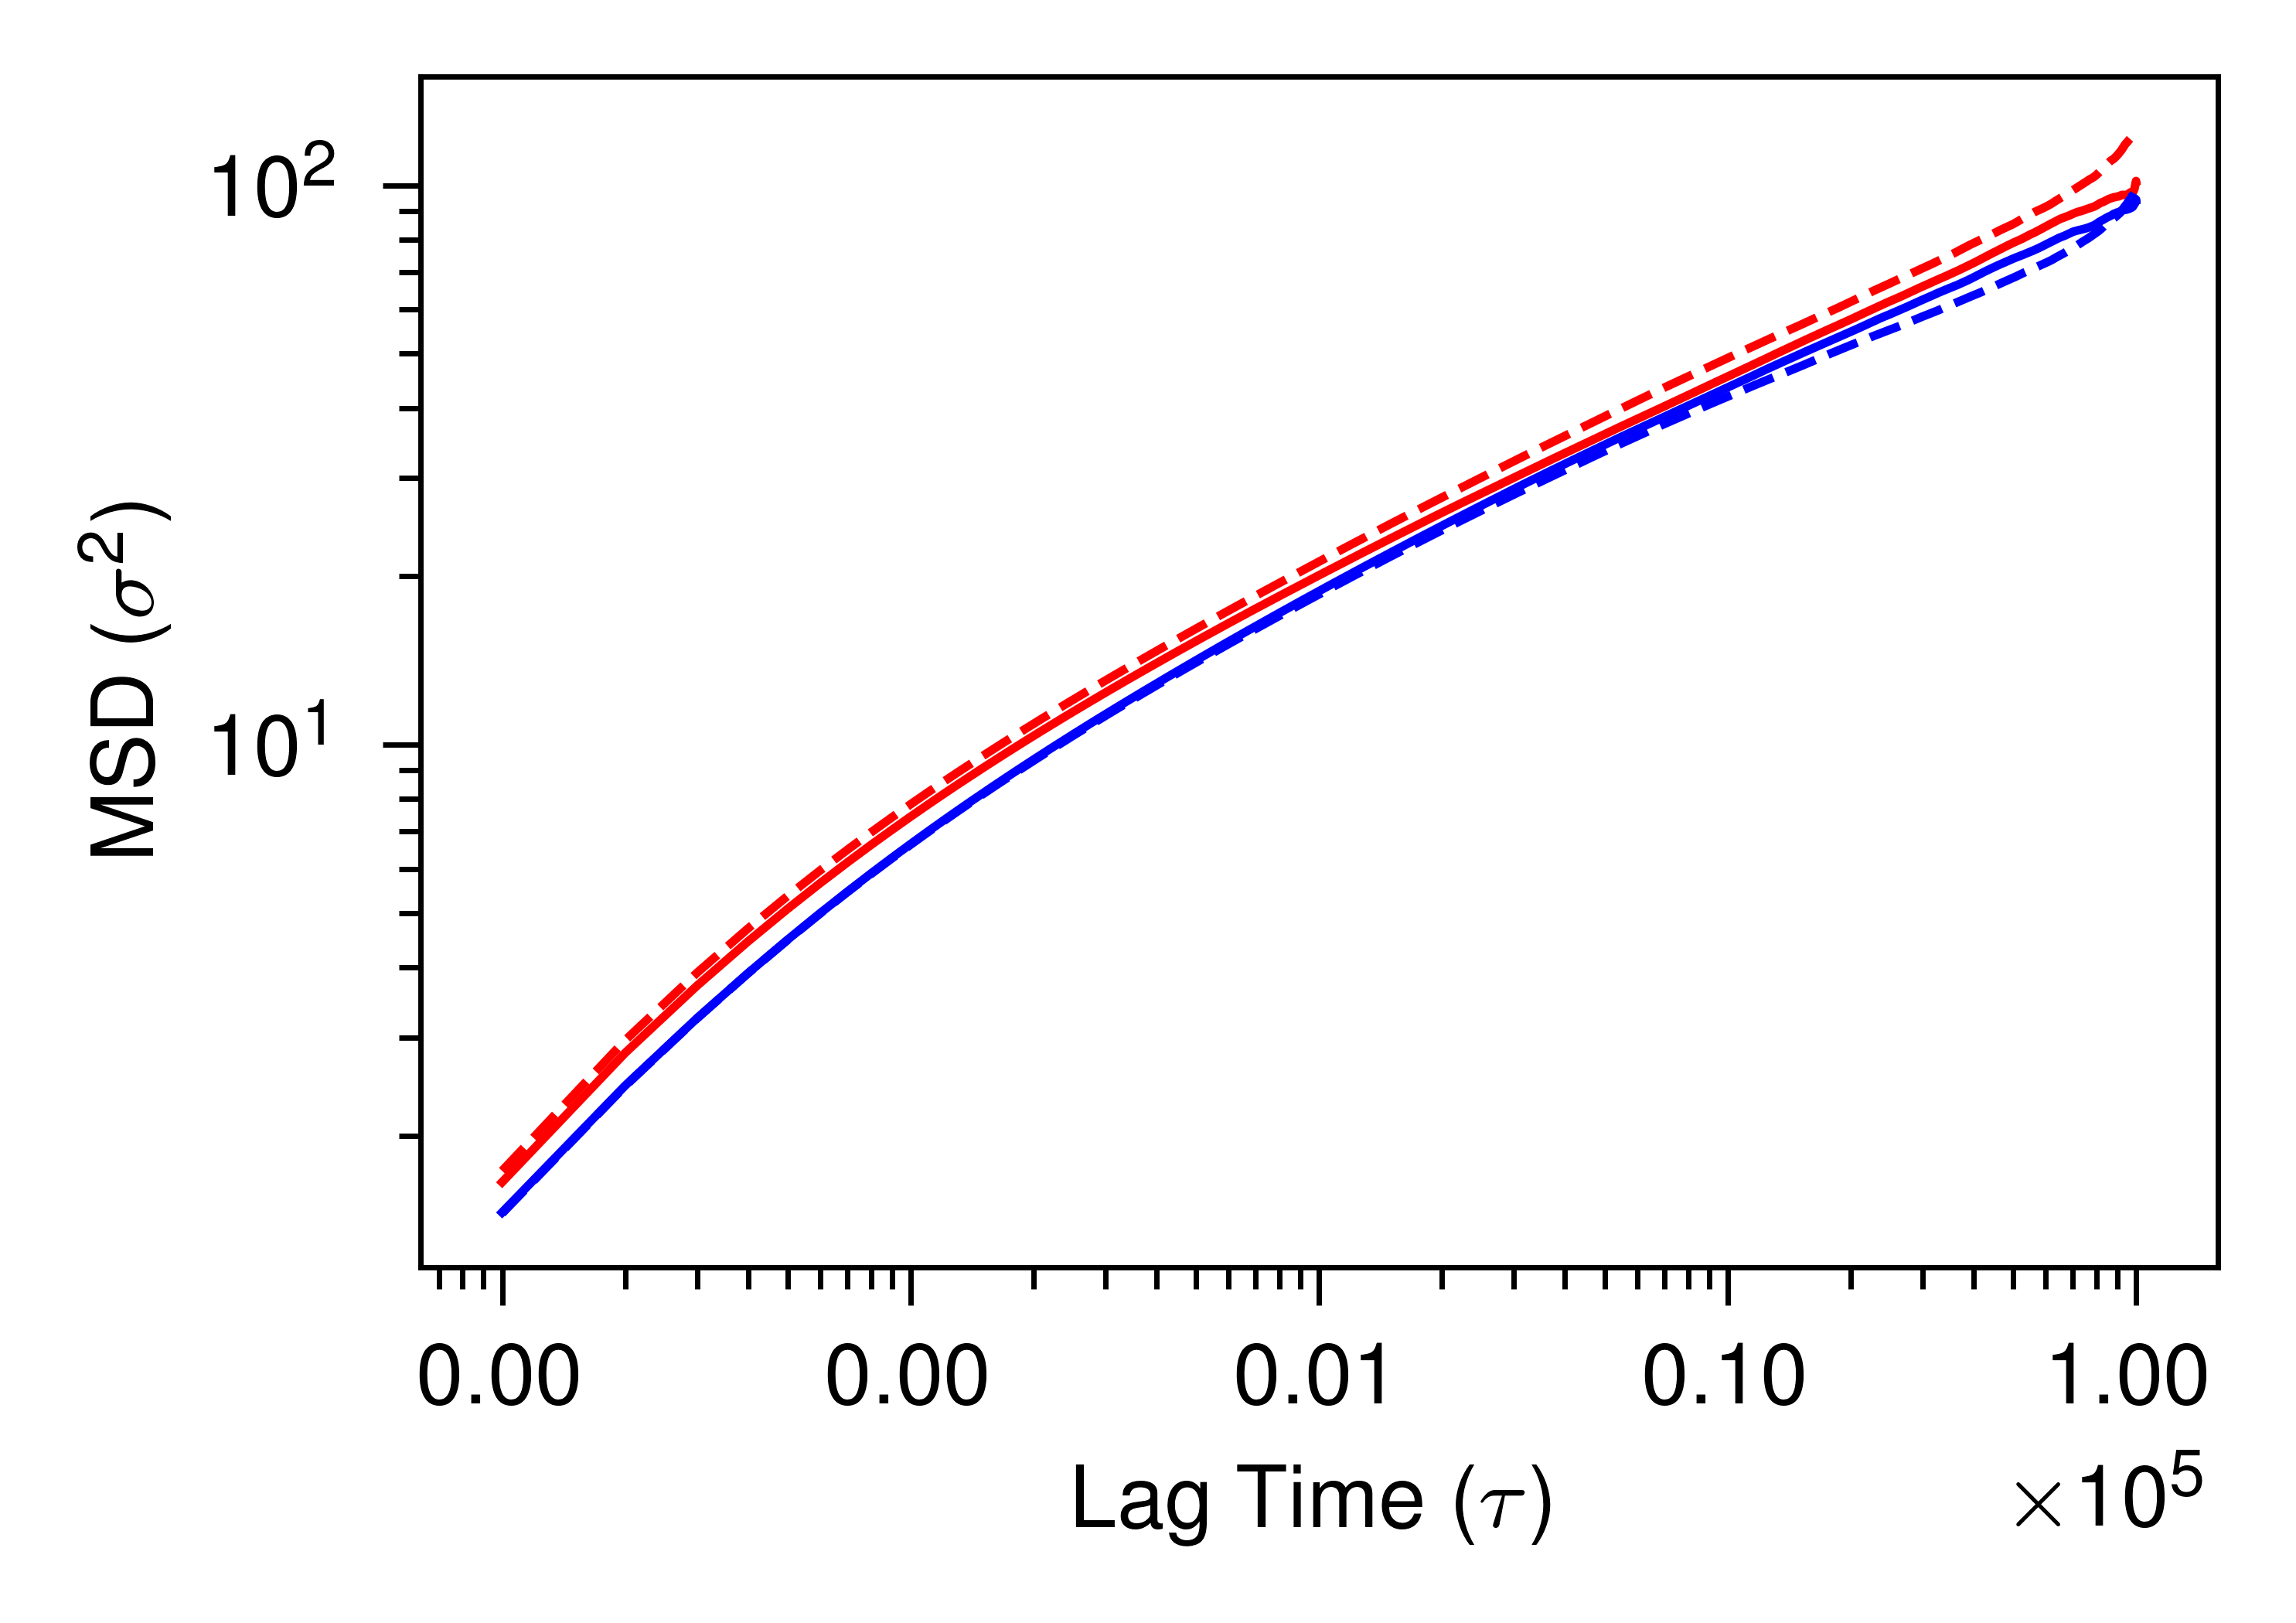

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

lag = np.arange(msd["complete"]["A"].shape[0]) * 1000 * 0.01  # in tau

ax.loglog(
    lag[1:],
    msd["complete"]["A"][1:],
    label="A",
    color="red",
)
ax.loglog(
    lag[1:],
    msd["nucleolus"]["A"][1:],
    "--",
    label="A",
    color="red",
)
ax.loglog(
    lag[1:],
    msd["complete"]["B"][1:],
    label="B",
    color="blue",
)
ax.loglog(
    lag[1:],
    msd["nucleolus"]["B"][1:],
    "--",
    label="B",
    color="blue",
)

ax.set_ylabel(r"MSD ($\sigma^2$)")
ax.set_xlabel(r"Lag Time ($\tau$)")

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation

# Apply formatter
ax.xaxis.set_major_formatter(formatter)

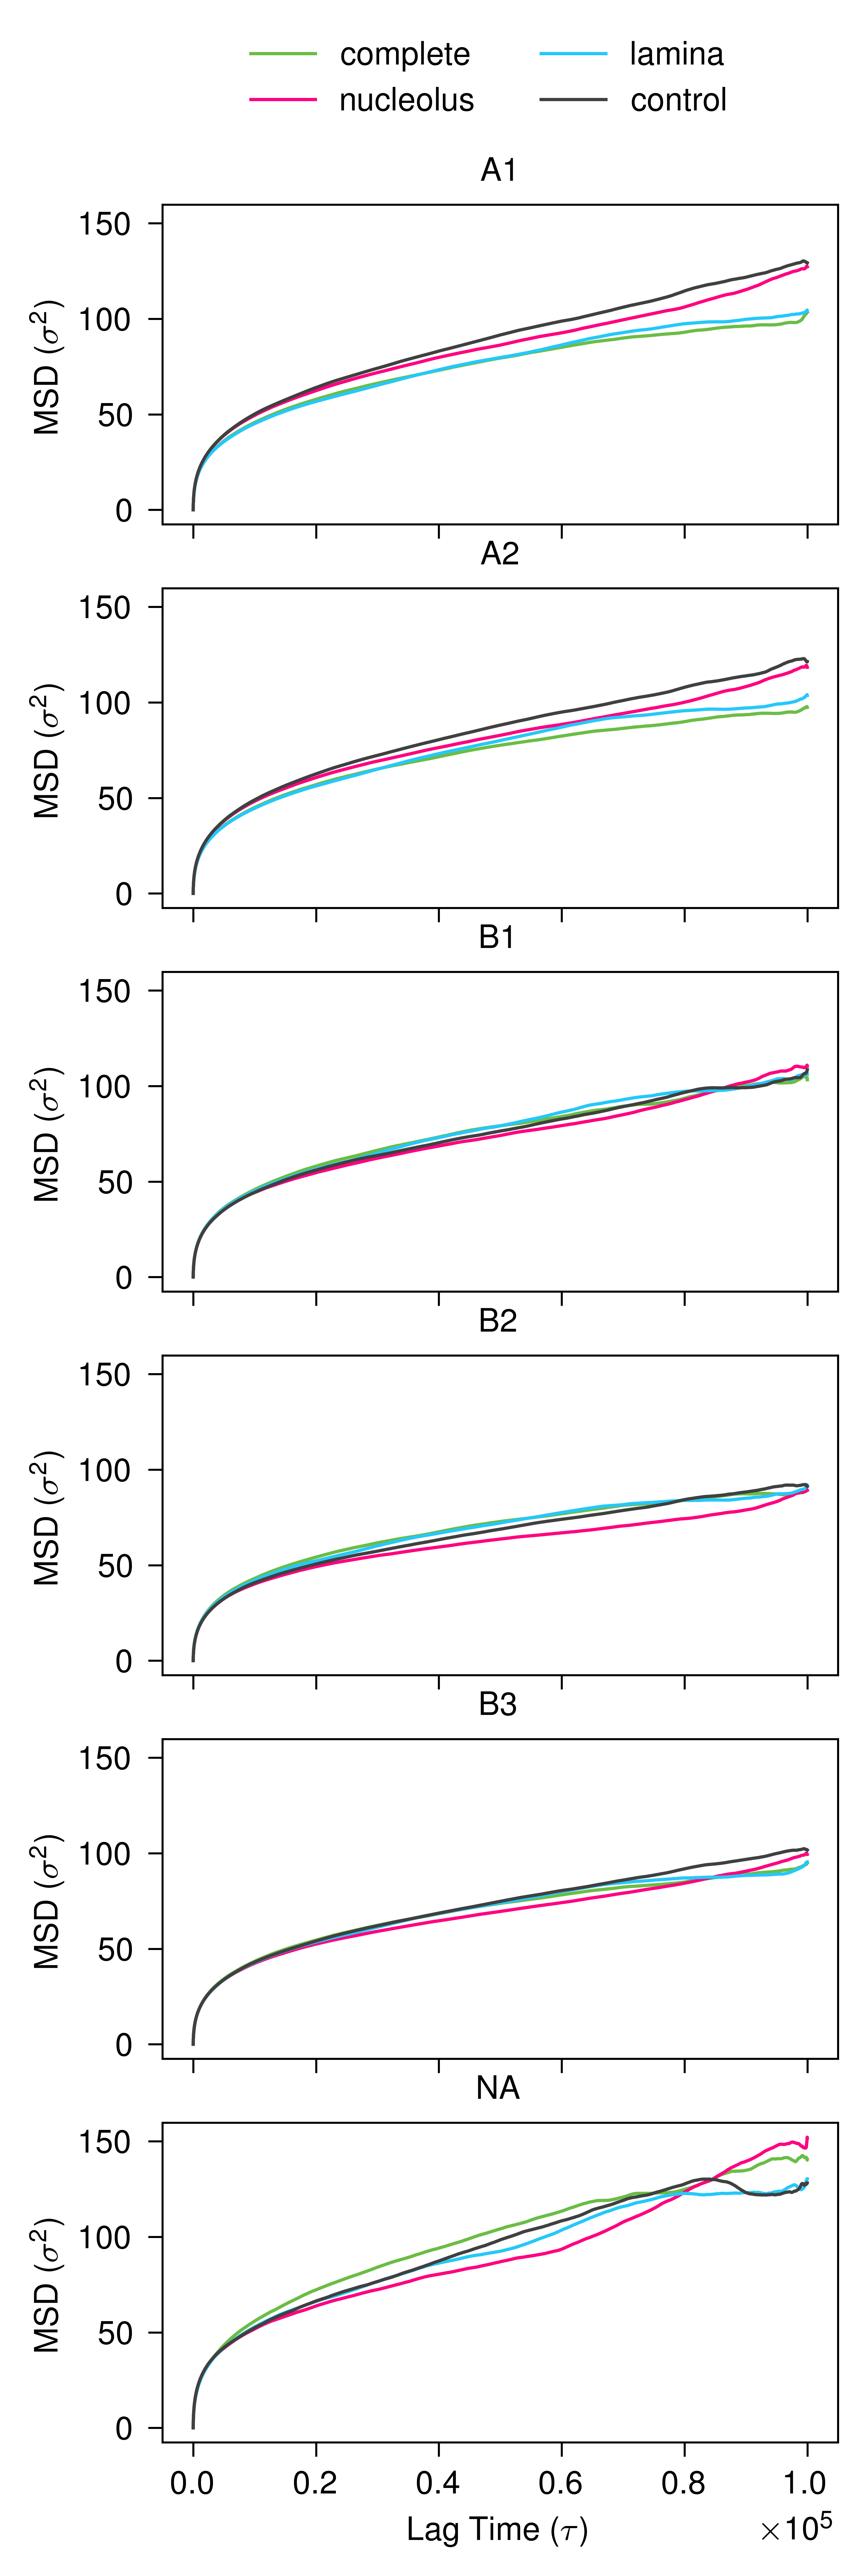

In [27]:
fig, ax = plt.subplots(
    6, 1, figsize=(3, 10), sharex=True, sharey=True
)

lag = np.arange(msd["complete"]["A"].shape[0]) * 1000 * 0.01  # in tau

conditions = ["complete", "nucleolus", "lamina", "control"]

colors = {
    "complete": "#6abd45",
    "nucleolus": "#ff0080",
    "control": "#404040",
    "lamina": "#25C8FA",
    # "isolation": "#FFC083",
}

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation

for i, subcompartment in enumerate(
    ["A1", "A2", "B1", "B2", "B3", "NA"]
):
    for condition in conditions:
        ax[i].plot(
            lag,
            msd[condition][subcompartment],
            label=condition,
            color=colors[condition],
        )

    ax[i].set_title(f"{subcompartment}")
    ax[i].set_ylabel(r"MSD ($\sigma^2$)")
    if i == 5:
        ax[i].set_xlabel(r"Lag Time ($\tau$)")

    ax[i].xaxis.set_major_formatter(formatter)

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.9),
)

### lamina contact

In [31]:
data_path_lamina = f"/scratch/mm146/Polarization/{folder_num}_IMR-90_hg38_chr{chromosome}/4_analysis/msd/data/msd-average-per-compartment-lamina.h5"

msd_lamina = {}
with h5py.File(
    data_path_lamina,
    "r",
) as f_in:
    for group in f_in.keys():
        msd_lamina[group] = {}
        for compartment in f_in[group].keys():
            msd_lamina[group][compartment] = f_in[group][
                compartment
            ][()]

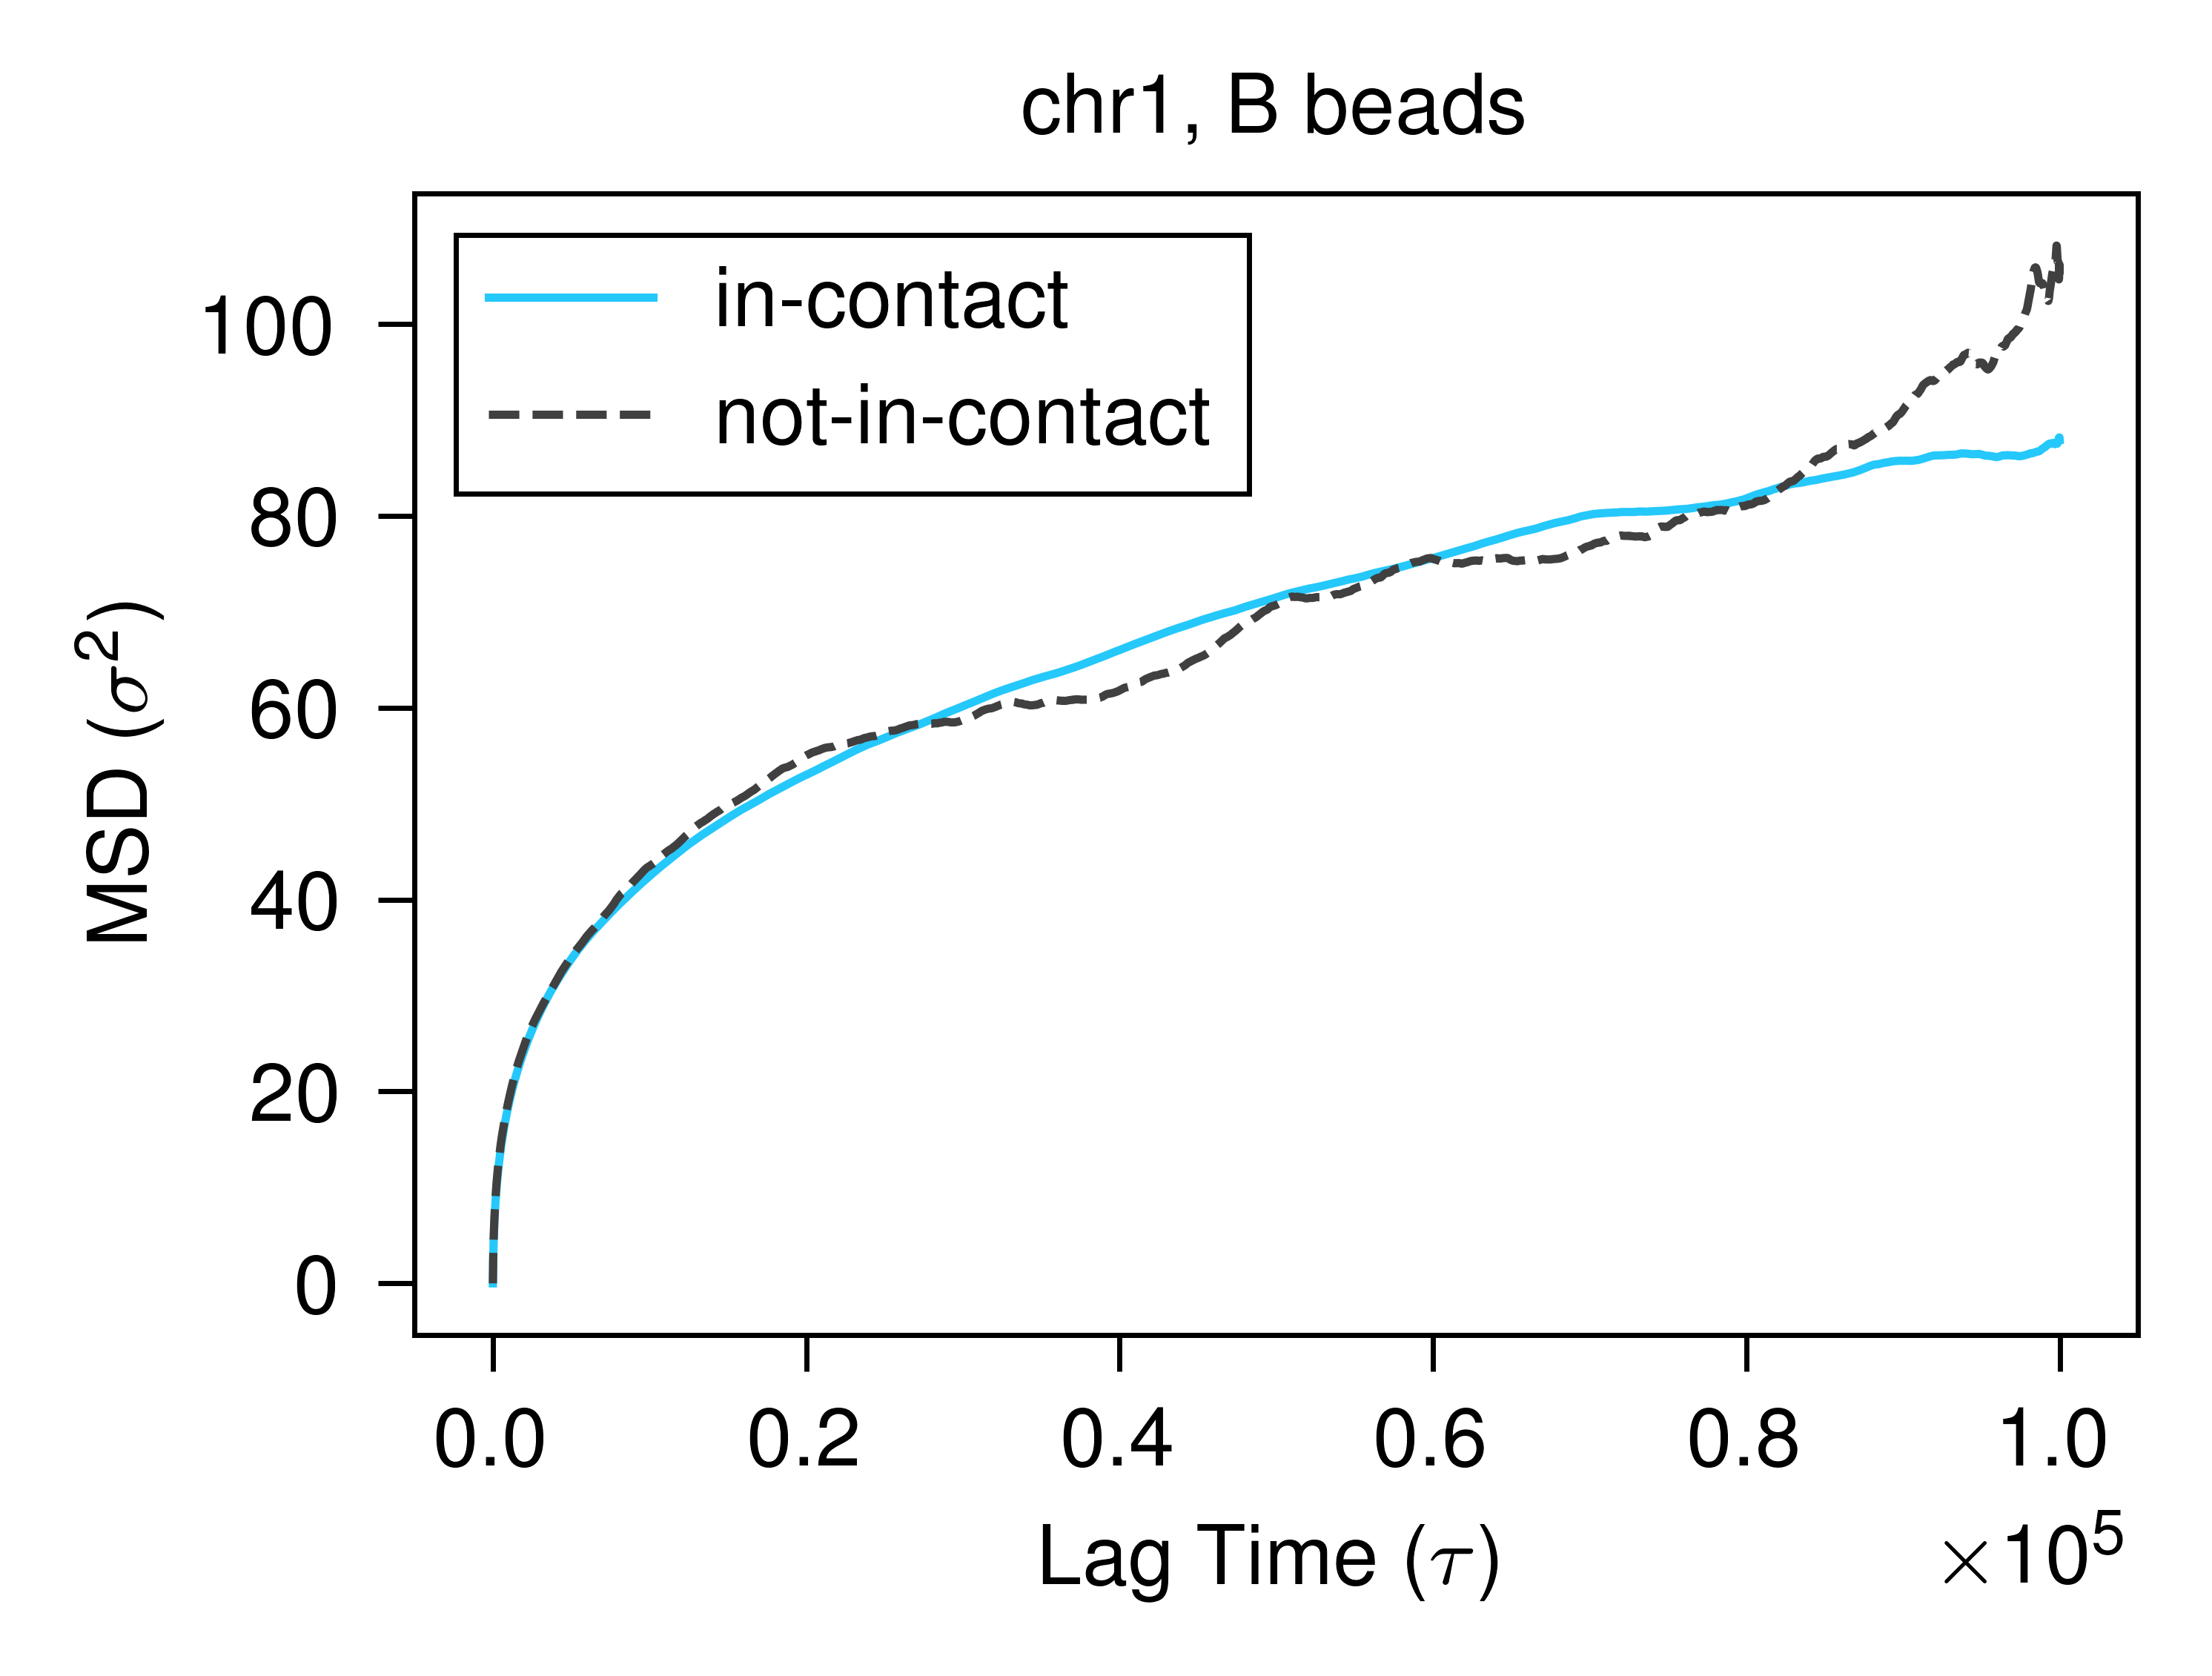

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

lag = np.arange(msd_lamina["in-contact"]["B"].shape[0]) * 1000 * 0.01  # in tau

ax.plot(
    lag,
    msd_lamina["in-contact"]["B"],
    label="in-contact",
    color="#25C8FA",
)
ax.plot(
    lag,
    msd_lamina["not-in-contact"]["B"],
    "--",
    label="not-in-contact",
    color="#404040",
)

ax.set_ylabel(r"MSD ($\sigma^2$)")
ax.set_xlabel(r"Lag Time ($\tau$)")

ax.legend()

ax.set_title(f"chr{chromosome}, B beads", fontsize=8)

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation
ax.xaxis.set_major_formatter(formatter)

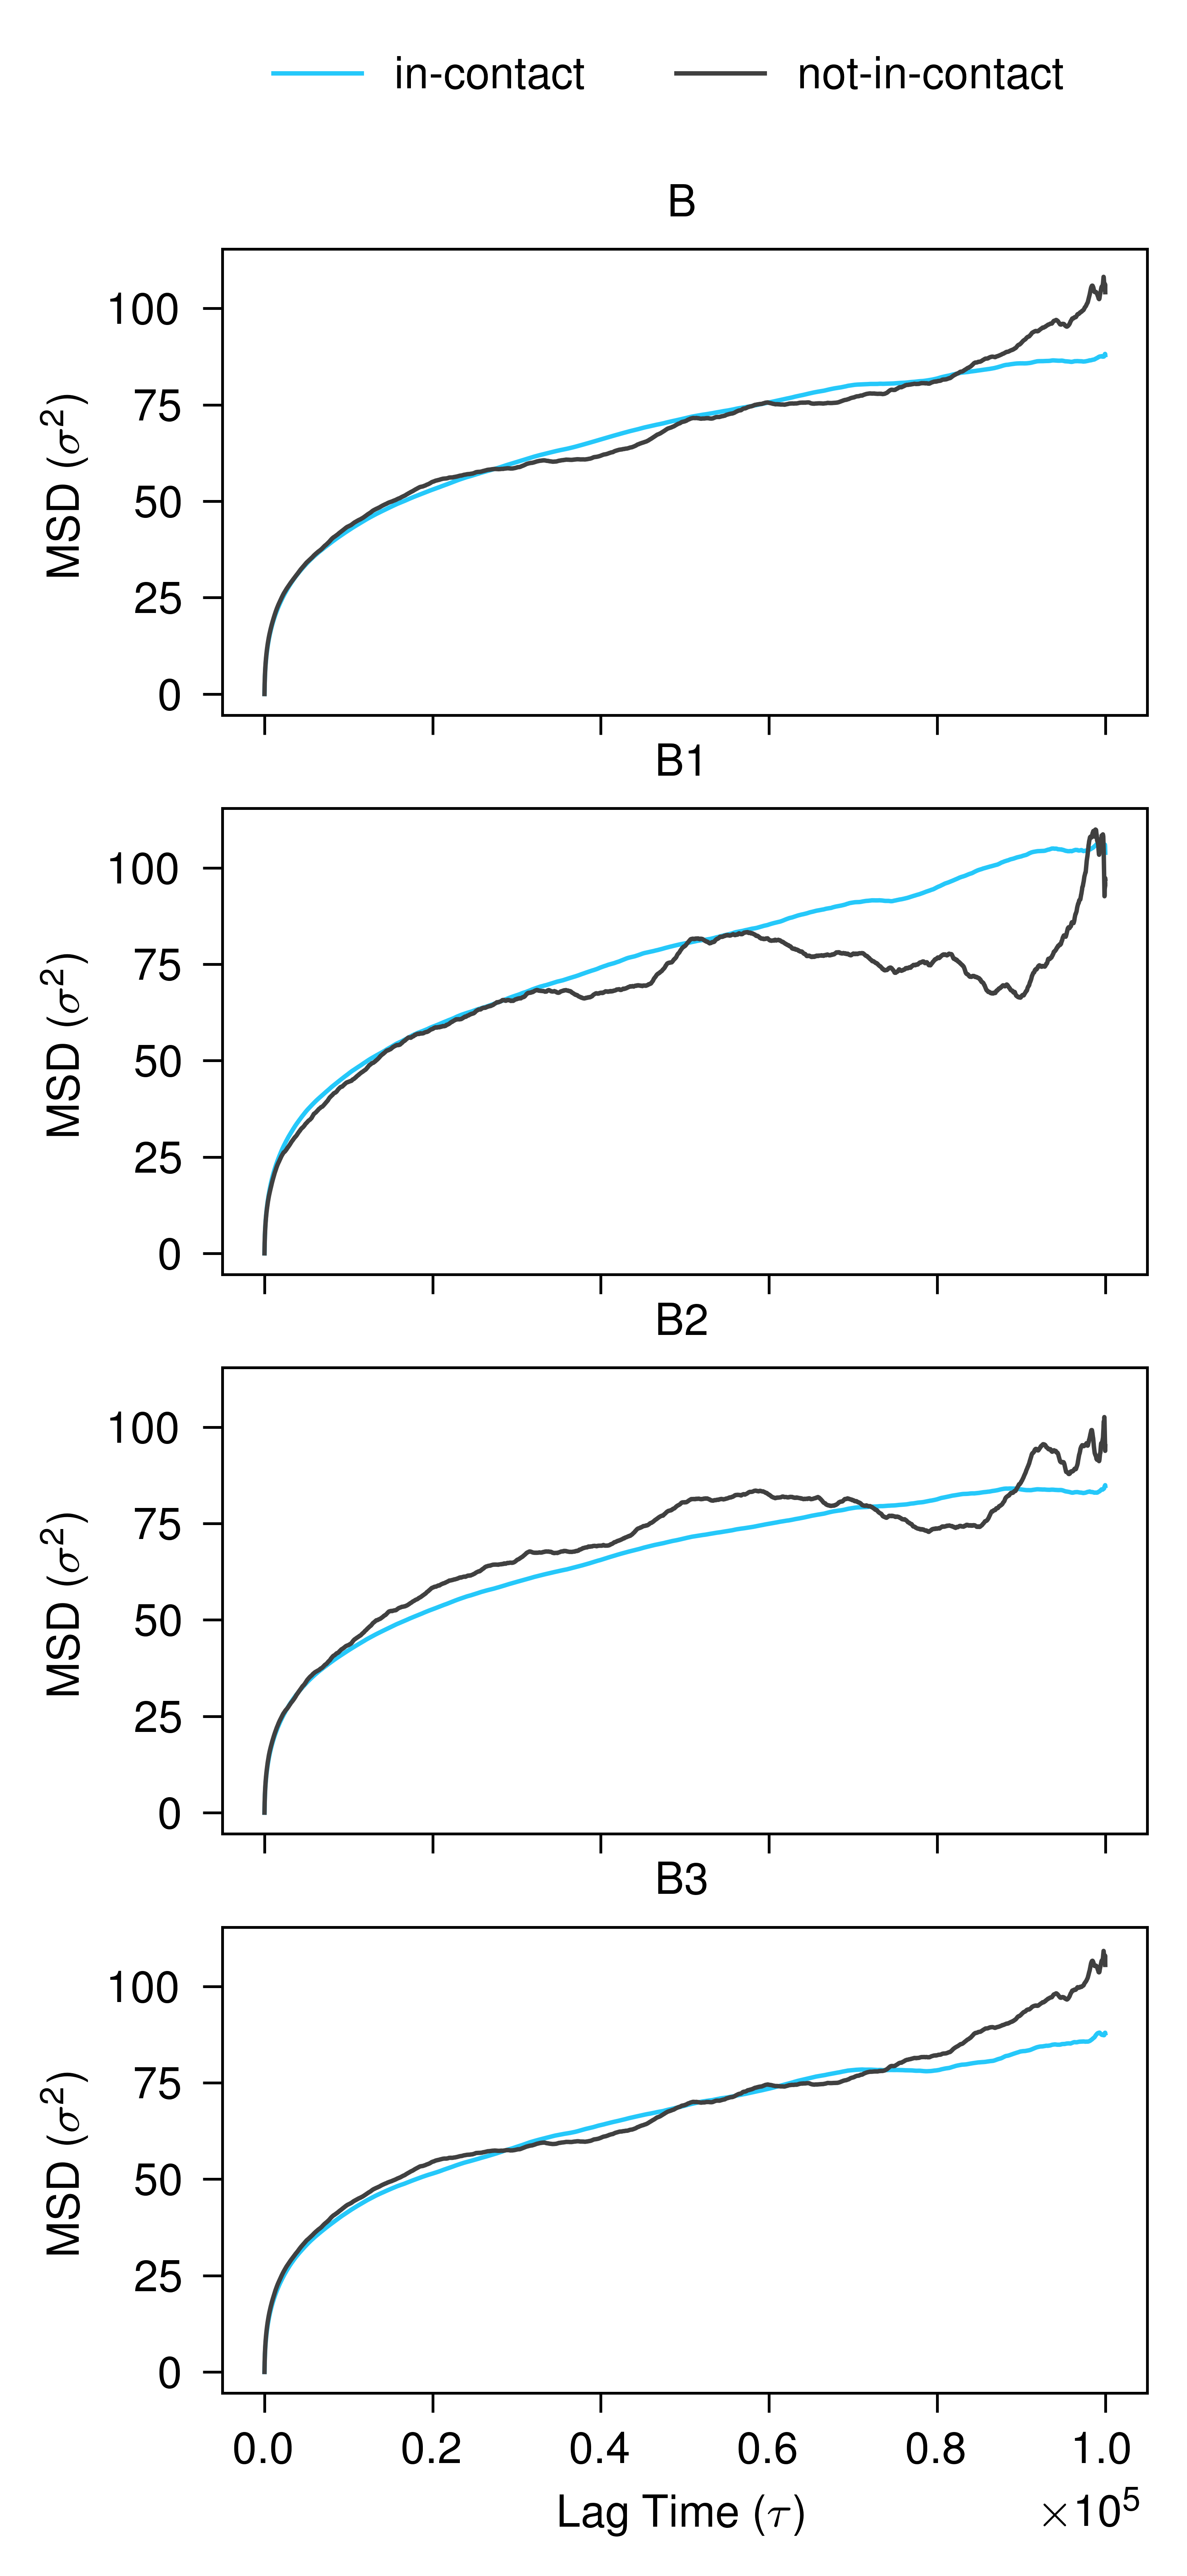

In [33]:
fig, ax = plt.subplots(4, 1, figsize=(3, 7), sharex=True, sharey=True)

lag = np.arange(msd_lamina["in-contact"]["B"].shape[0]) * 1000 * 0.01  # in tau

groups = ["in-contact", "not-in-contact"]
colors = {
    "in-contact": "#25C8FA",
    "not-in-contact": "#404040",
}

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation

for i, subcompartment in enumerate(["B", "B1", "B2", "B3"]):
    for group in groups:
        ax[i].plot(
            lag,
            msd_lamina[group][subcompartment],
            label=group,
            color=colors[group],
        )

    ax[i].set_title(f"{subcompartment}")
    ax[i].set_ylabel(r"MSD ($\sigma^2$)")
    if i == 3:
        ax[i].set_xlabel(r"Lag Time ($\tau$)")

    ax[i].xaxis.set_major_formatter(formatter)

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.92),
)

## chr17

In [43]:
chromosome = 17
folder_num = 4 if chromosome == 1 else 5

data_path = f"/scratch/mm146/Polarization/{folder_num}_IMR-90_hg38_chr{chromosome}/4_analysis/msd/data/msd-average-per-compartment.h5"

In [44]:
msd = {}
with h5py.File(
    data_path,
    "r",
) as f_in:
    for condition in f_in.keys():
        msd[condition] = {}
        for compartment in f_in[condition].keys():
            msd[condition][compartment] = f_in[condition][
                compartment
            ][()]

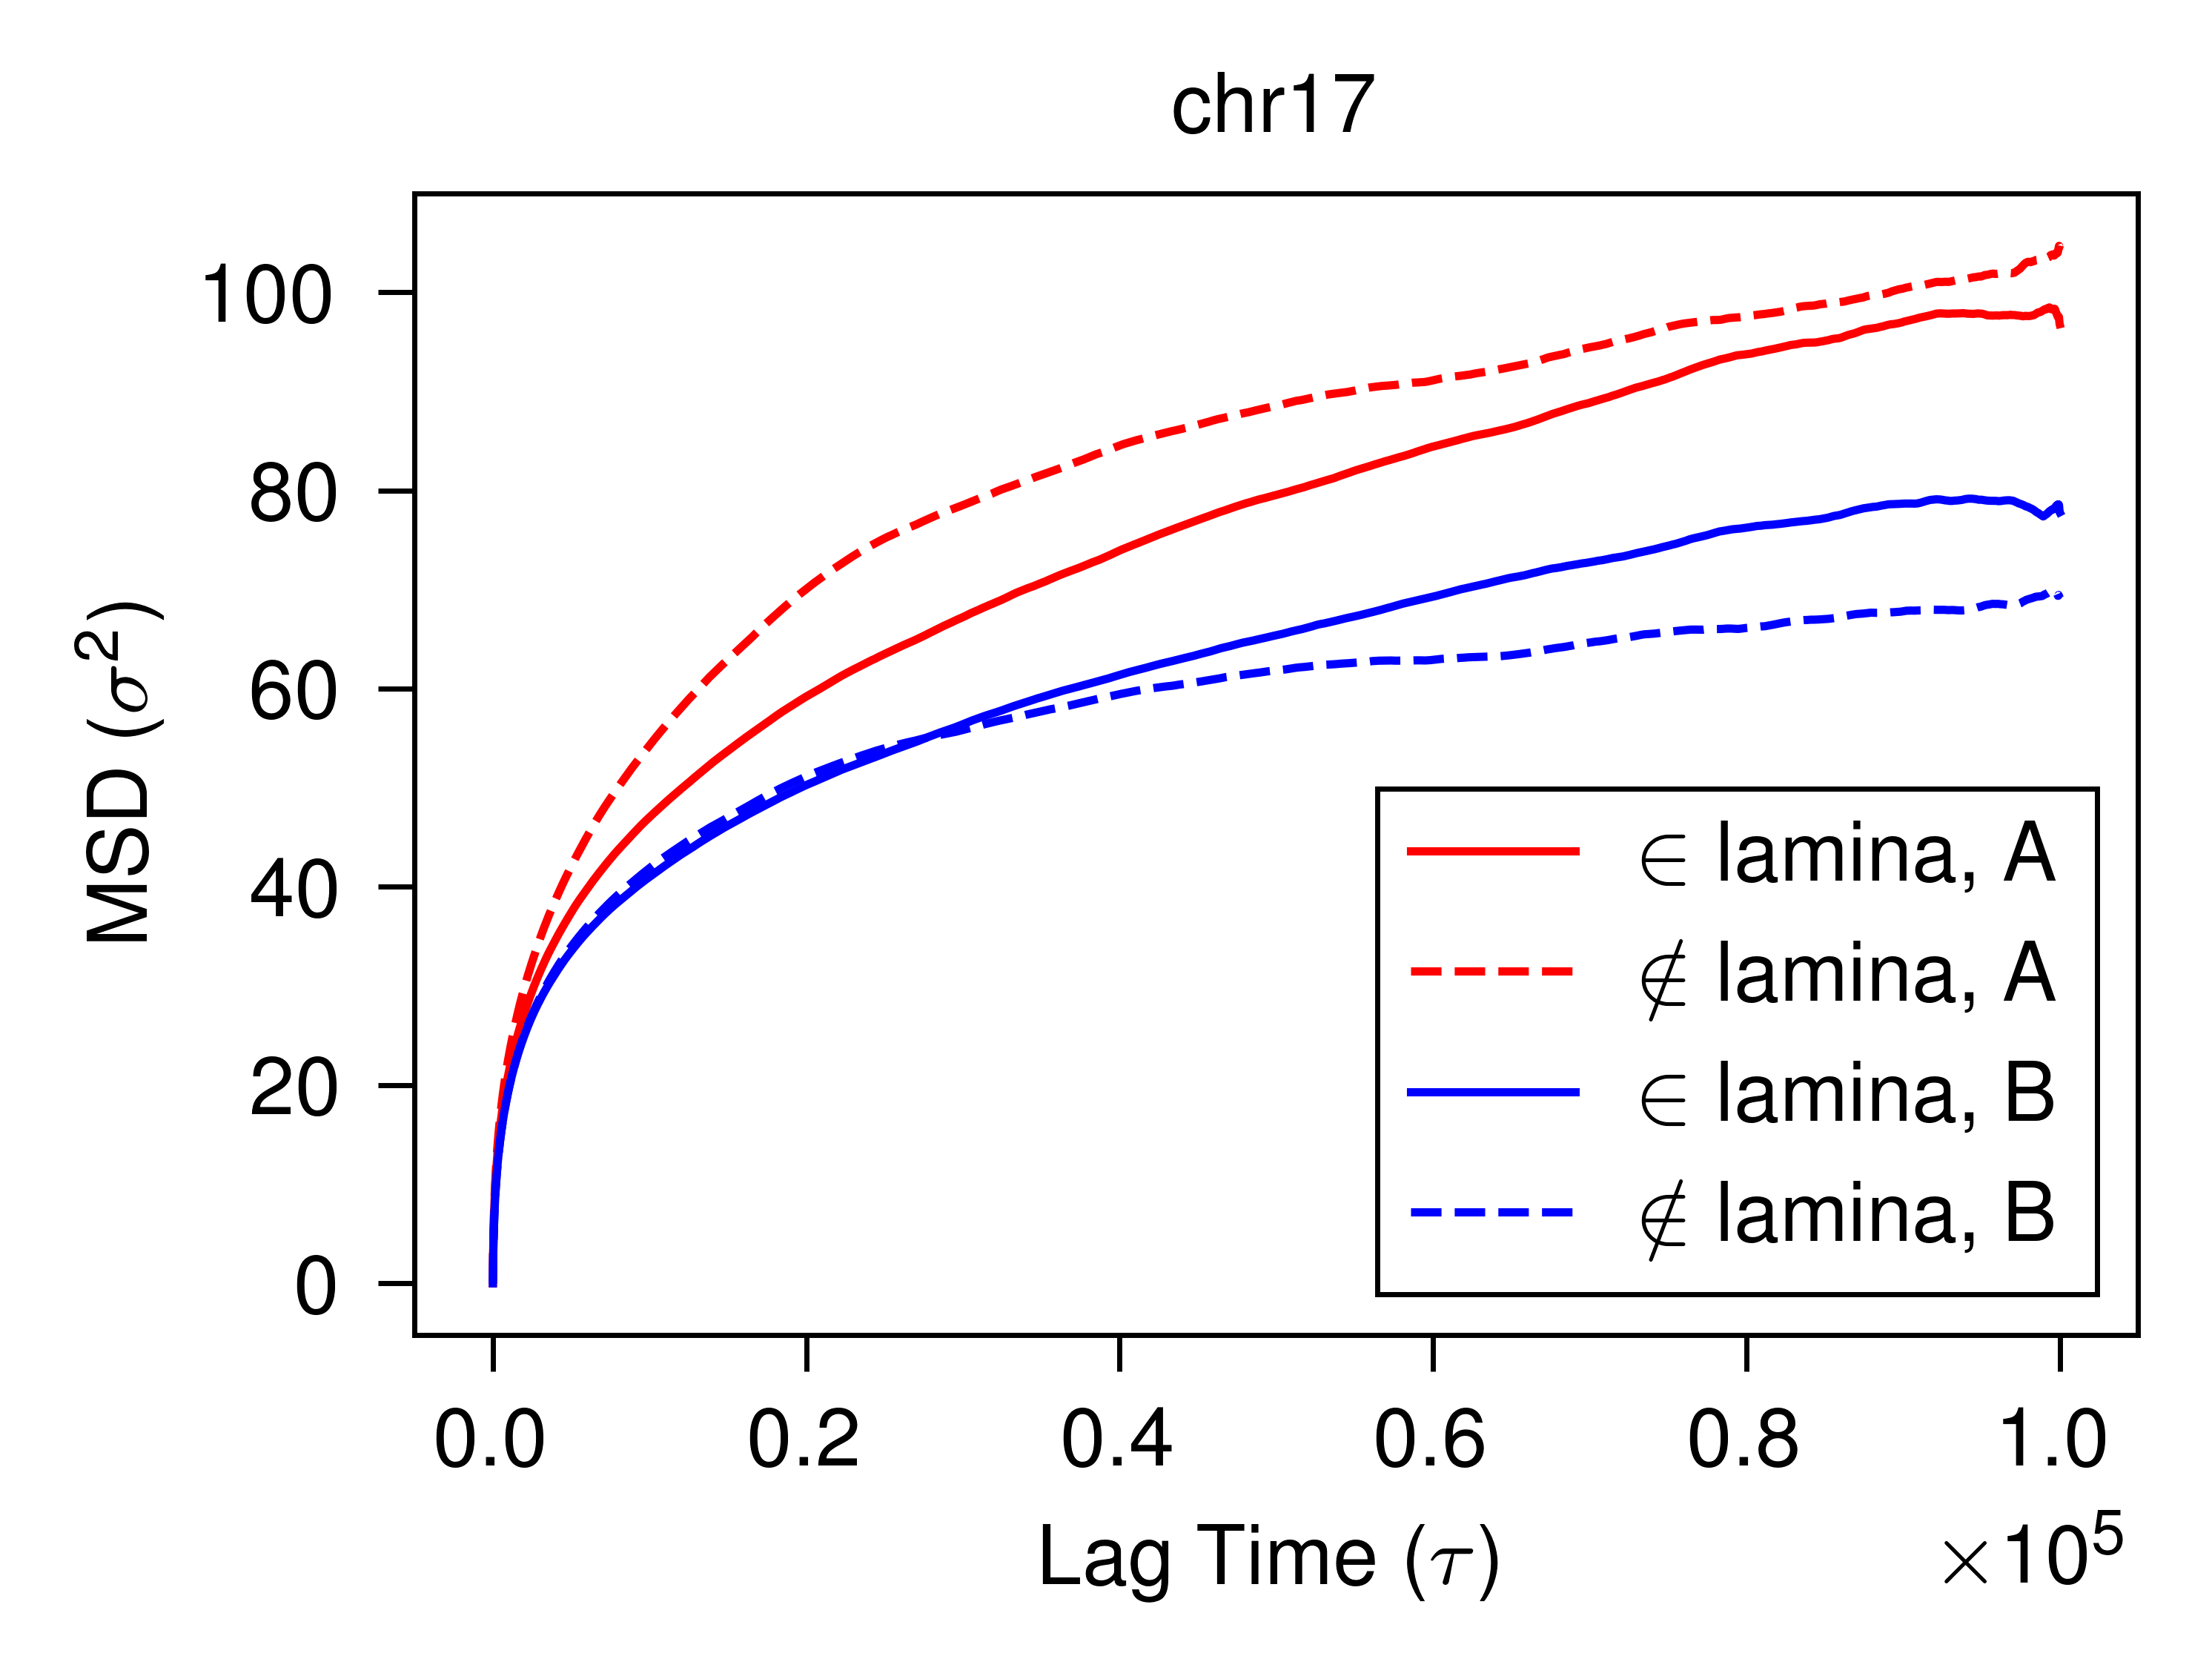

In [45]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

lag = np.arange(msd["complete"]["A"].shape[0]) * 1000 * 0.01  # in tau

ax.plot(
    lag,
    msd["complete"]["A"],
    label=r"$\in$ lamina, A",
    color="red",
)
ax.plot(
    lag,
    msd["nucleolus"]["A"],
    "--",
    label=r"$\notin$ lamina, A",
    color="red",
)
ax.plot(
    lag,
    msd["complete"]["B"],
    label=r"$\in$ lamina, B",
    color="blue",
)
ax.plot(
    lag,
    msd["nucleolus"]["B"],
    "--",
    label=r"$\notin$ lamina, B",
    color="blue",
)

ax.set_ylabel(r"MSD ($\sigma^2$)")
ax.set_xlabel(r"Lag Time ($\tau$)")

ax.legend()

ax.set_title(f"chr{chromosome}", fontsize=8)

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation
ax.xaxis.set_major_formatter(formatter)

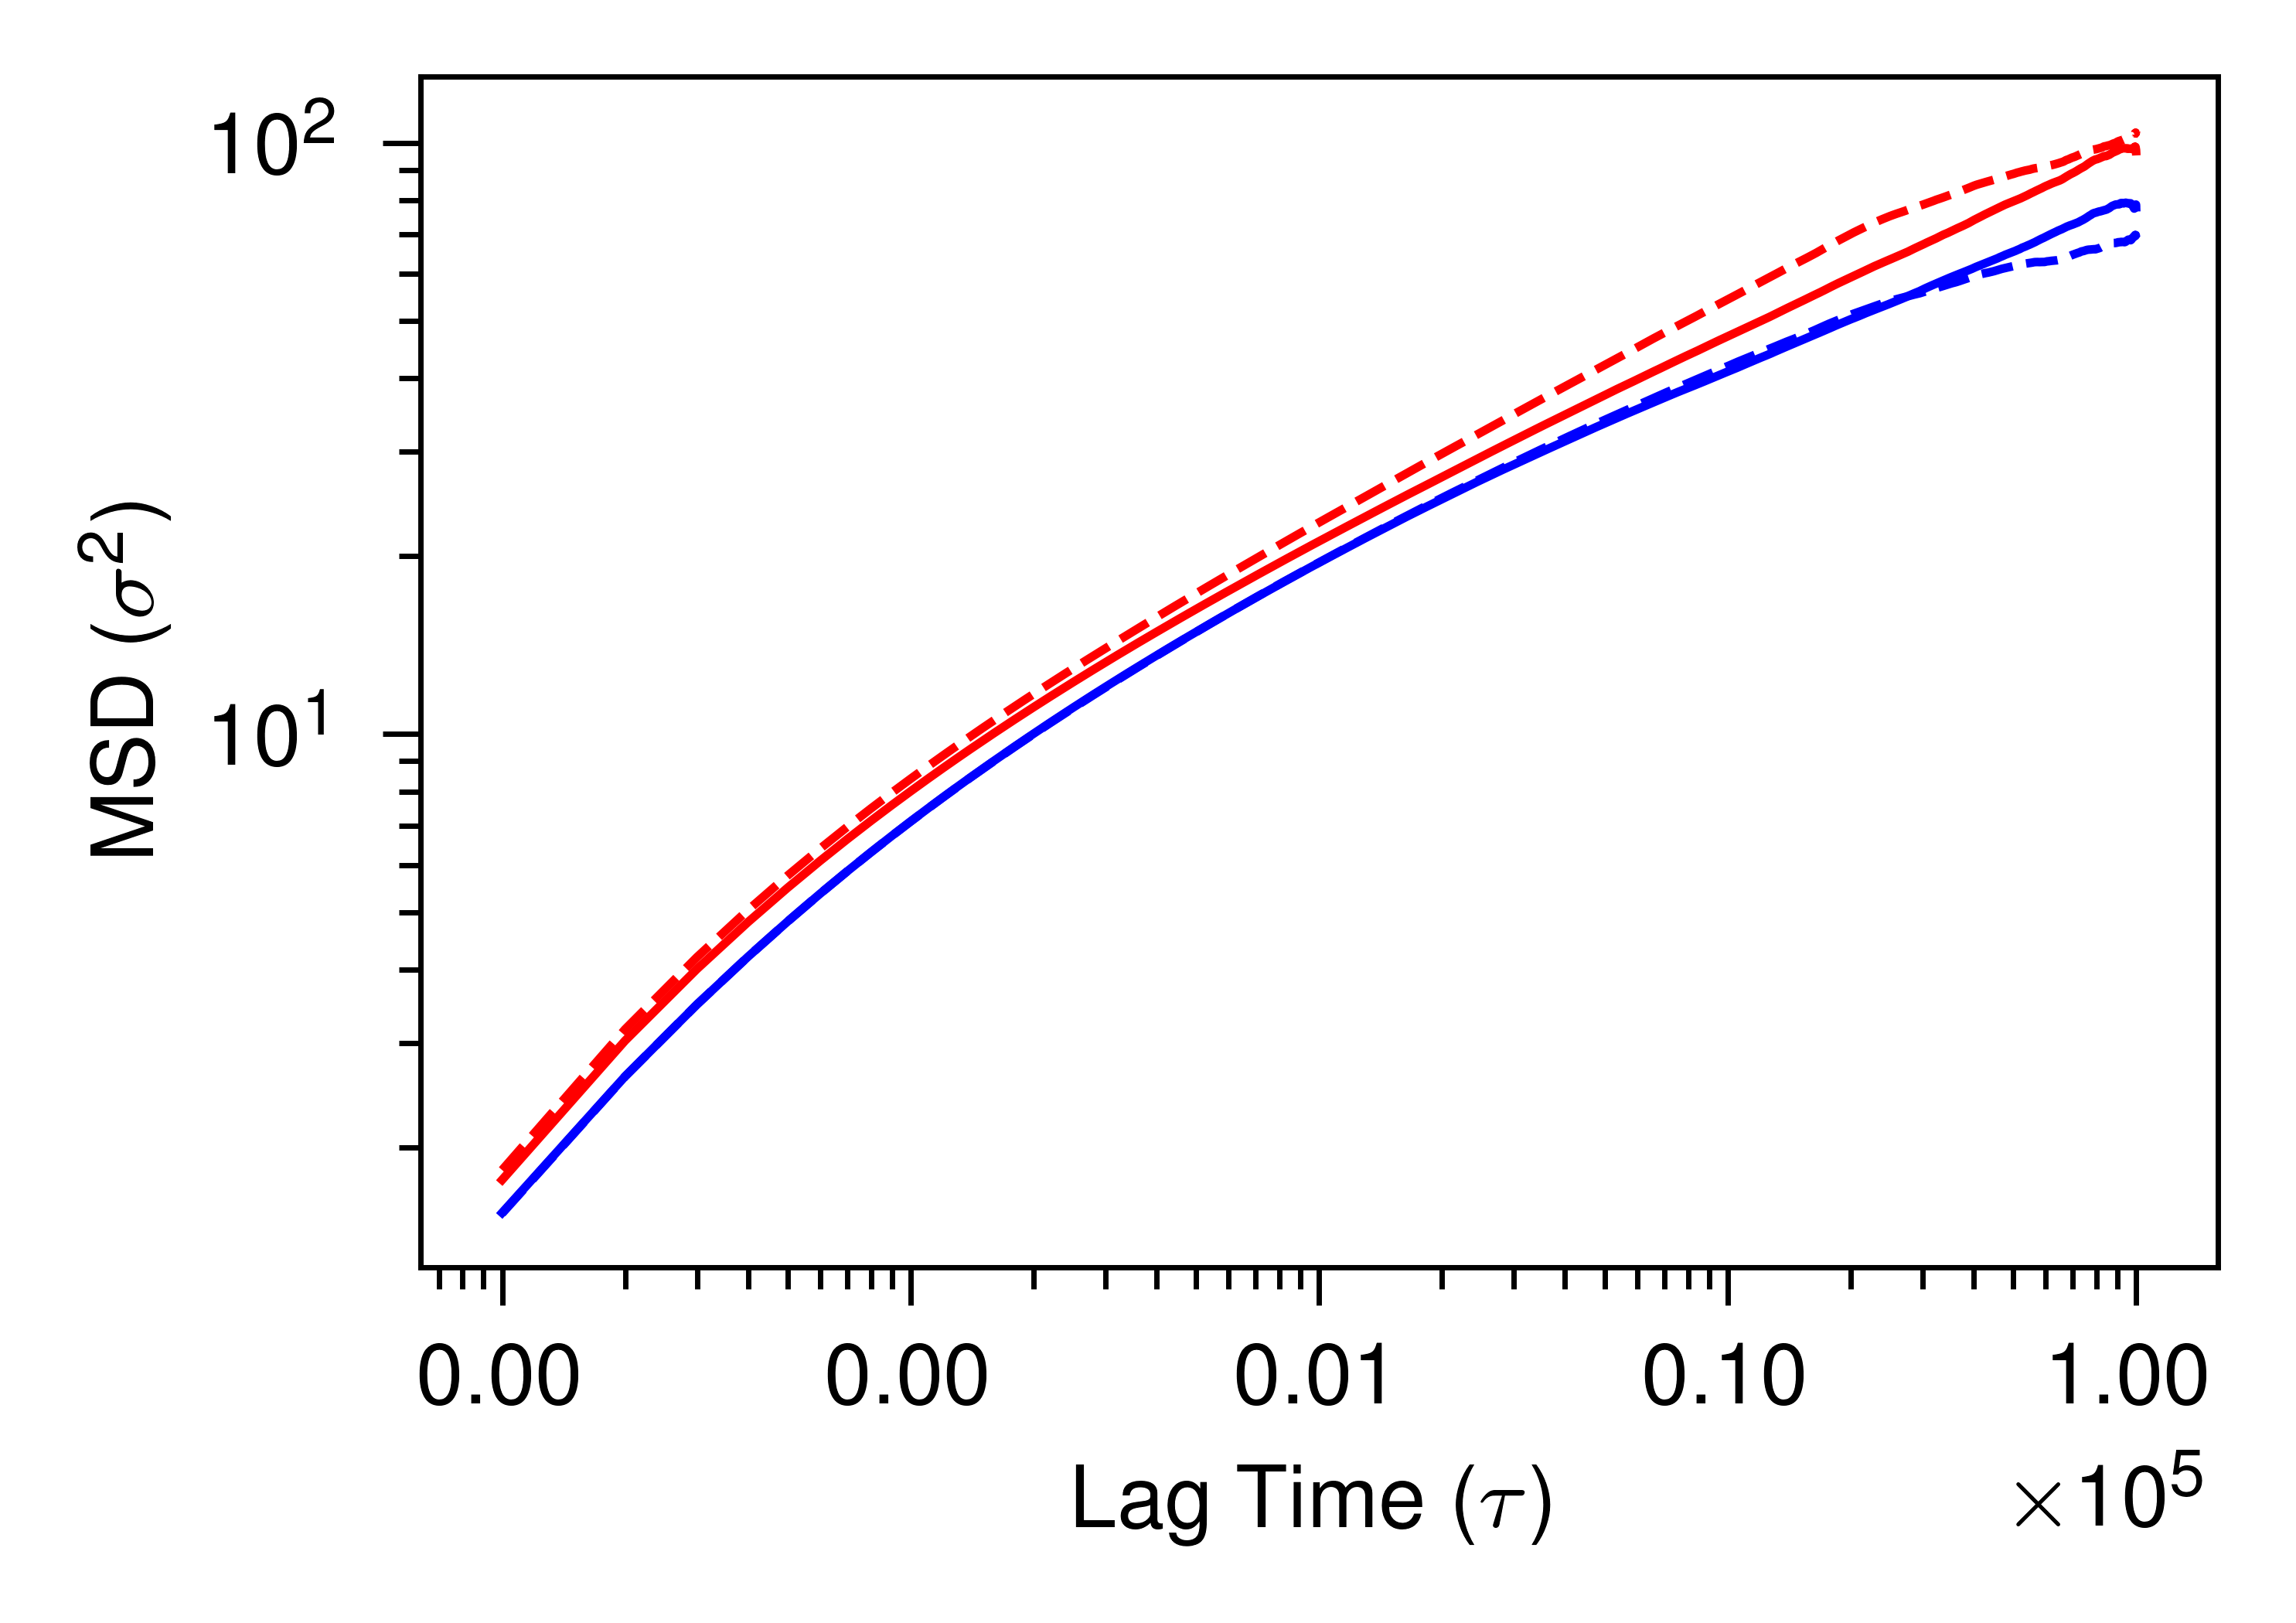

In [46]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

lag = np.arange(msd["complete"]["A"].shape[0]) * 1000 * 0.01  # in tau

ax.loglog(
    lag[1:],
    msd["complete"]["A"][1:],
    label="A",
    color="red",
)
ax.loglog(
    lag[1:],
    msd["nucleolus"]["A"][1:],
    "--",
    label="A",
    color="red",
)
ax.loglog(
    lag[1:],
    msd["complete"]["B"][1:],
    label="B",
    color="blue",
)
ax.loglog(
    lag[1:],
    msd["nucleolus"]["B"][1:],
    "--",
    label="B",
    color="blue",
)

ax.set_ylabel(r"MSD ($\sigma^2$)")
ax.set_xlabel(r"Lag Time ($\tau$)")

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation

# Apply formatter
ax.xaxis.set_major_formatter(formatter)

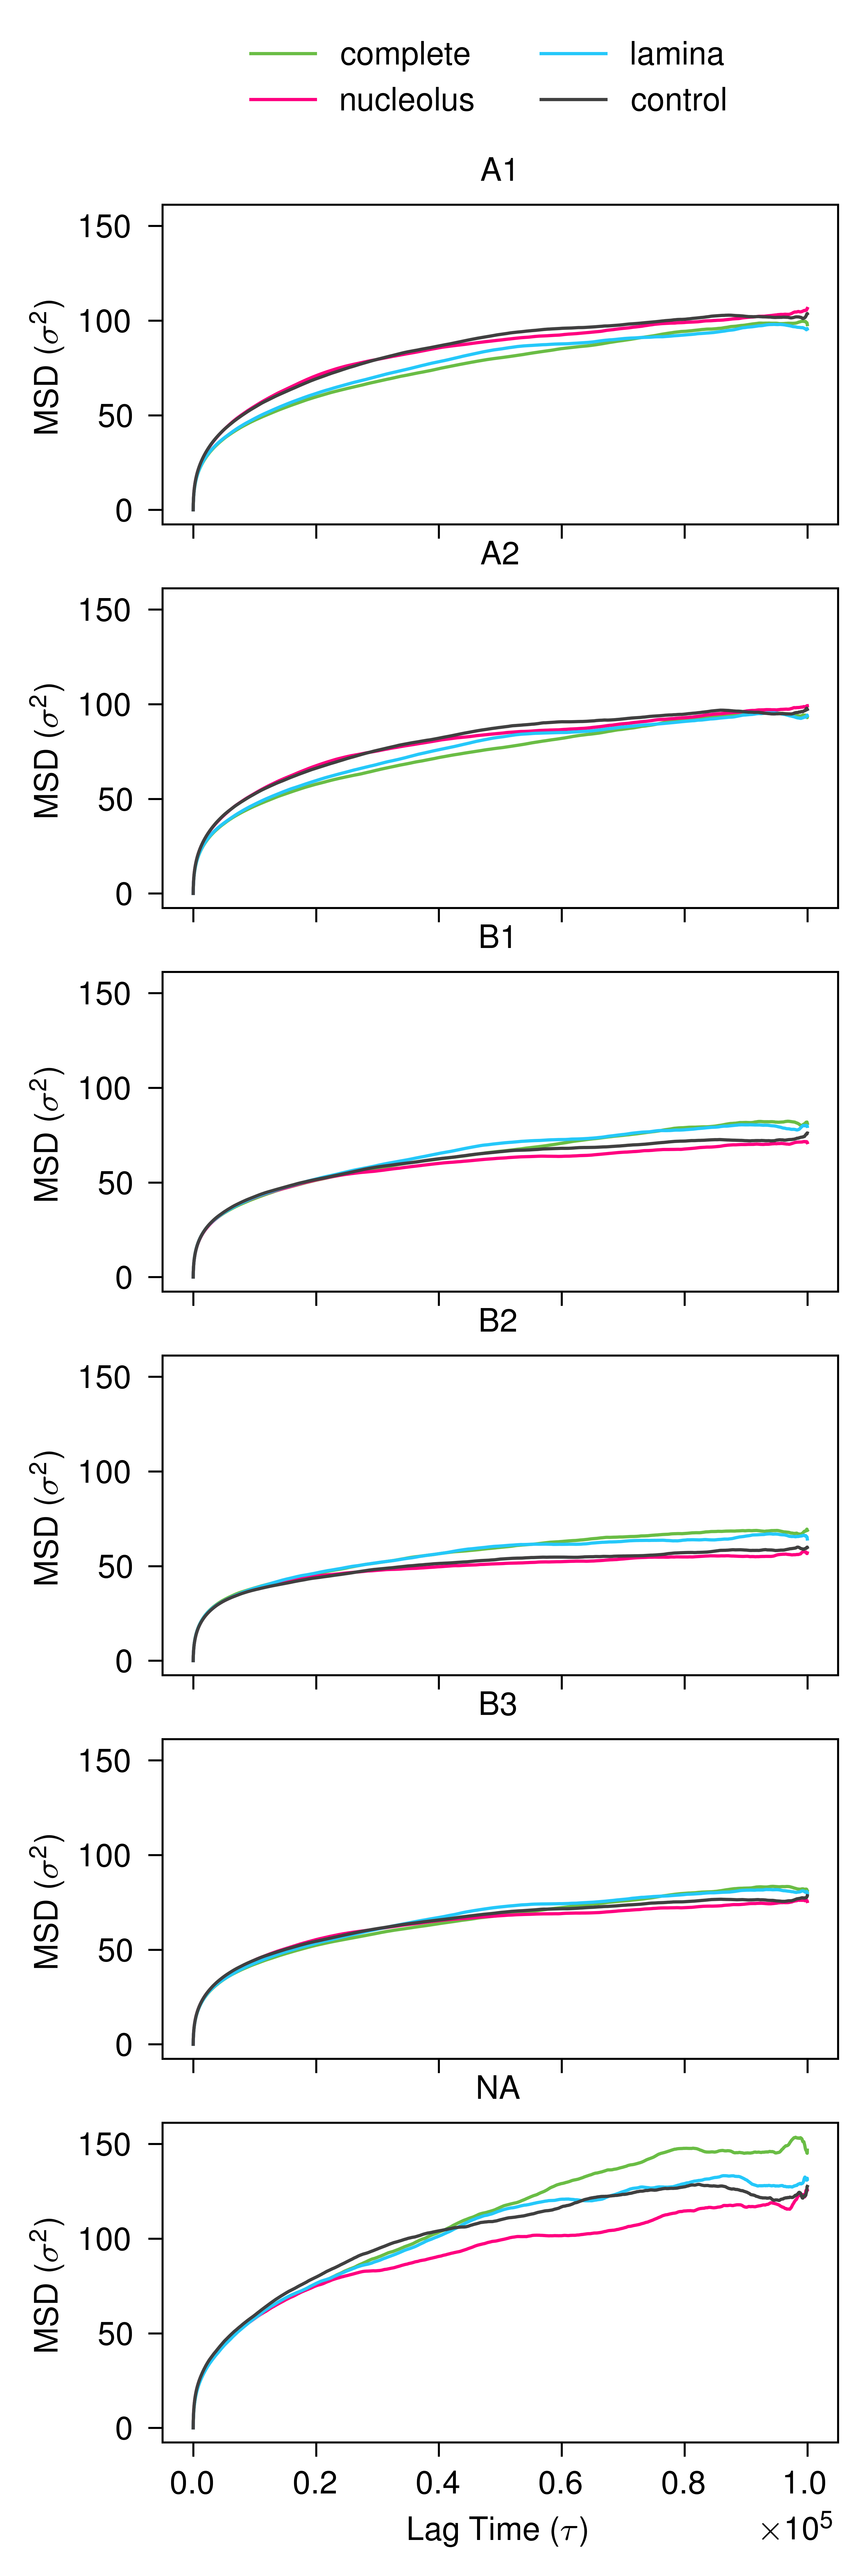

In [47]:
fig, ax = plt.subplots(
    6, 1, figsize=(3, 10), sharex=True, sharey=True
)

lag = np.arange(msd["complete"]["A"].shape[0]) * 1000 * 0.01  # in tau

conditions = ["complete", "nucleolus", "lamina", "control"]

colors = {
    "complete": "#6abd45",
    "nucleolus": "#ff0080",
    "control": "#404040",
    "lamina": "#25C8FA",
    # "isolation": "#FFC083",
}

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation

for i, subcompartment in enumerate(
    ["A1", "A2", "B1", "B2", "B3", "NA"]
):
    for condition in conditions:
        ax[i].plot(
            lag,
            msd[condition][subcompartment],
            label=condition,
            color=colors[condition],
        )

    ax[i].set_title(f"{subcompartment}")
    ax[i].set_ylabel(r"MSD ($\sigma^2$)")
    if i == 5:
        ax[i].set_xlabel(r"Lag Time ($\tau$)")

    ax[i].xaxis.set_major_formatter(formatter)

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.9),
)

# nuclear bodies as beads

## chr1


In [2]:
chromosome = 1
folder_num = 4 if chromosome == 1 else 5

data_path = f"/scratch/mm146/Polarization/{folder_num}_IMR-90_hg38_chr{chromosome}/7_analysis/msd/data/msd-average-per-compartment.h5"

conditions = ["complete", "nucleolus"]

In [3]:
msd = {}
with h5py.File(
    data_path,
    "r",
) as f_in:
    for condition in f_in.keys():
        msd[condition] = {}
        for compartment in f_in[condition].keys():
            msd[condition][compartment] = f_in[condition][
                compartment
            ][()]

In [4]:
msd_std = {}
with h5py.File(
    f"/scratch/mm146/Polarization/{folder_num}_IMR-90_hg38_chr{chromosome}/7_analysis/msd/data/msd-std-per-compartment.h5",
    "r",
) as f_in:
    for condition in f_in.keys():
        msd_std[condition] = {}
        for compartment in f_in[condition].keys():
            msd_std[condition][compartment] = f_in[condition][
                compartment
            ][()]

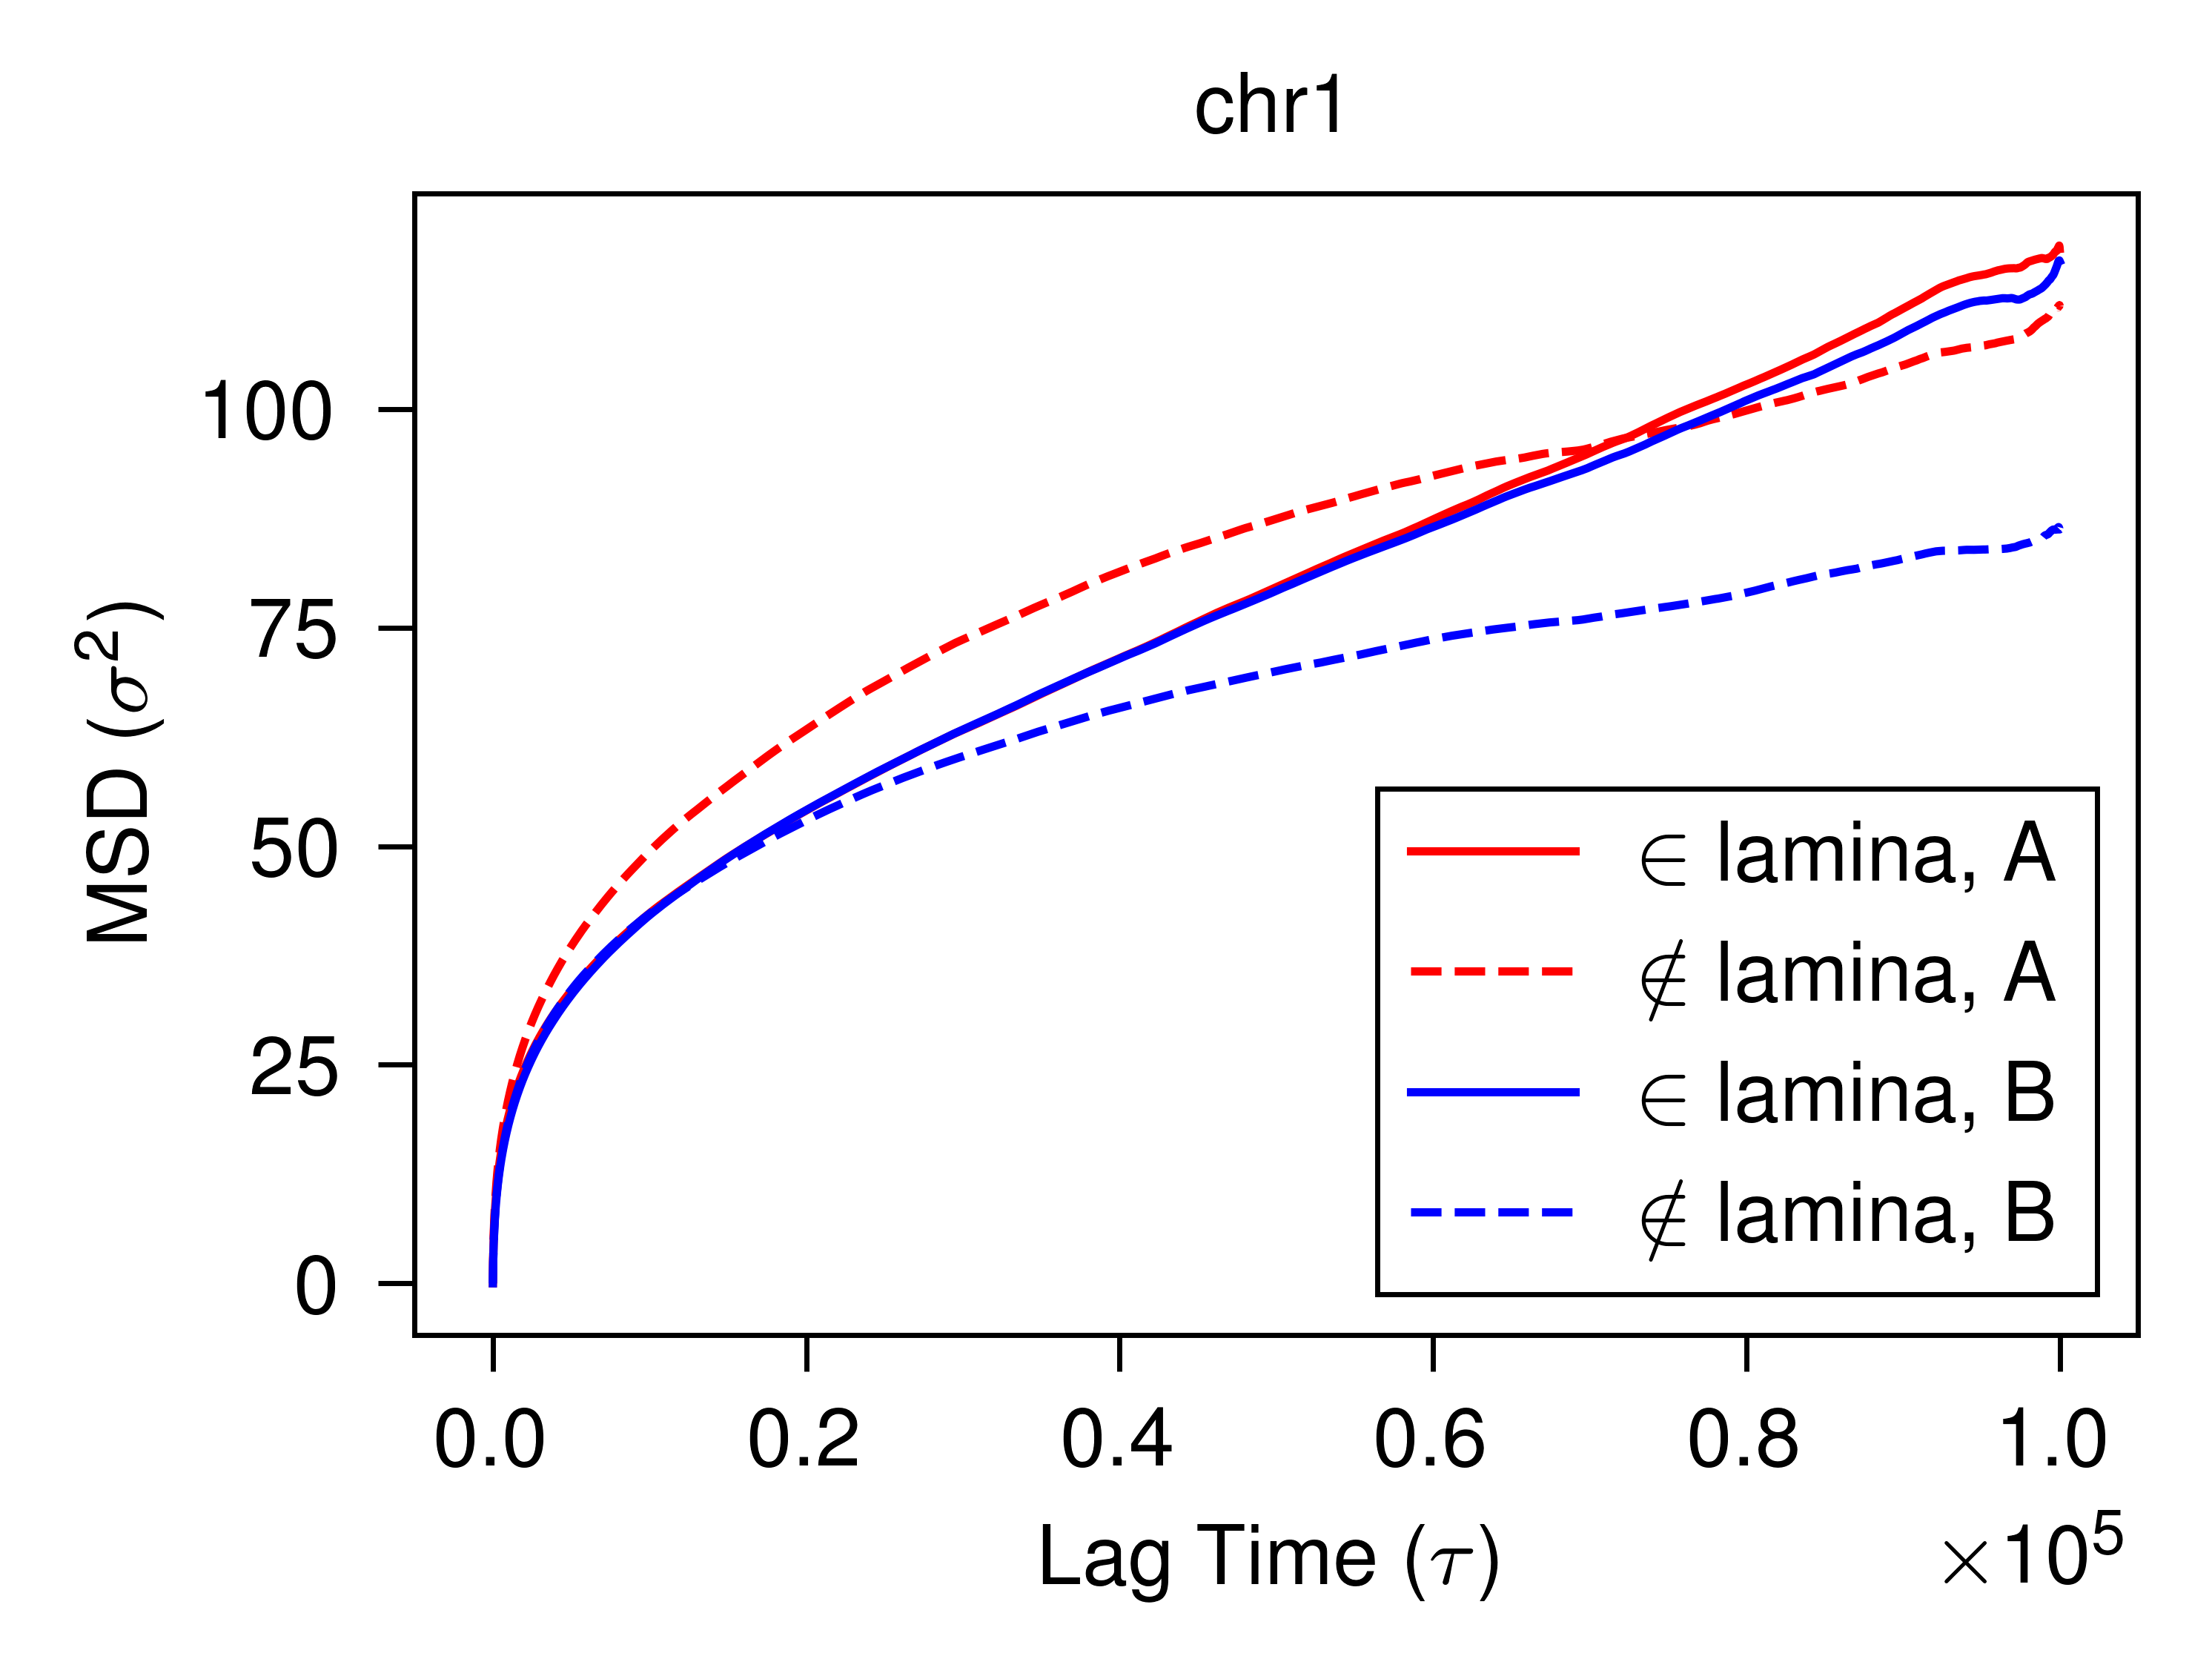

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

lag = np.arange(msd["complete"]["A"].shape[0]) * 1000 * 0.01  # in tau

ax.plot(
    lag,
    msd["complete"]["A"],
    label=r"$\in$ lamina, A",
    color="red",
)
ax.plot(
    lag,
    msd["nucleolus"]["A"],
    "--",
    label=r"$\notin$ lamina, A",
    color="red",
)
ax.plot(
    lag,
    msd["complete"]["B"],
    label=r"$\in$ lamina, B",
    color="blue",
)
ax.plot(
    lag,
    msd["nucleolus"]["B"],
    "--",
    label=r"$\notin$ lamina, B",
    color="blue",
)

ax.set_ylabel(r"MSD ($\sigma^2$)")
ax.set_xlabel(r"Lag Time ($\tau$)")

ax.legend()

ax.set_title(f"chr{chromosome}", fontsize=8)

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation
ax.xaxis.set_major_formatter(formatter)

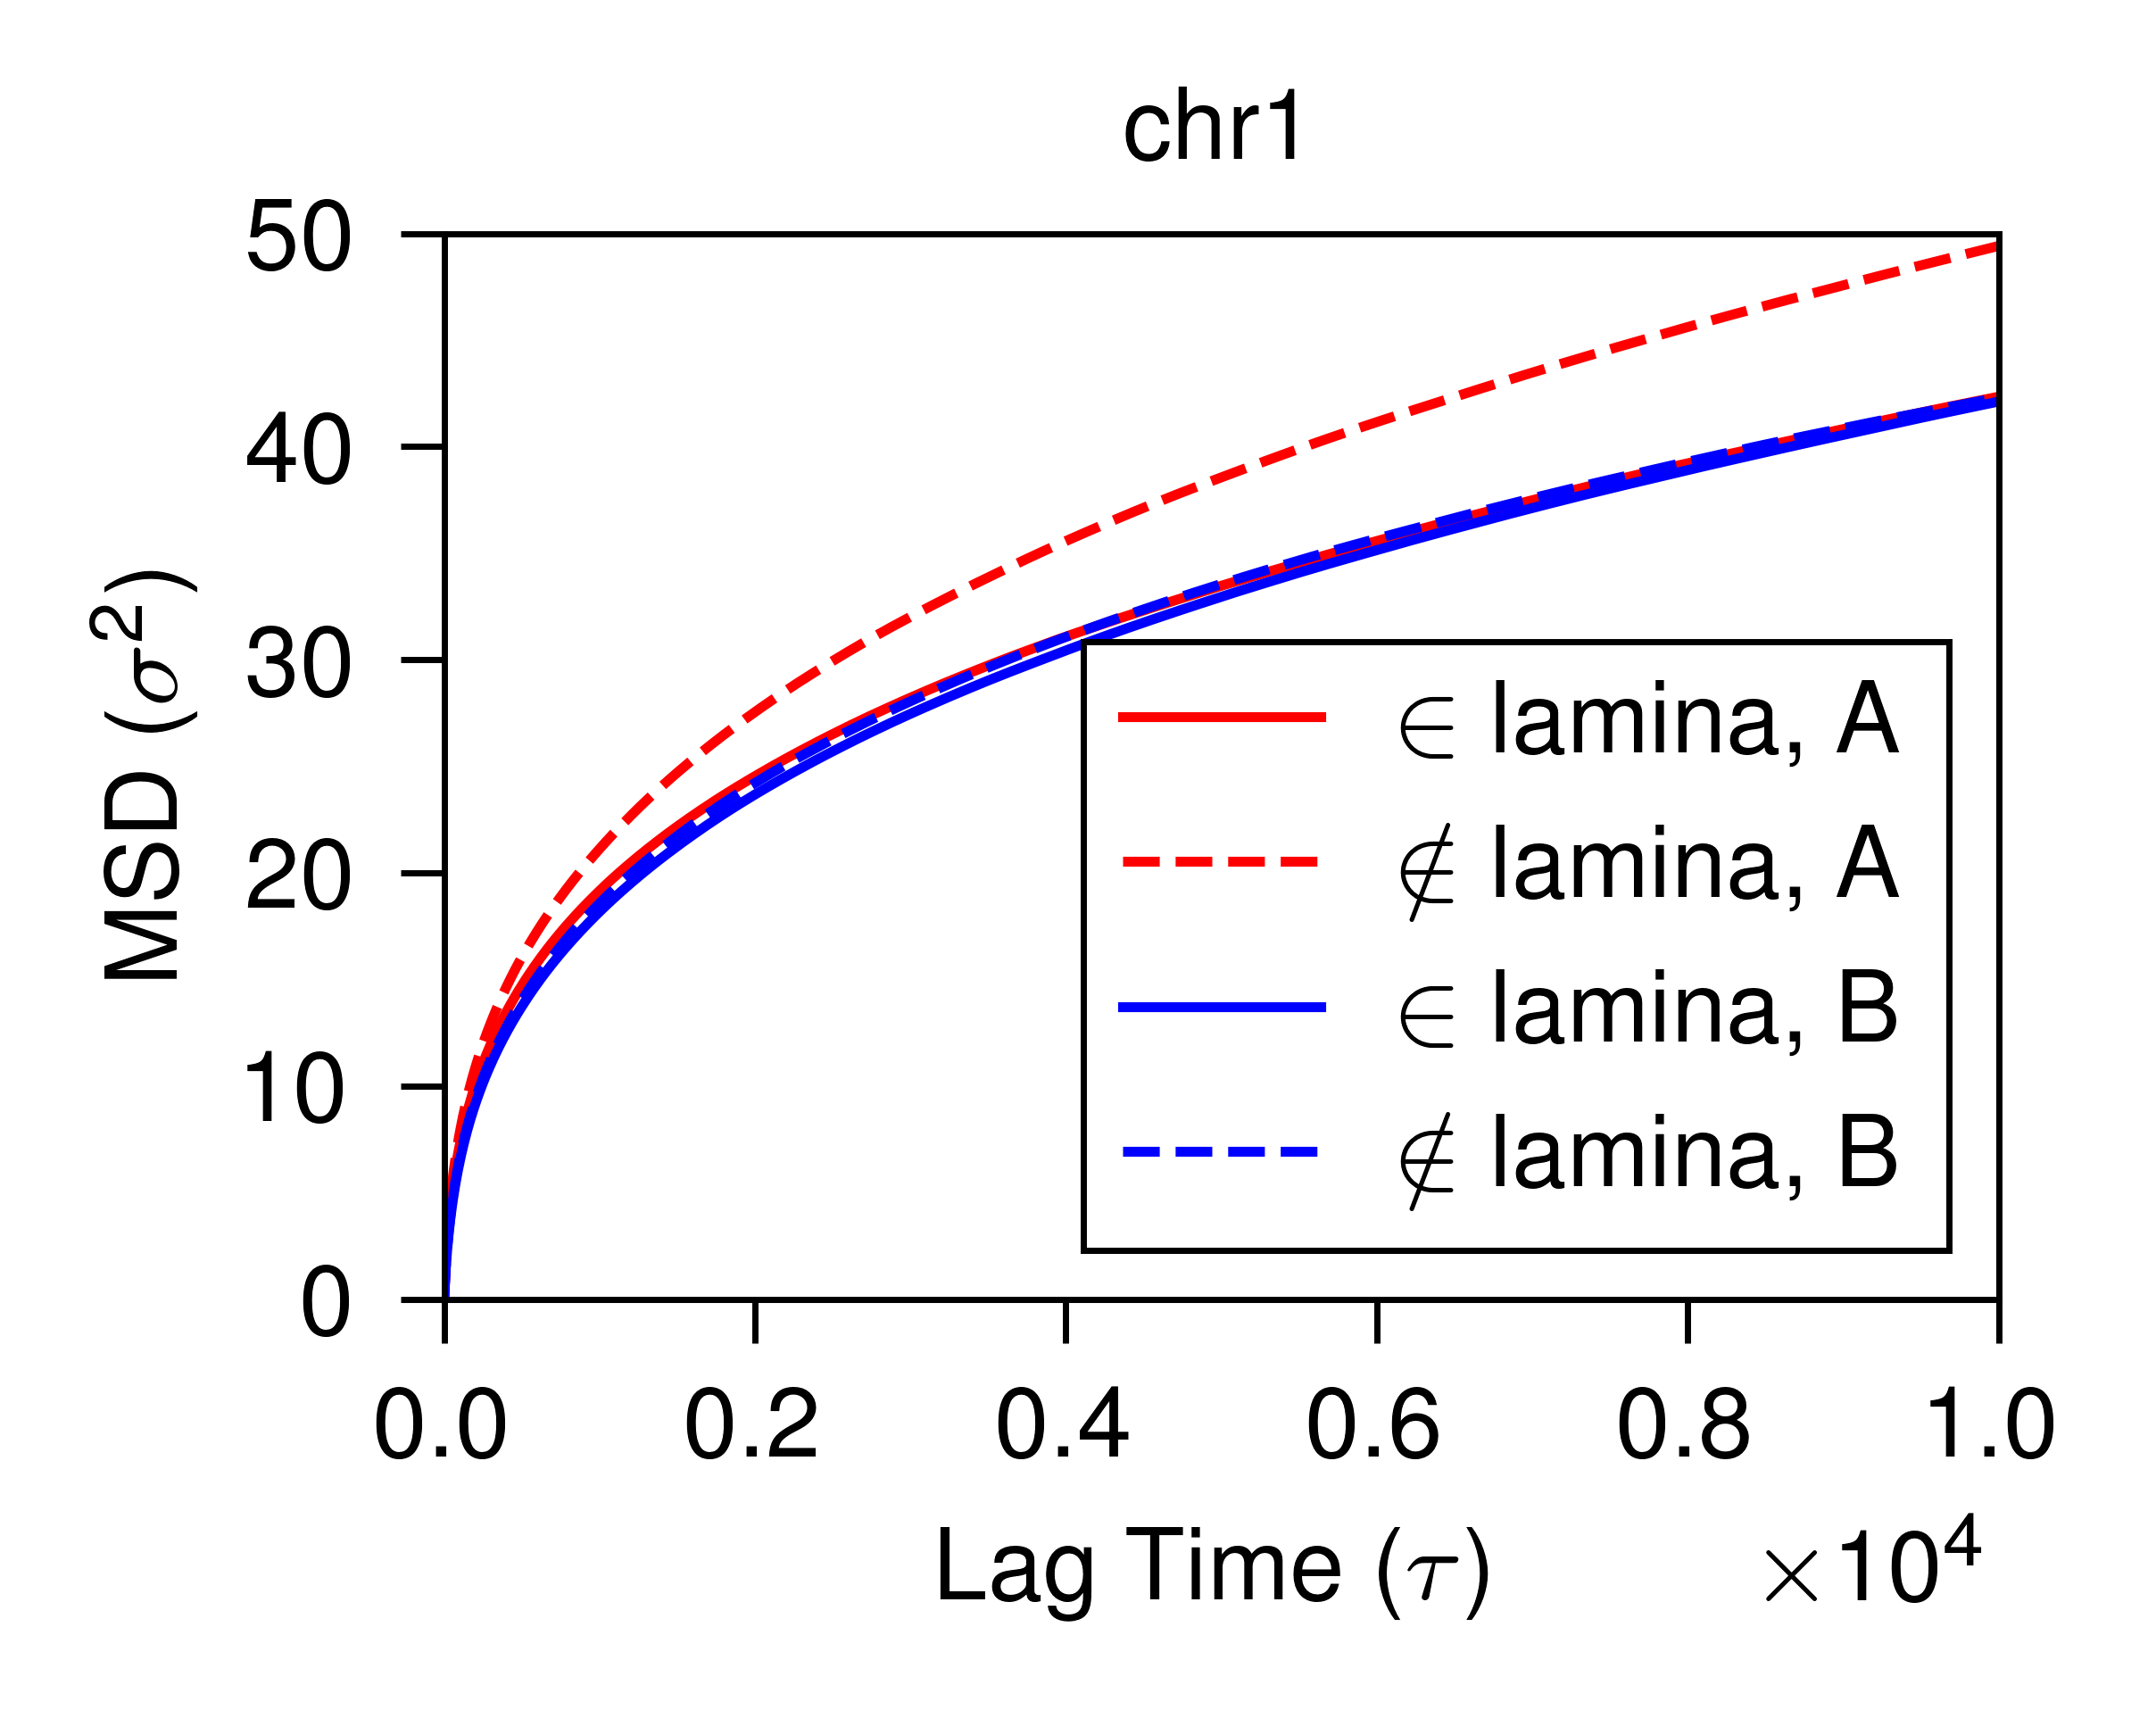

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(2.3, 1.8), layout="constrained")

lag = np.arange(msd["complete"]["A"].shape[0]) * 1000 * 0.01  # in tau

ax.plot(
    lag,
    msd["complete"]["A"],
    label=r"$\in$ lamina, A",
    color="red",
)
ax.plot(
    lag,
    msd["nucleolus"]["A"],
    "--",
    label=r"$\notin$ lamina, A",
    color="red",
)
ax.plot(
    lag,
    msd["complete"]["B"],
    label=r"$\in$ lamina, B",
    color="blue",
)
ax.plot(
    lag,
    msd["nucleolus"]["B"],
    "--",
    label=r"$\notin$ lamina, B",
    color="blue",
)

ax.set_ylabel(r"MSD ($\sigma^2$)")
ax.set_xlabel(r"Lag Time ($\tau$)")

ax.legend()

ax.set_xlim(left=lag[0], right=lag[1000])
ax.set_ylim(0, 50)

ax.set_title(f"chr{chromosome}", fontsize=8)

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation
ax.xaxis.set_major_formatter(formatter)

fig.savefig("figures/fig-msd-lamina-effect-chr1.pdf")

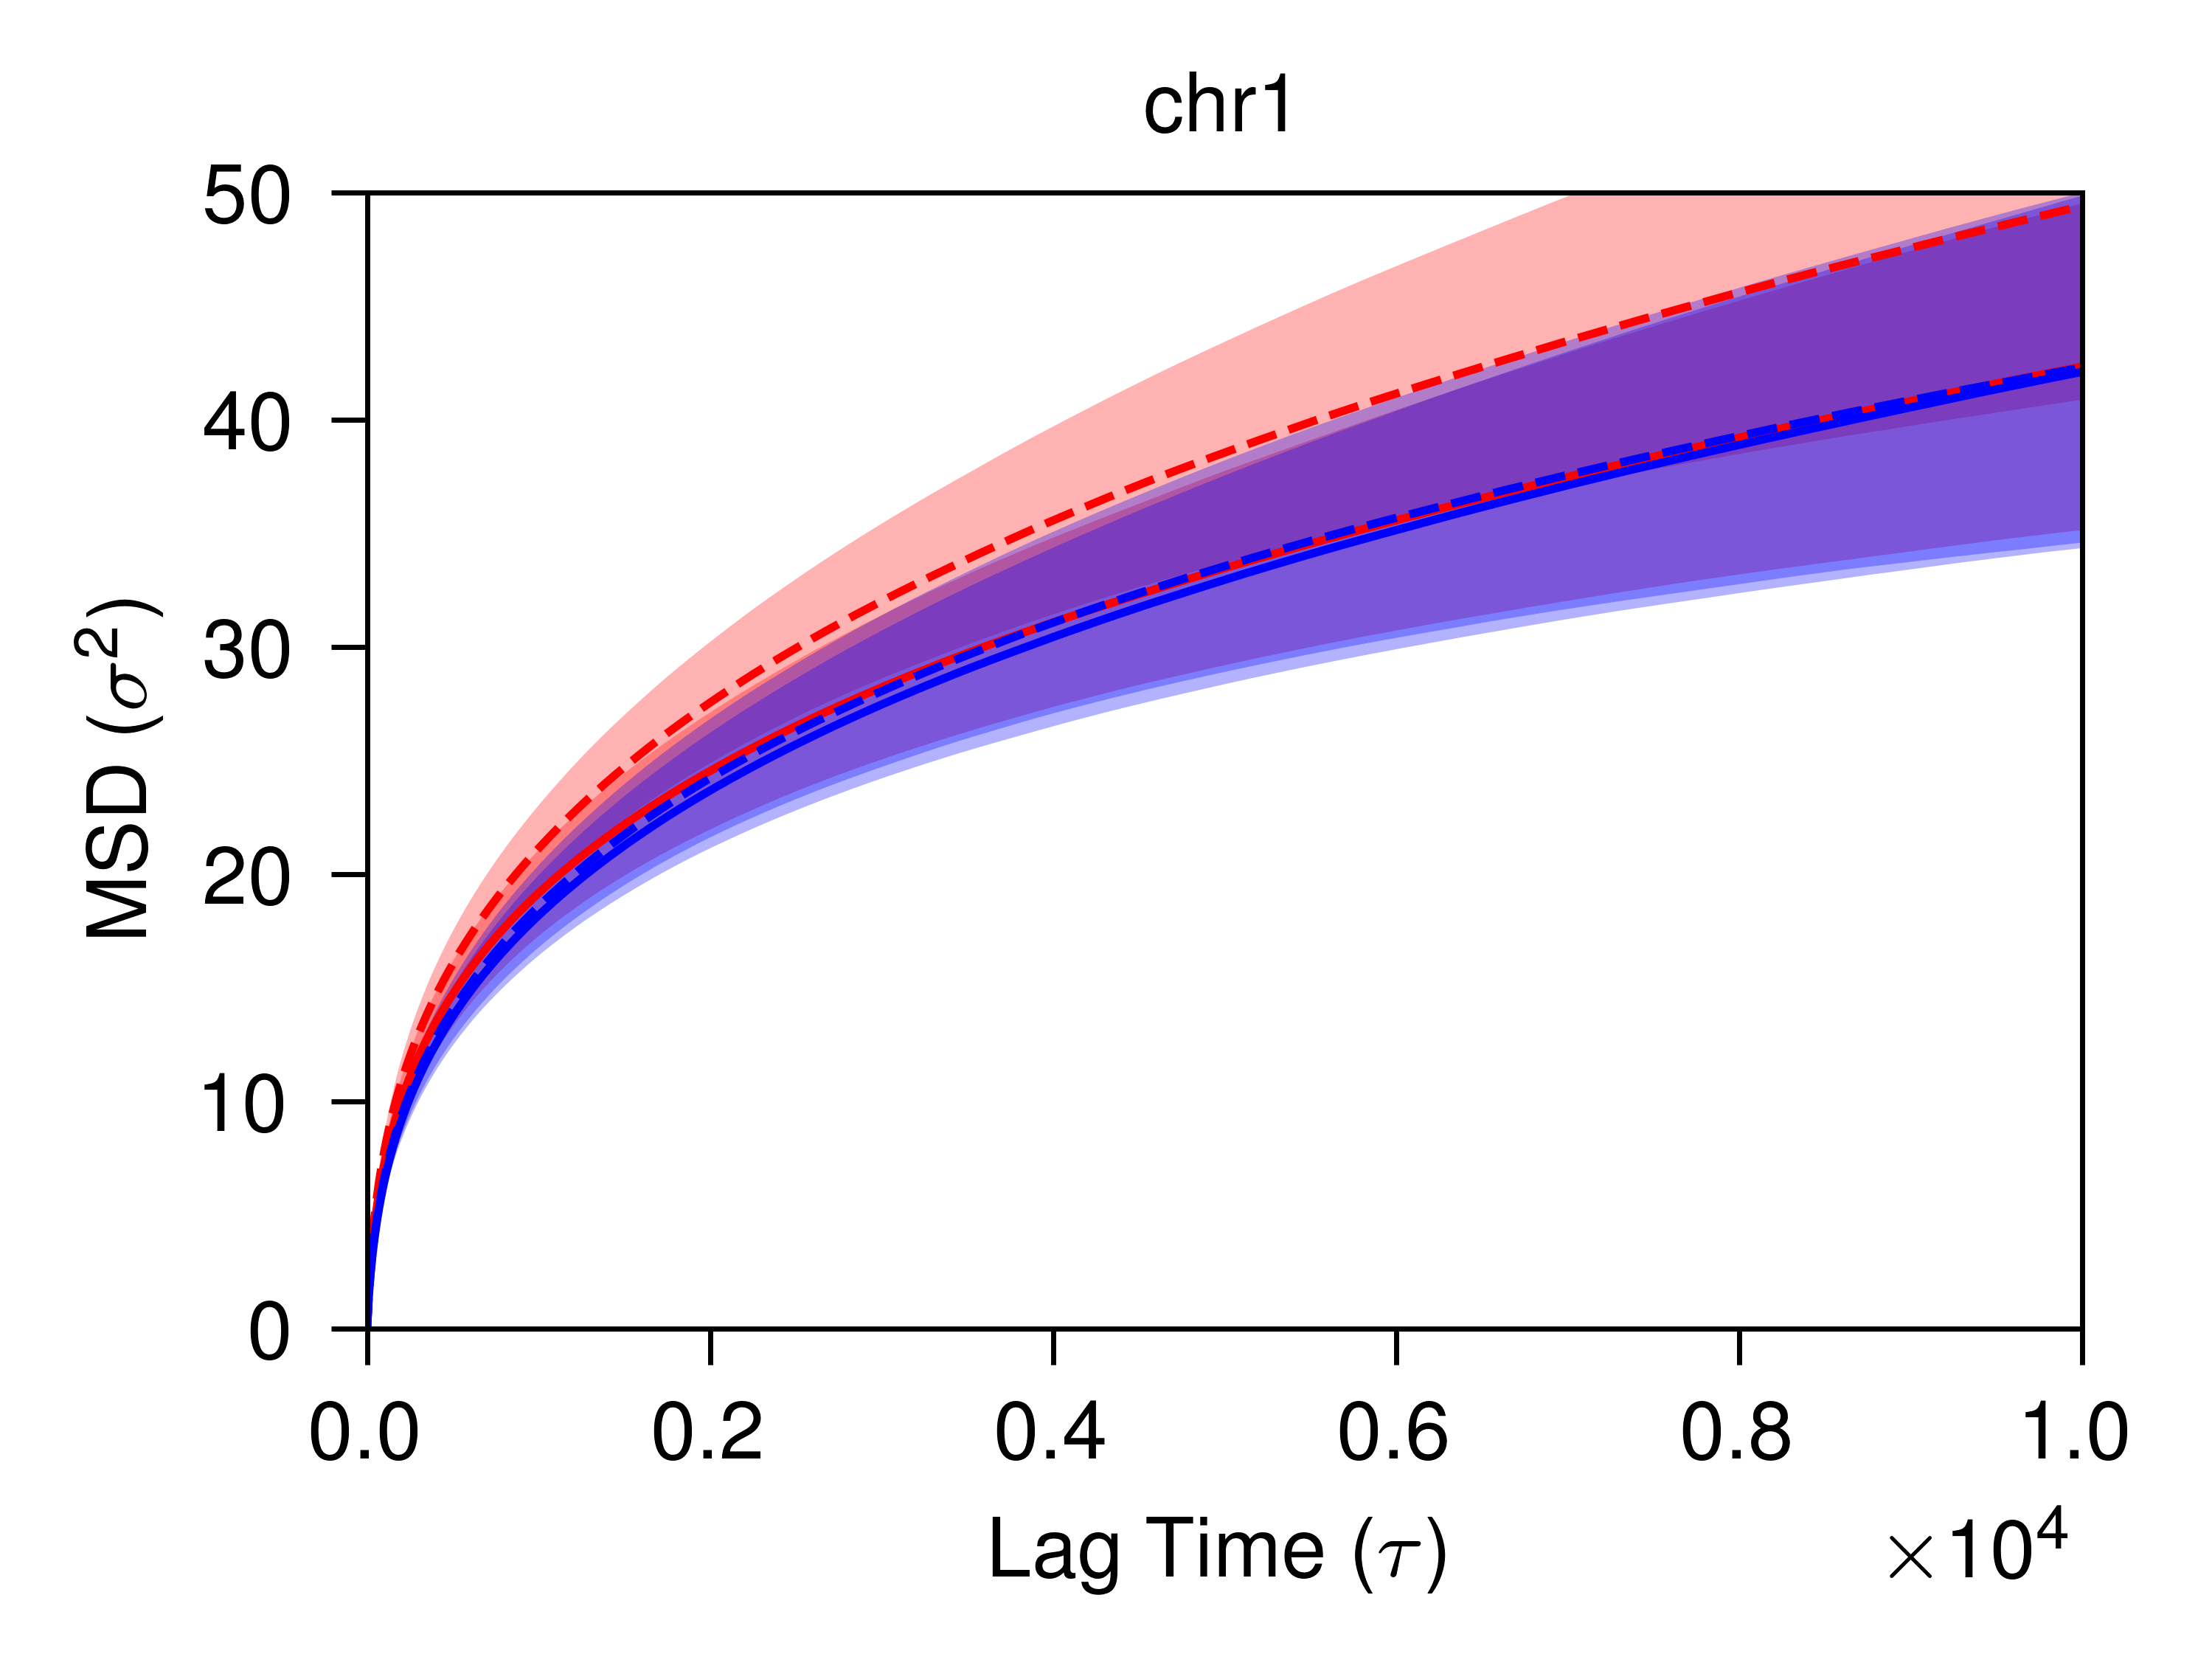

In [43]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

lag = np.arange(msd["complete"]["A"].shape[0]) * 1000 * 0.01  # in tau

ax.plot(
    lag,
    msd["complete"]["A"],
    label=r"$\in$ lamina, A",
    color="red",
)
ax.fill_between(
    lag,
    msd["complete"]["A"] - msd_std["complete"]["A"],
    msd["complete"]["A"] + msd_std["complete"]["A"],
    color="red",
    alpha=0.3,
    edgecolor="none",
)

ax.plot(
    lag,
    msd["nucleolus"]["A"],
    "--",
    label=r"$\notin$ lamina, A",
    color="red",
)
ax.fill_between(
    lag,
    msd["nucleolus"]["A"] - msd_std["nucleolus"]["A"],
    msd["nucleolus"]["A"] + msd_std["nucleolus"]["A"],
    color="red",
    alpha=0.3,
    edgecolor="none",
)

ax.plot(
    lag,
    msd["complete"]["B"],
    label=r"$\in$ lamina, B",
    color="blue",
)
ax.fill_between(
    lag,
    msd["complete"]["B"] - msd_std["complete"]["B"],
    msd["complete"]["B"] + msd_std["complete"]["B"],
    color="blue",
    alpha=0.3,
    edgecolor="none",
)

ax.plot(
    lag,
    msd["nucleolus"]["B"],
    "--",
    label=r"$\notin$ lamina, B",
    color="blue",
)
ax.fill_between(
    lag,
    msd["nucleolus"]["B"] - msd_std["nucleolus"]["B"],
    msd["nucleolus"]["B"] + msd_std["nucleolus"]["B"],
    color="blue",
    alpha=0.3,
    edgecolor="none",
)

ax.set_ylabel(r"MSD ($\sigma^2$)")
ax.set_xlabel(r"Lag Time ($\tau$)")

ax.set_xlim(left=lag[0], right=lag[1000])
ax.set_ylim(0, 50)

# ax.legend()

ax.set_title(f"chr{chromosome}", fontsize=8)

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation
ax.xaxis.set_major_formatter(formatter)

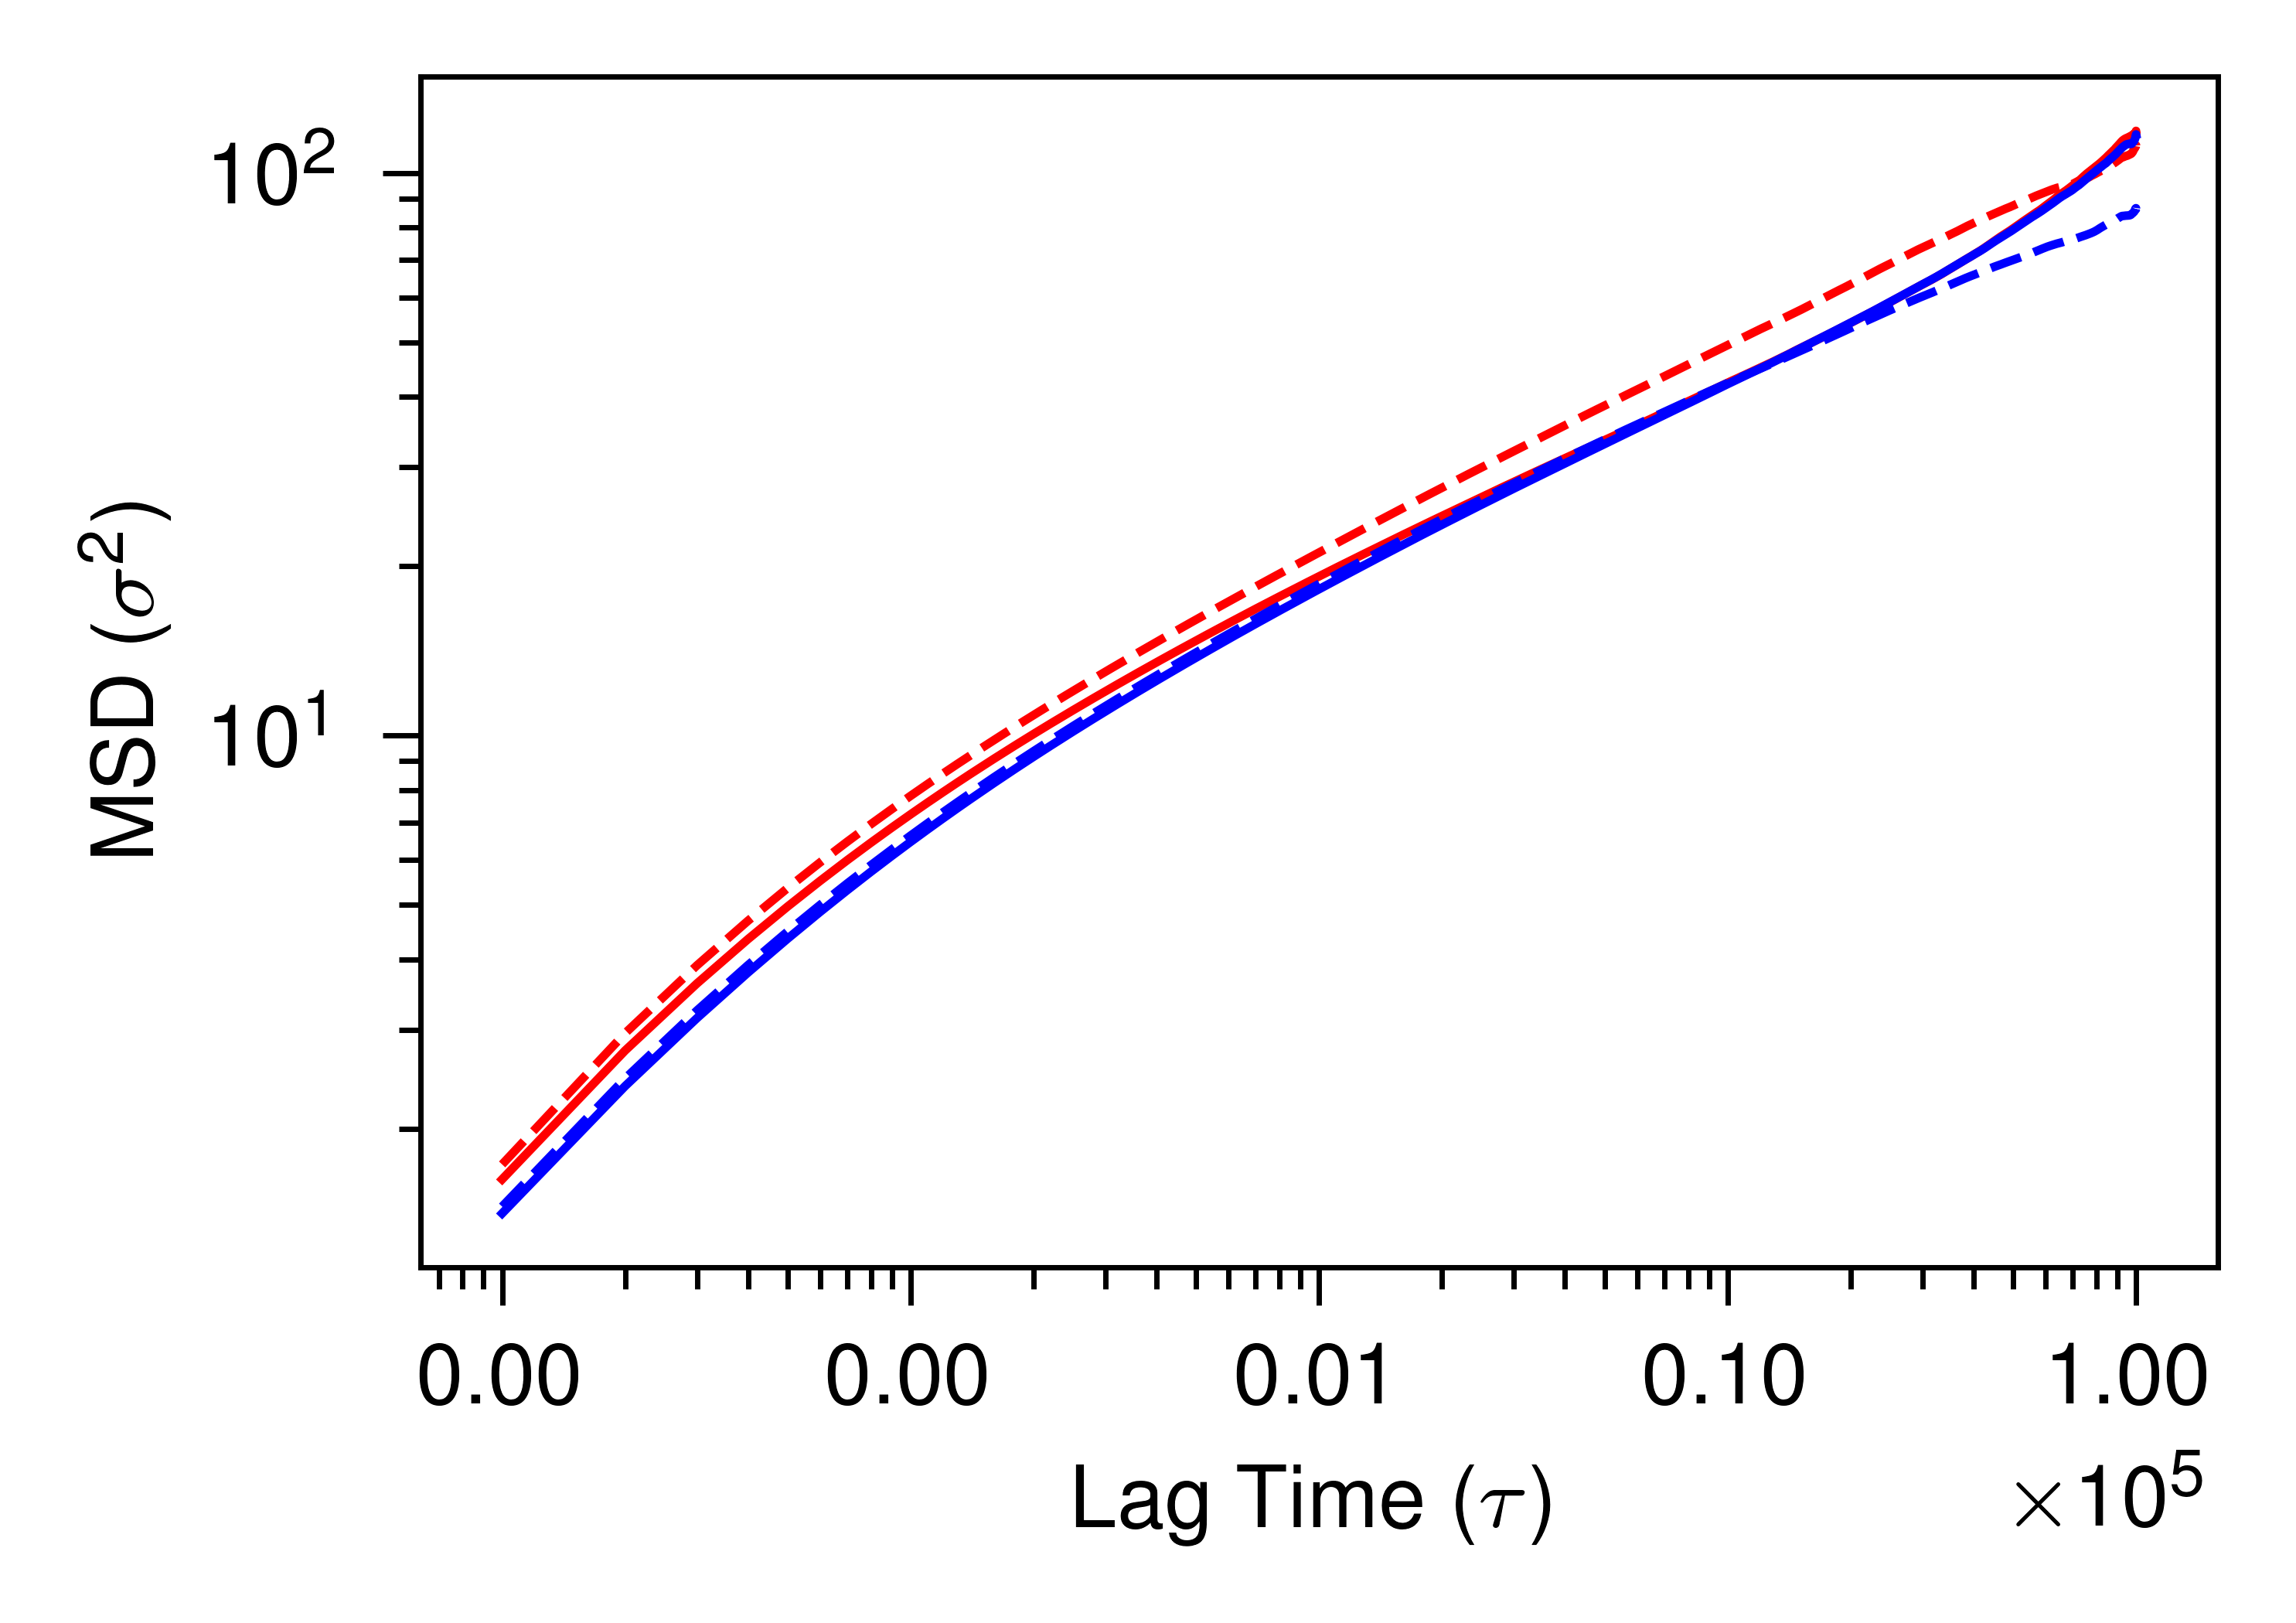

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

lag = np.arange(msd["complete"]["A"].shape[0]) * 1000 * 0.01  # in tau

ax.loglog(
    lag[1:],
    msd["complete"]["A"][1:],
    label="A",
    color="red",
)
ax.loglog(
    lag[1:],
    msd["nucleolus"]["A"][1:],
    "--",
    label="A",
    color="red",
)
ax.loglog(
    lag[1:],
    msd["complete"]["B"][1:],
    label="B",
    color="blue",
)
ax.loglog(
    lag[1:],
    msd["nucleolus"]["B"][1:],
    "--",
    label="B",
    color="blue",
)

ax.set_ylabel(r"MSD ($\sigma^2$)")
ax.set_xlabel(r"Lag Time ($\tau$)")

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation

# Apply formatter
ax.xaxis.set_major_formatter(formatter)

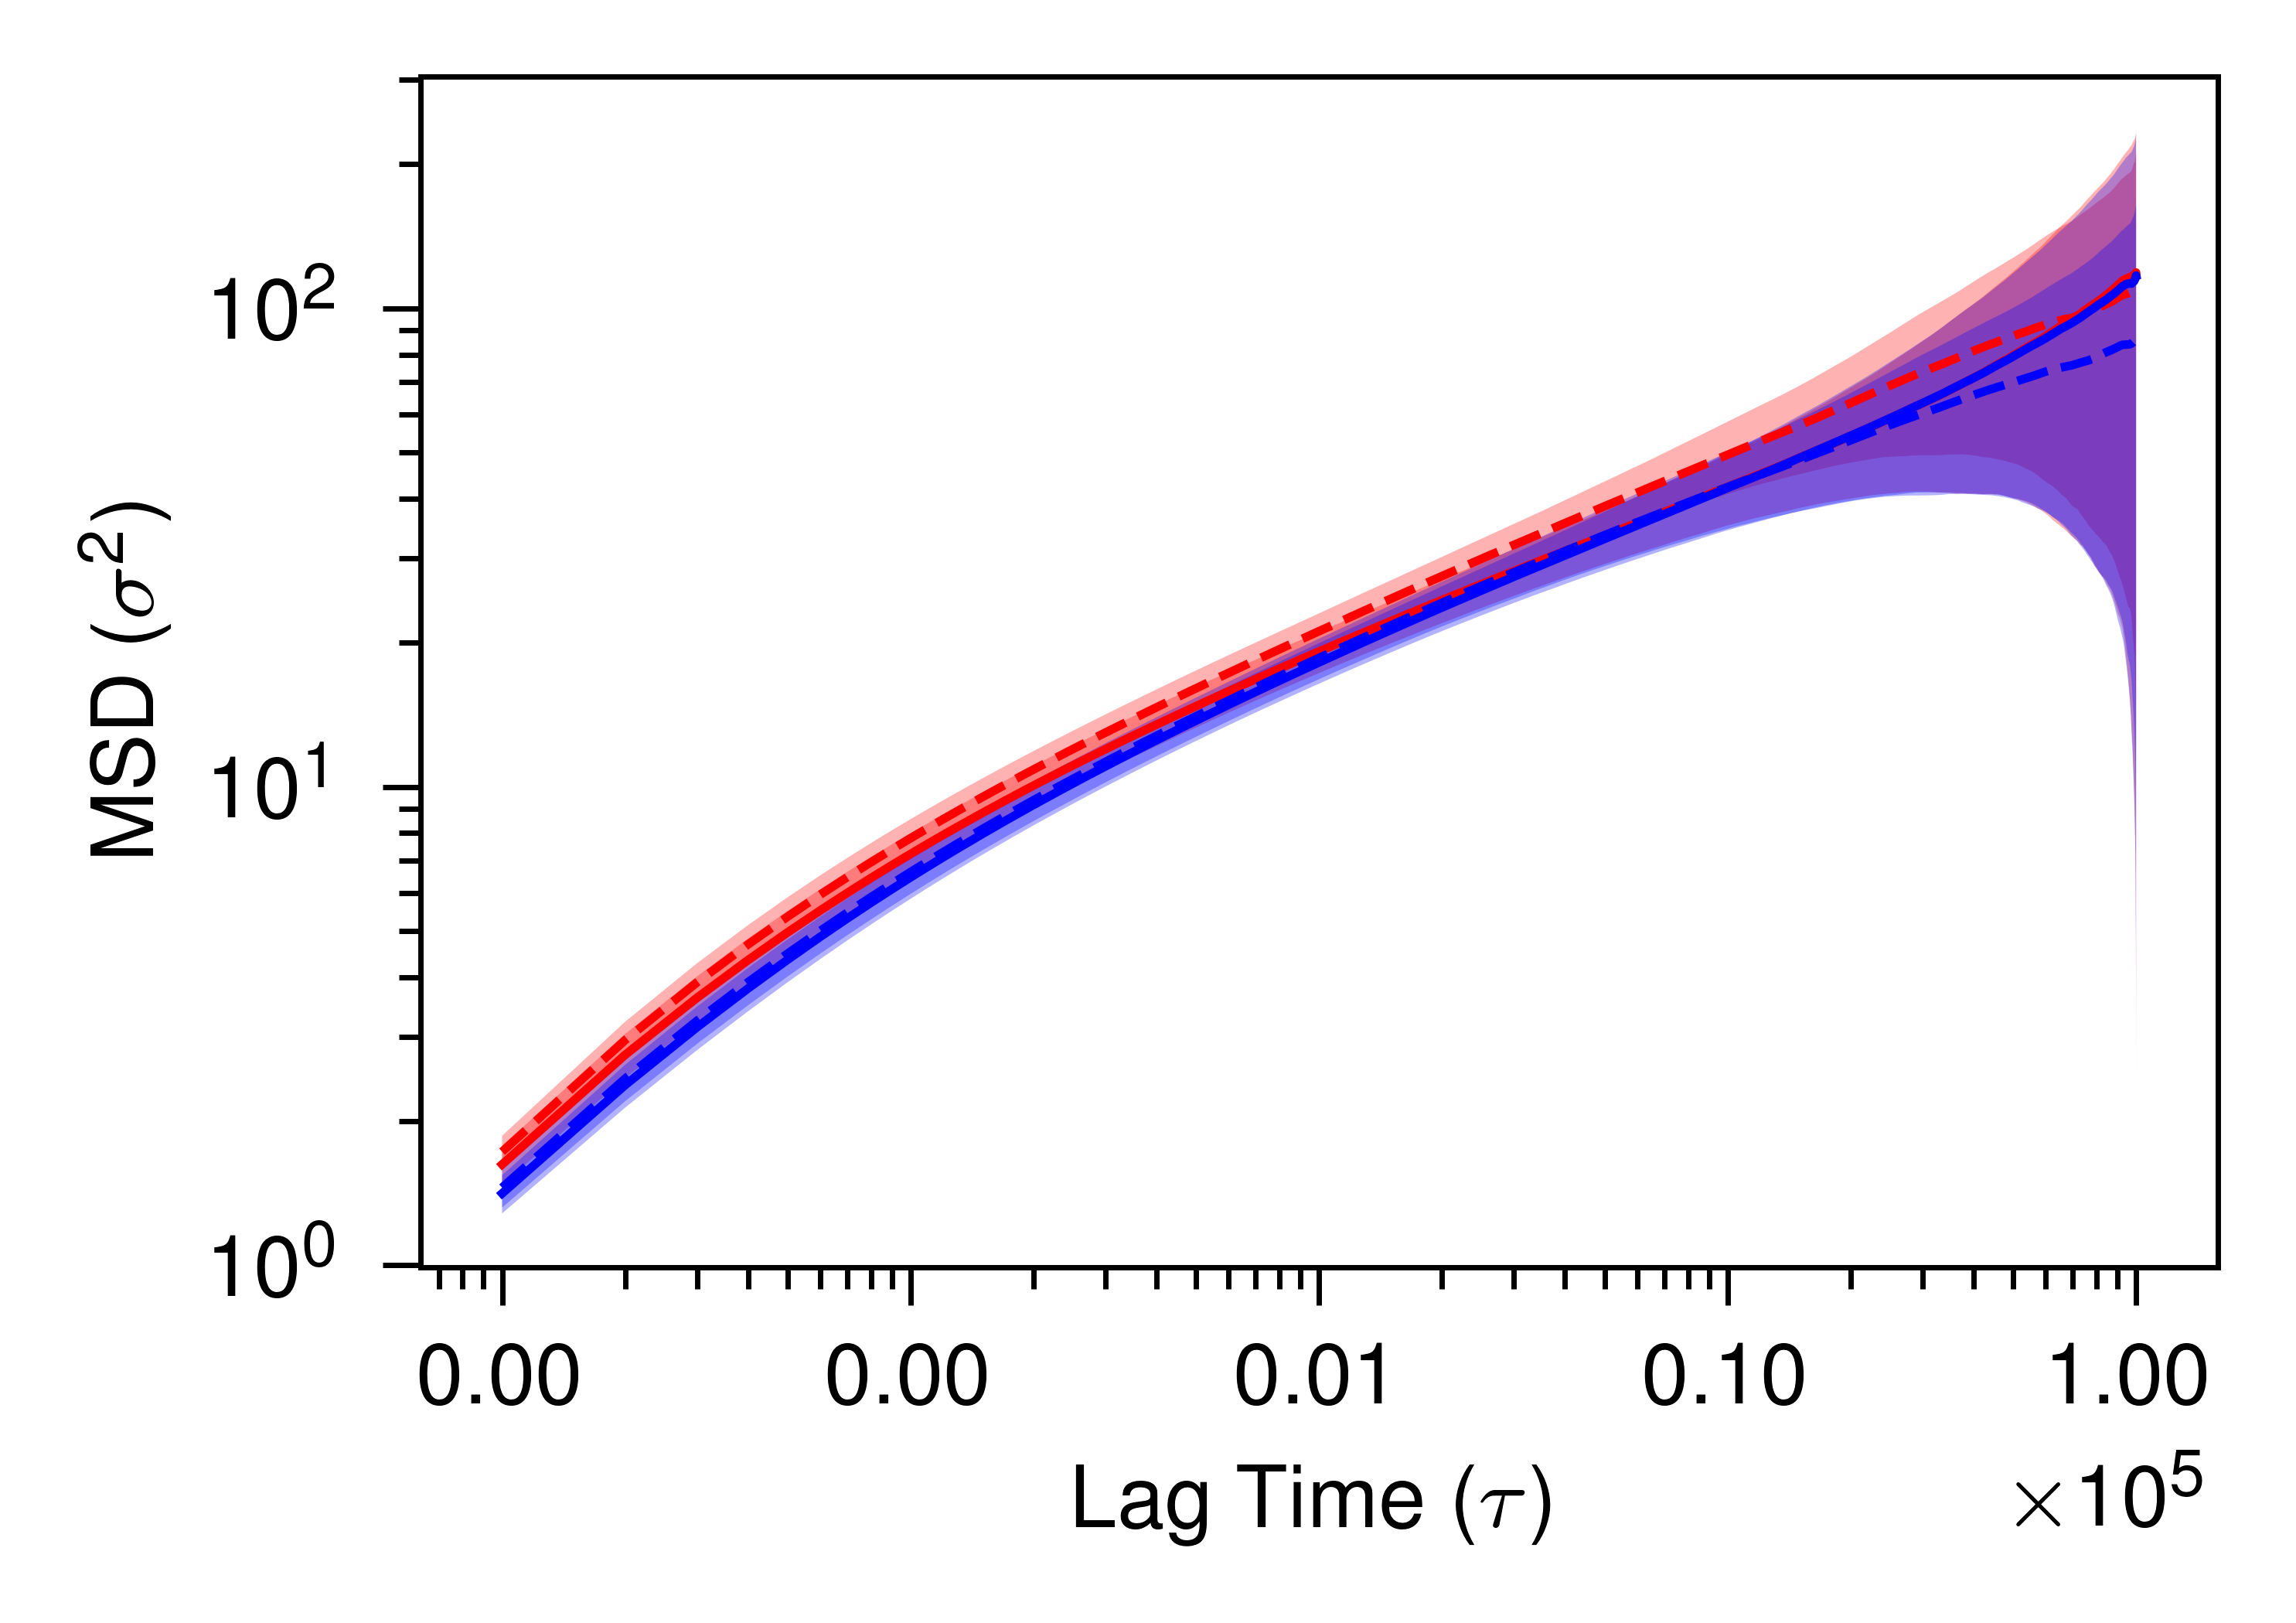

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

lag = np.arange(msd["complete"]["A"].shape[0]) * 1000 * 0.01  # in tau

ax.loglog(
    lag[1:],
    msd["complete"]["A"][1:],
    label="A",
    color="red",
)
ax.fill_between(
    lag[1:],
    msd["complete"]["A"][1:] - msd_std["complete"]["A"][1:],
    msd["complete"]["A"][1:] + msd_std["complete"]["A"][1:],
    color="red",
    alpha=0.3,
    edgecolor="none",
)

ax.loglog(
    lag[1:],
    msd["nucleolus"]["A"][1:],
    "--",
    label="A",
    color="red",
)
ax.fill_between(
    lag[1:],
    msd["nucleolus"]["A"][1:] - msd_std["nucleolus"]["A"][1:],
    msd["nucleolus"]["A"][1:] + msd_std["nucleolus"]["A"][1:],
    color="red",
    alpha=0.3,
    edgecolor="none",
)

ax.loglog(
    lag[1:],
    msd["complete"]["B"][1:],
    label="B",
    color="blue",
)
ax.fill_between(
    lag[1:],
    msd["complete"]["B"][1:] - msd_std["complete"]["B"][1:],
    msd["complete"]["B"][1:] + msd_std["complete"]["B"][1:],
    color="blue",
    alpha=0.3,
    edgecolor="none",
)

ax.loglog(
    lag[1:],
    msd["nucleolus"]["B"][1:],
    "--",
    label="B",
    color="blue",
)
ax.fill_between(
    lag[1:],
    msd["nucleolus"]["B"][1:] - msd_std["nucleolus"]["B"][1:],
    msd["nucleolus"]["B"][1:] + msd_std["nucleolus"]["B"][1:],
    color="blue",
    alpha=0.3,
    edgecolor="none",
)

ax.set_ylabel(r"MSD ($\sigma^2$)")
ax.set_xlabel(r"Lag Time ($\tau$)")

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation

# Apply formatter
ax.xaxis.set_major_formatter(formatter)

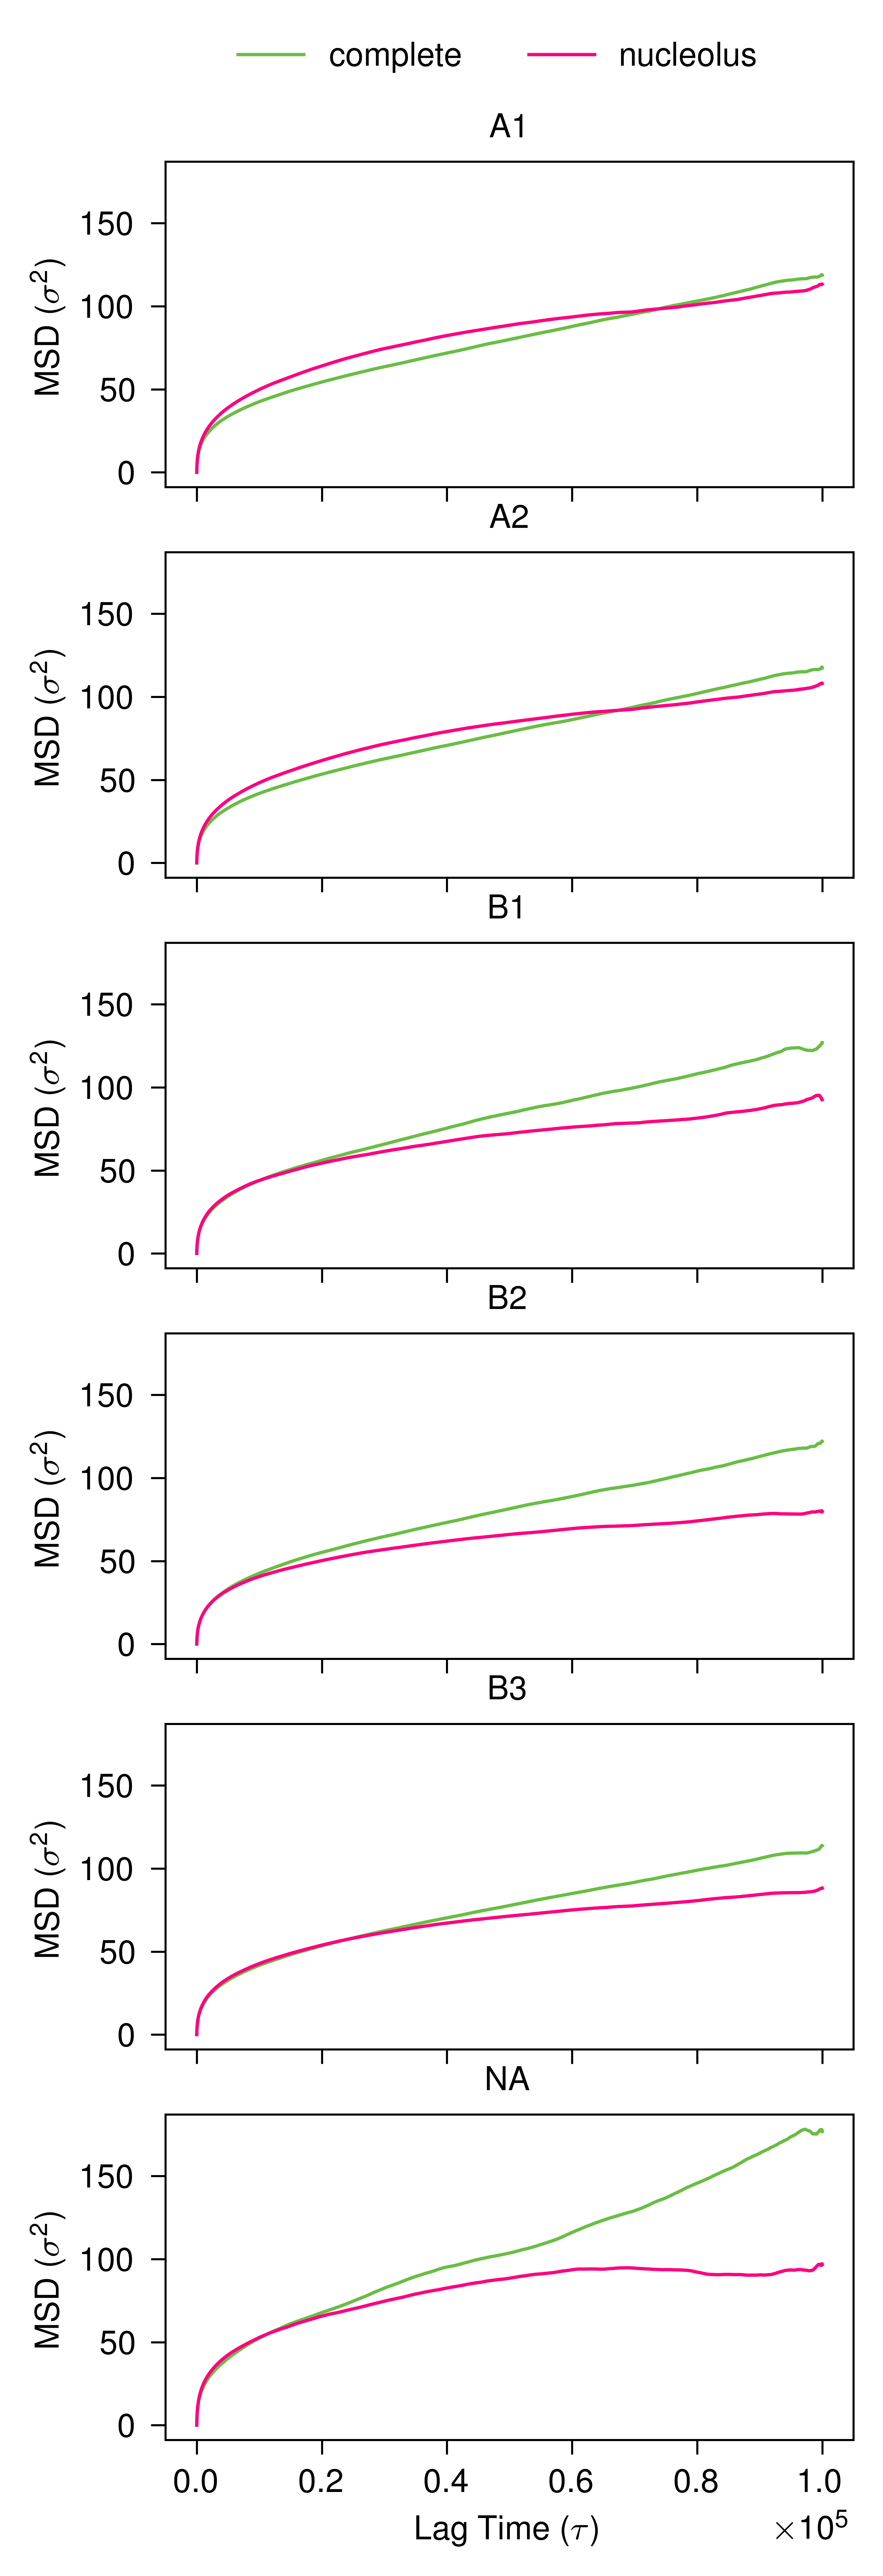

In [12]:
fig, ax = plt.subplots(
    6, 1, figsize=(3, 10), sharex=True, sharey=True
)

lag = np.arange(msd["complete"]["A"].shape[0]) * 1000 * 0.01  # in tau

# conditions = ["complete", "nucleolus", "lamina", "control"]

colors = {
    "complete": "#6abd45",
    "nucleolus": "#ff0080",
    "control": "#404040",
    "lamina": "#25C8FA",
    # "isolation": "#FFC083",
}

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation

for i, subcompartment in enumerate(
    ["A1", "A2", "B1", "B2", "B3", "NA"]
):
    for condition in conditions:
        ax[i].plot(
            lag,
            msd[condition][subcompartment],
            label=condition,
            color=colors[condition],
        )

    ax[i].set_title(f"{subcompartment}")
    ax[i].set_ylabel(r"MSD ($\sigma^2$)")
    if i == 5:
        ax[i].set_xlabel(r"Lag Time ($\tau$)")

    ax[i].xaxis.set_major_formatter(formatter)

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.9),
)

### lamina contact

In [13]:
data_path_lamina = f"/scratch/mm146/Polarization/{folder_num}_IMR-90_hg38_chr{chromosome}/7_analysis/msd/data/msd-average-per-compartment-lamina.h5"

msd_lamina = {}
with h5py.File(
    data_path_lamina,
    "r",
) as f_in:
    for group in f_in.keys():
        msd_lamina[group] = {}
        for compartment in f_in[group].keys():
            msd_lamina[group][compartment] = f_in[group][
                compartment
            ][()]

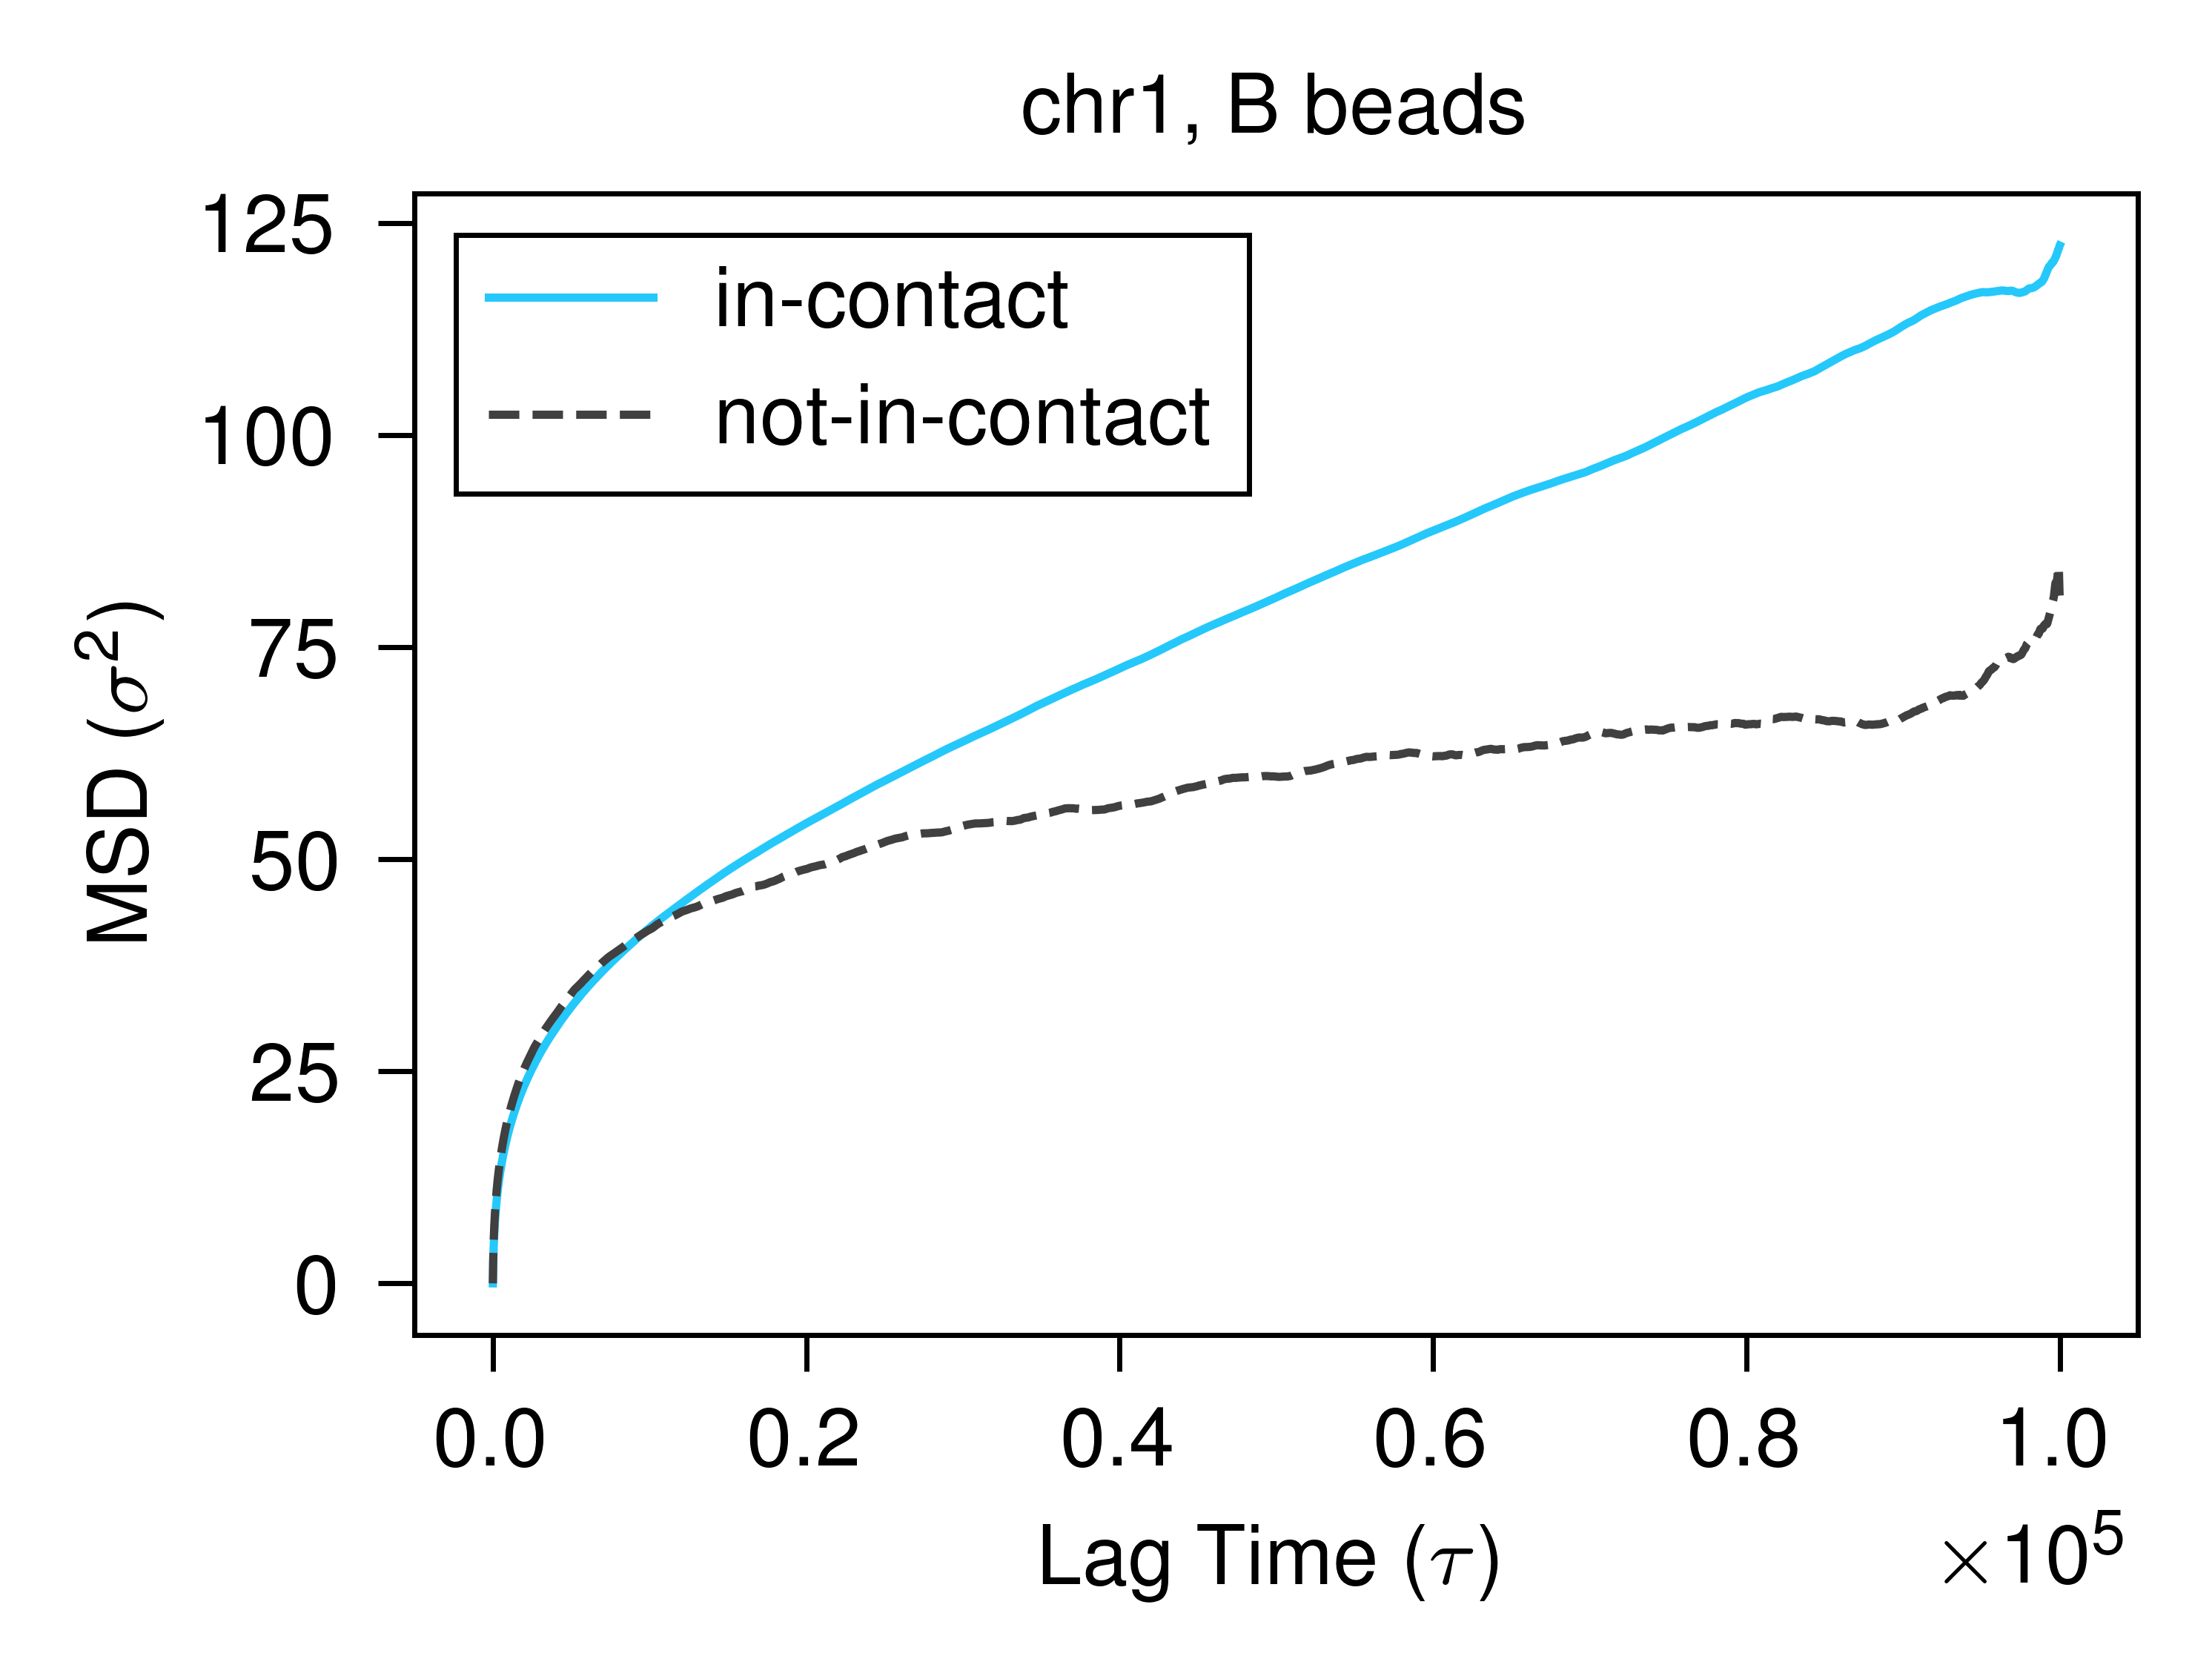

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

lag = np.arange(msd_lamina["in-contact"]["B"].shape[0]) * 1000 * 0.01  # in tau

ax.plot(
    lag,
    msd_lamina["in-contact"]["B"],
    label="in-contact",
    color="#25C8FA",
)
ax.plot(
    lag,
    msd_lamina["not-in-contact"]["B"],
    "--",
    label="not-in-contact",
    color="#404040",
)

ax.set_ylabel(r"MSD ($\sigma^2$)")
ax.set_xlabel(r"Lag Time ($\tau$)")

ax.legend()

ax.set_title(f"chr{chromosome}, B beads", fontsize=8)

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation
ax.xaxis.set_major_formatter(formatter)

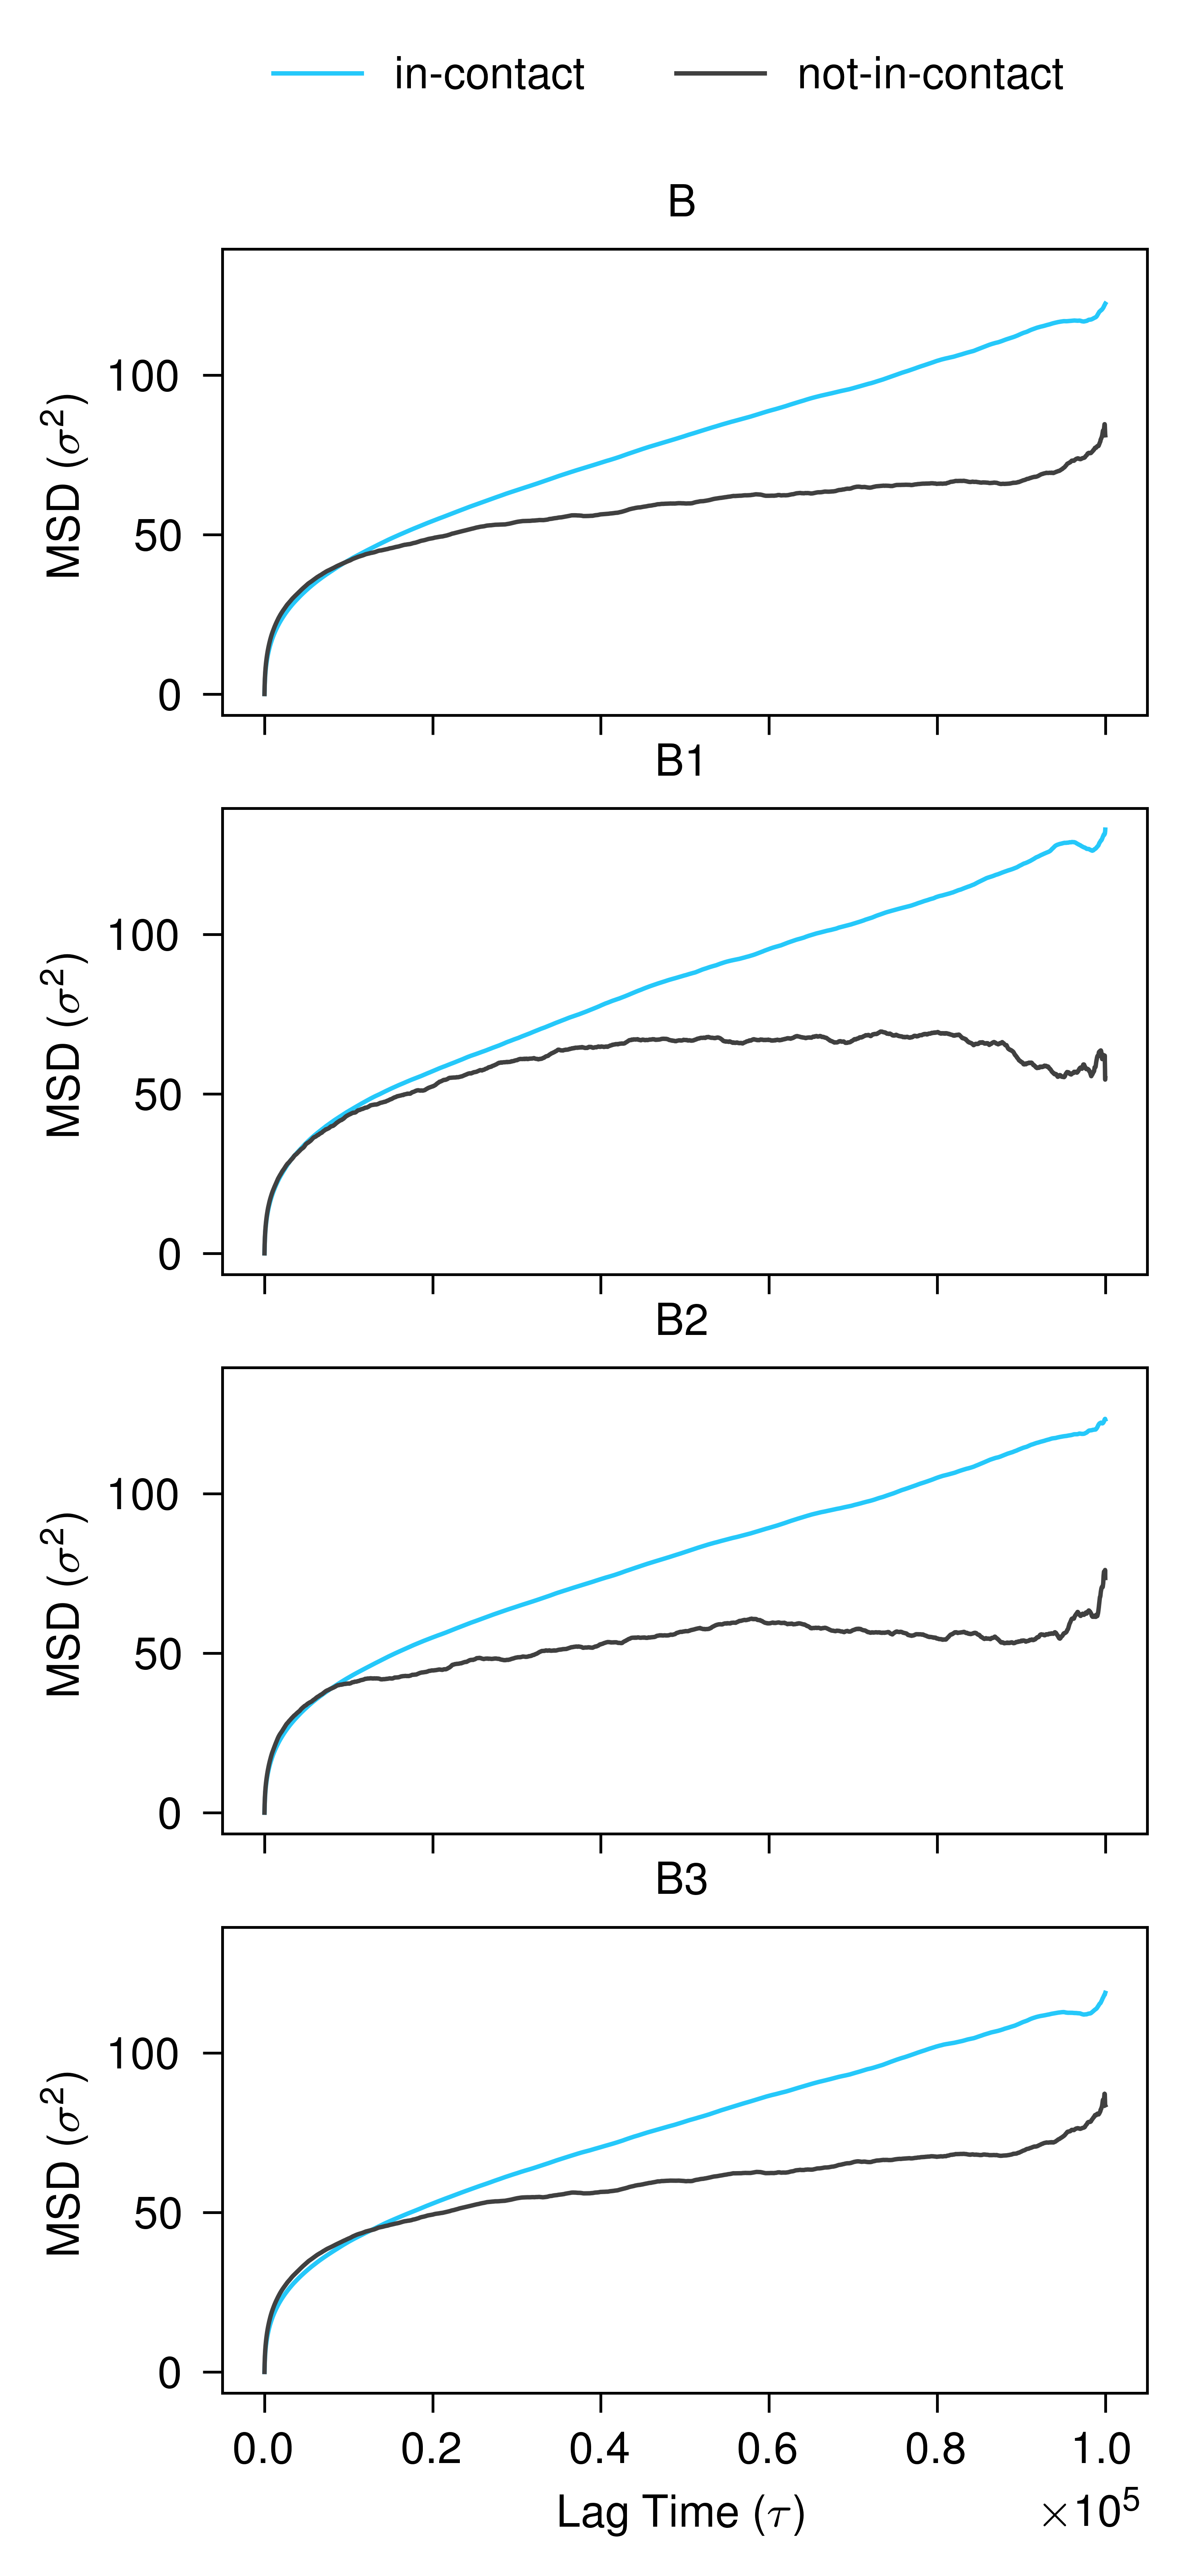

In [44]:
fig, ax = plt.subplots(4, 1, figsize=(3, 7), sharex=True, sharey=True)

lag = np.arange(msd_lamina["in-contact"]["B"].shape[0]) * 1000 * 0.01  # in tau

groups = ["in-contact", "not-in-contact"]
colors = {
    "in-contact": "#25C8FA",
    "not-in-contact": "#404040",
}

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation

for i, subcompartment in enumerate(["B", "B1", "B2", "B3"]):
    for group in groups:
        ax[i].plot(
            lag,
            msd_lamina[group][subcompartment],
            label=group,
            color=colors[group],
        )

    ax[i].set_title(f"{subcompartment}")
    ax[i].set_ylabel(r"MSD ($\sigma^2$)")
    if i == 3:
        ax[i].set_xlabel(r"Lag Time ($\tau$)")

    ax[i].xaxis.set_major_formatter(formatter)

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.92),
)

## chr1 - ∆lam = 1.5 & undivided


In [6]:
chromosome = 1
folder_num = 4 if chromosome == 1 else 5

data_path = f"/scratch/mm146/Polarization/{folder_num}_IMR-90_hg38_chr{chromosome}/9_analysis/msd/data/msd-average-per-compartment.h5"

conditions = ["complete", "nucleolus"]

In [7]:
msd = {}
with h5py.File(
    data_path,
    "r",
) as f_in:
    for condition in f_in.keys():
        msd[condition] = {}
        for compartment in f_in[condition].keys():
            msd[condition][compartment] = f_in[condition][
                compartment
            ][()]

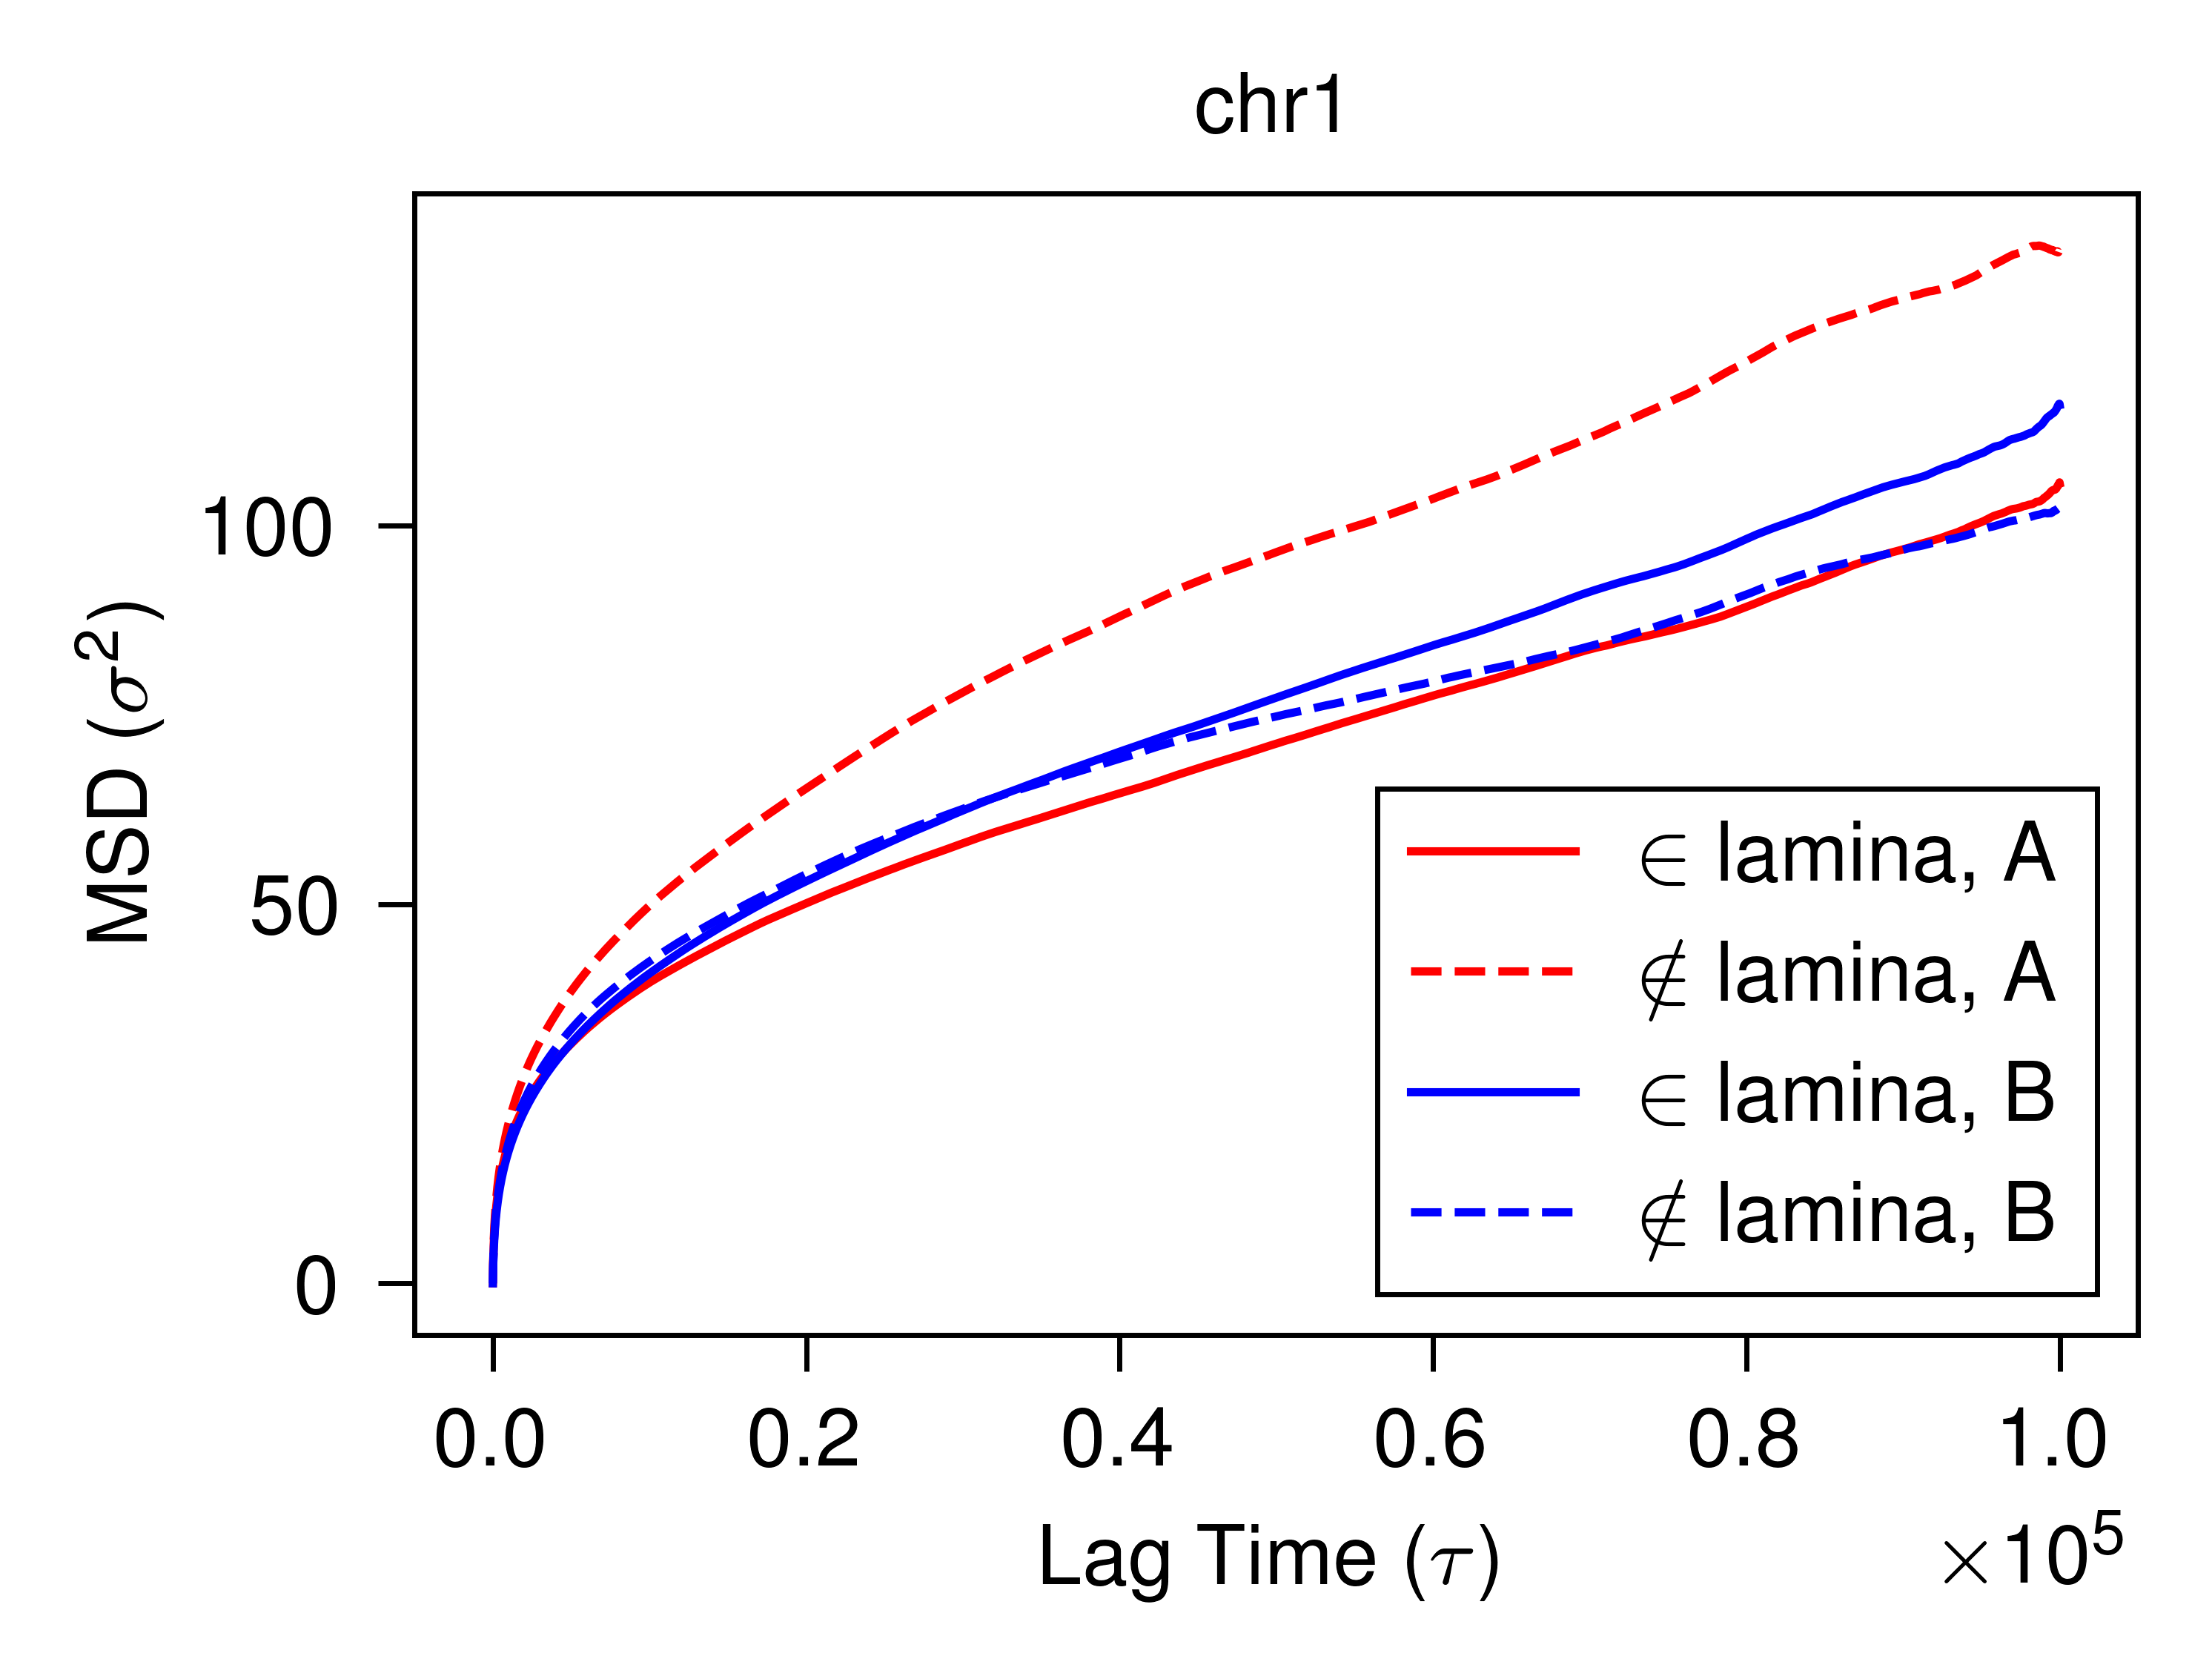

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

lag = np.arange(msd["complete"]["A"].shape[0]) * 1000 * 0.01  # in tau

ax.plot(
    lag,
    msd["complete"]["A"],
    label=r"$\in$ lamina, A",
    color="red",
)
ax.plot(
    lag,
    msd["nucleolus"]["A"],
    "--",
    label=r"$\notin$ lamina, A",
    color="red",
)
ax.plot(
    lag,
    msd["complete"]["B"],
    label=r"$\in$ lamina, B",
    color="blue",
)
ax.plot(
    lag,
    msd["nucleolus"]["B"],
    "--",
    label=r"$\notin$ lamina, B",
    color="blue",
)

ax.set_ylabel(r"MSD ($\sigma^2$)")
ax.set_xlabel(r"Lag Time ($\tau$)")

ax.legend()

ax.set_title(f"chr{chromosome}", fontsize=8)

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation
ax.xaxis.set_major_formatter(formatter)

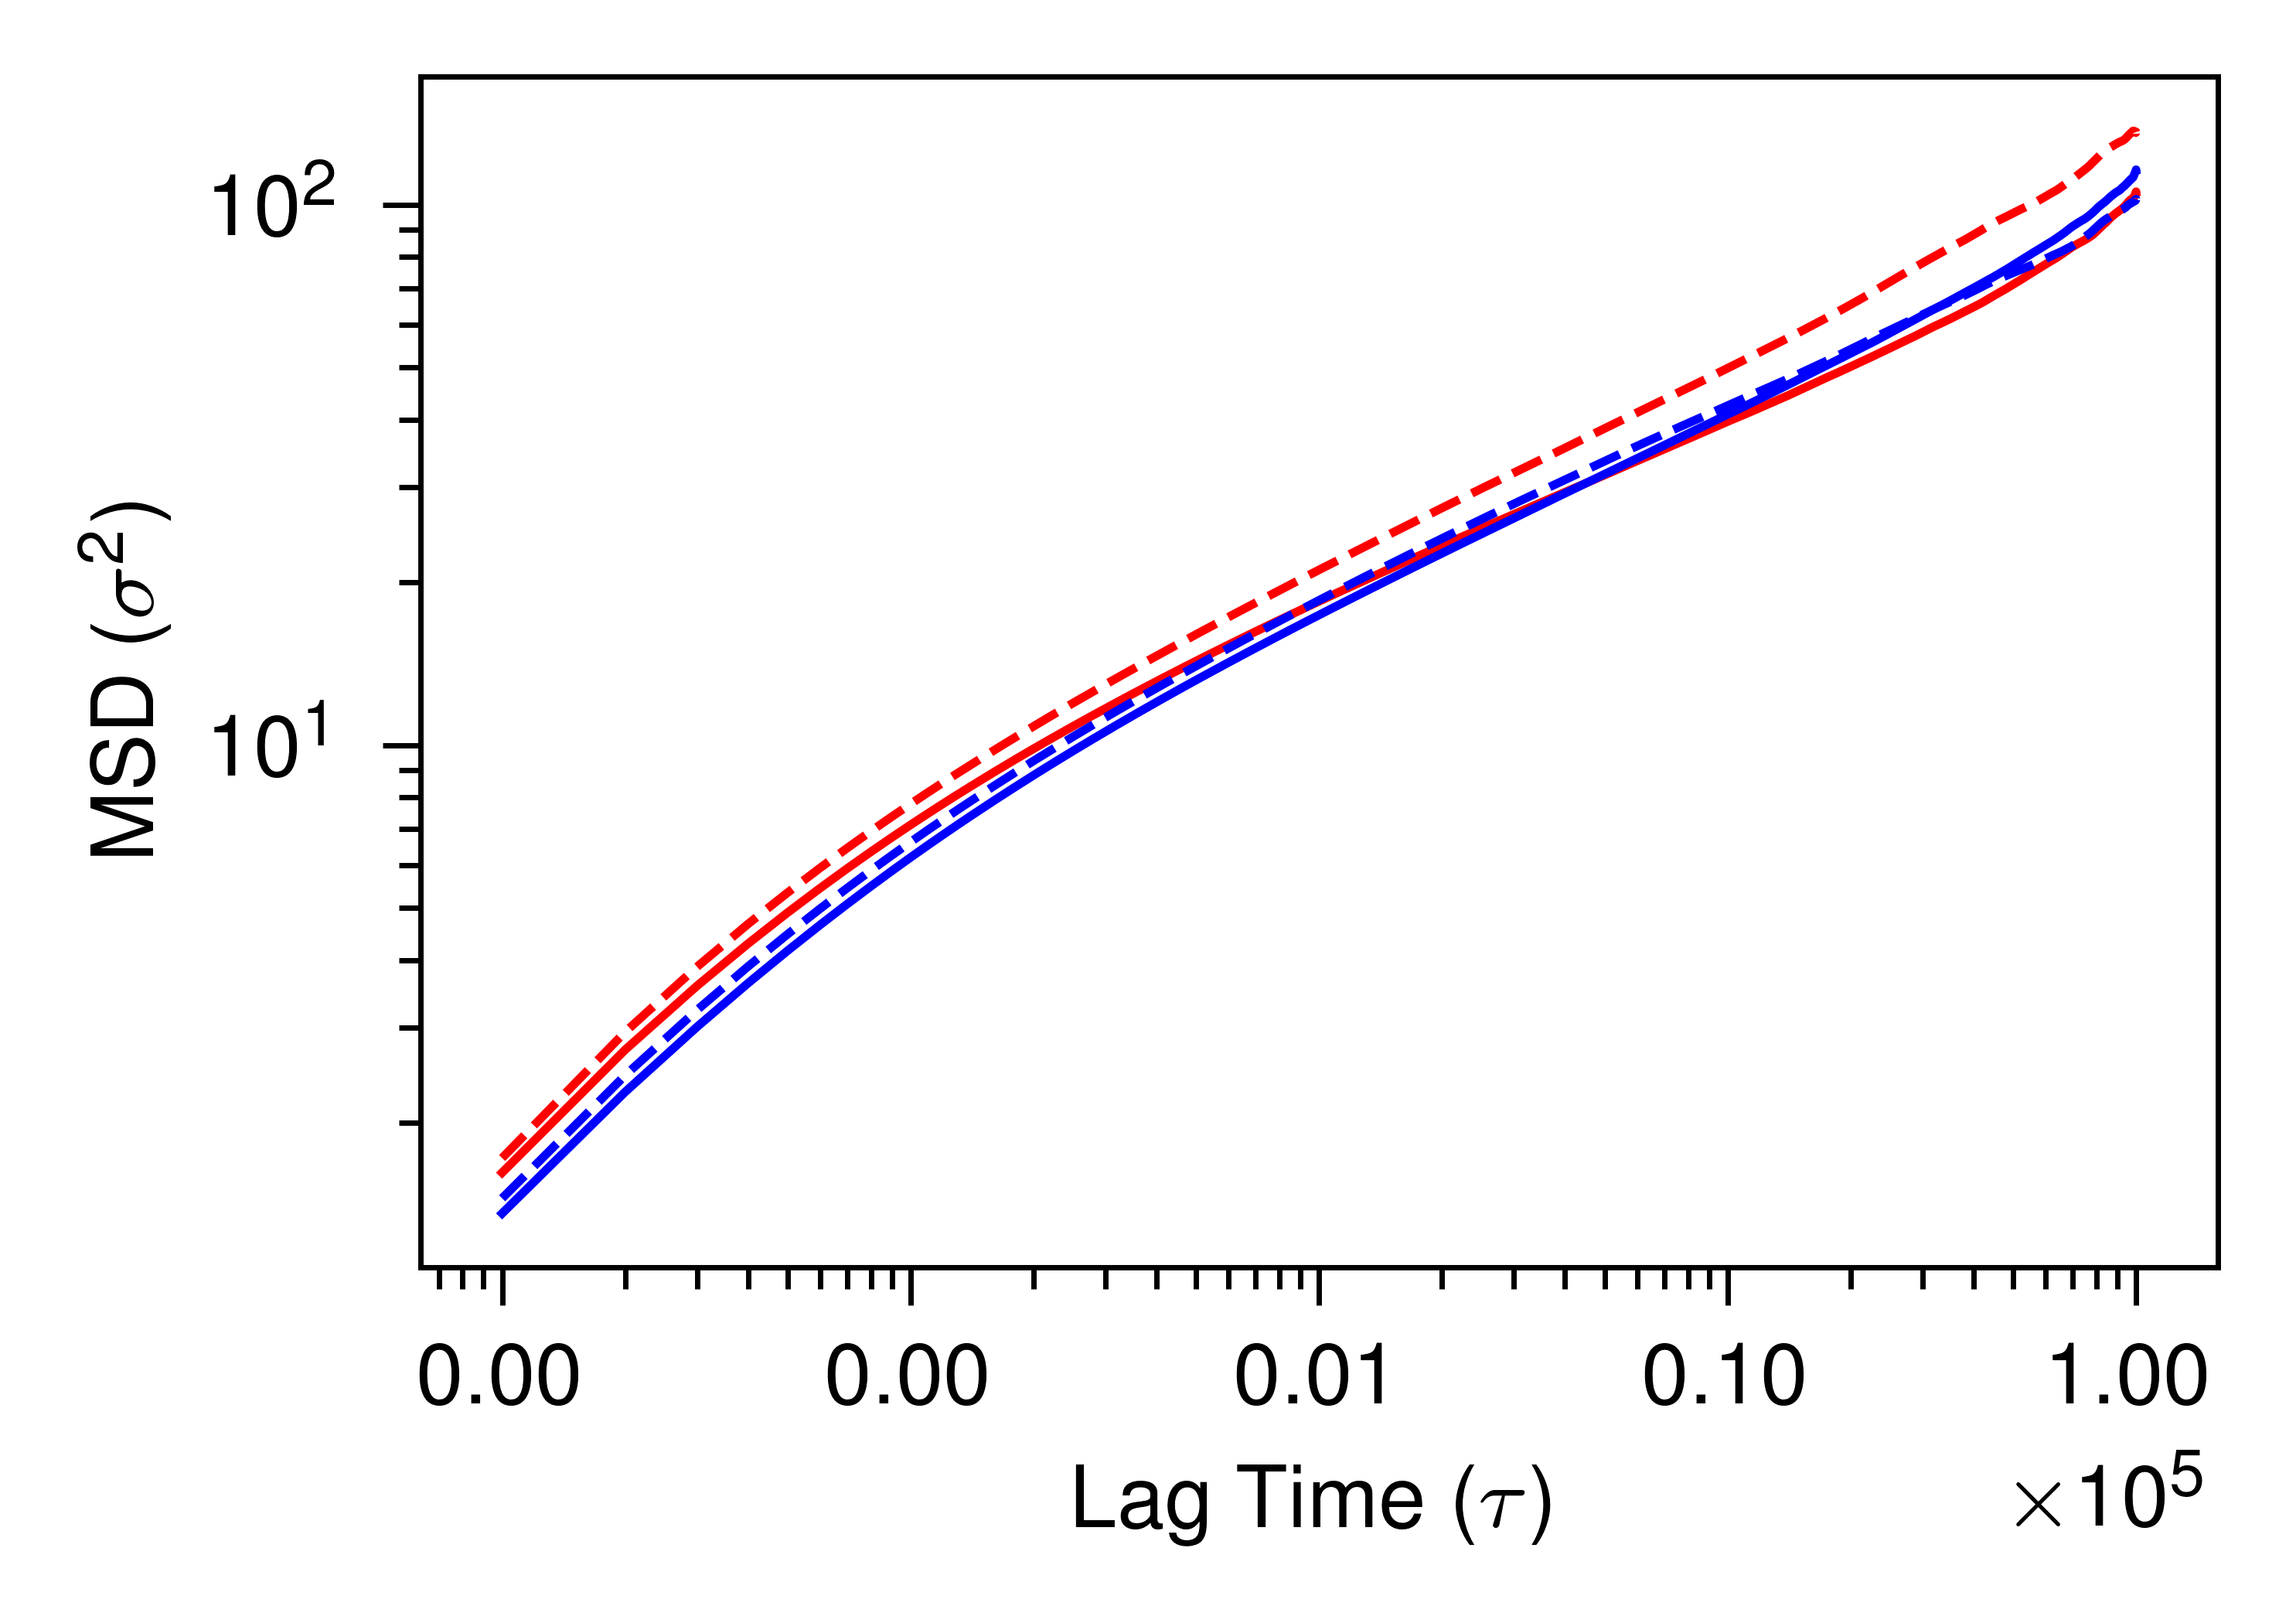

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

lag = np.arange(msd["complete"]["A"].shape[0]) * 1000 * 0.01  # in tau

ax.loglog(
    lag[1:],
    msd["complete"]["A"][1:],
    label="A",
    color="red",
)
ax.loglog(
    lag[1:],
    msd["nucleolus"]["A"][1:],
    "--",
    label="A",
    color="red",
)
ax.loglog(
    lag[1:],
    msd["complete"]["B"][1:],
    label="B",
    color="blue",
)
ax.loglog(
    lag[1:],
    msd["nucleolus"]["B"][1:],
    "--",
    label="B",
    color="blue",
)

ax.set_ylabel(r"MSD ($\sigma^2$)")
ax.set_xlabel(r"Lag Time ($\tau$)")

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation

# Apply formatter
ax.xaxis.set_major_formatter(formatter)

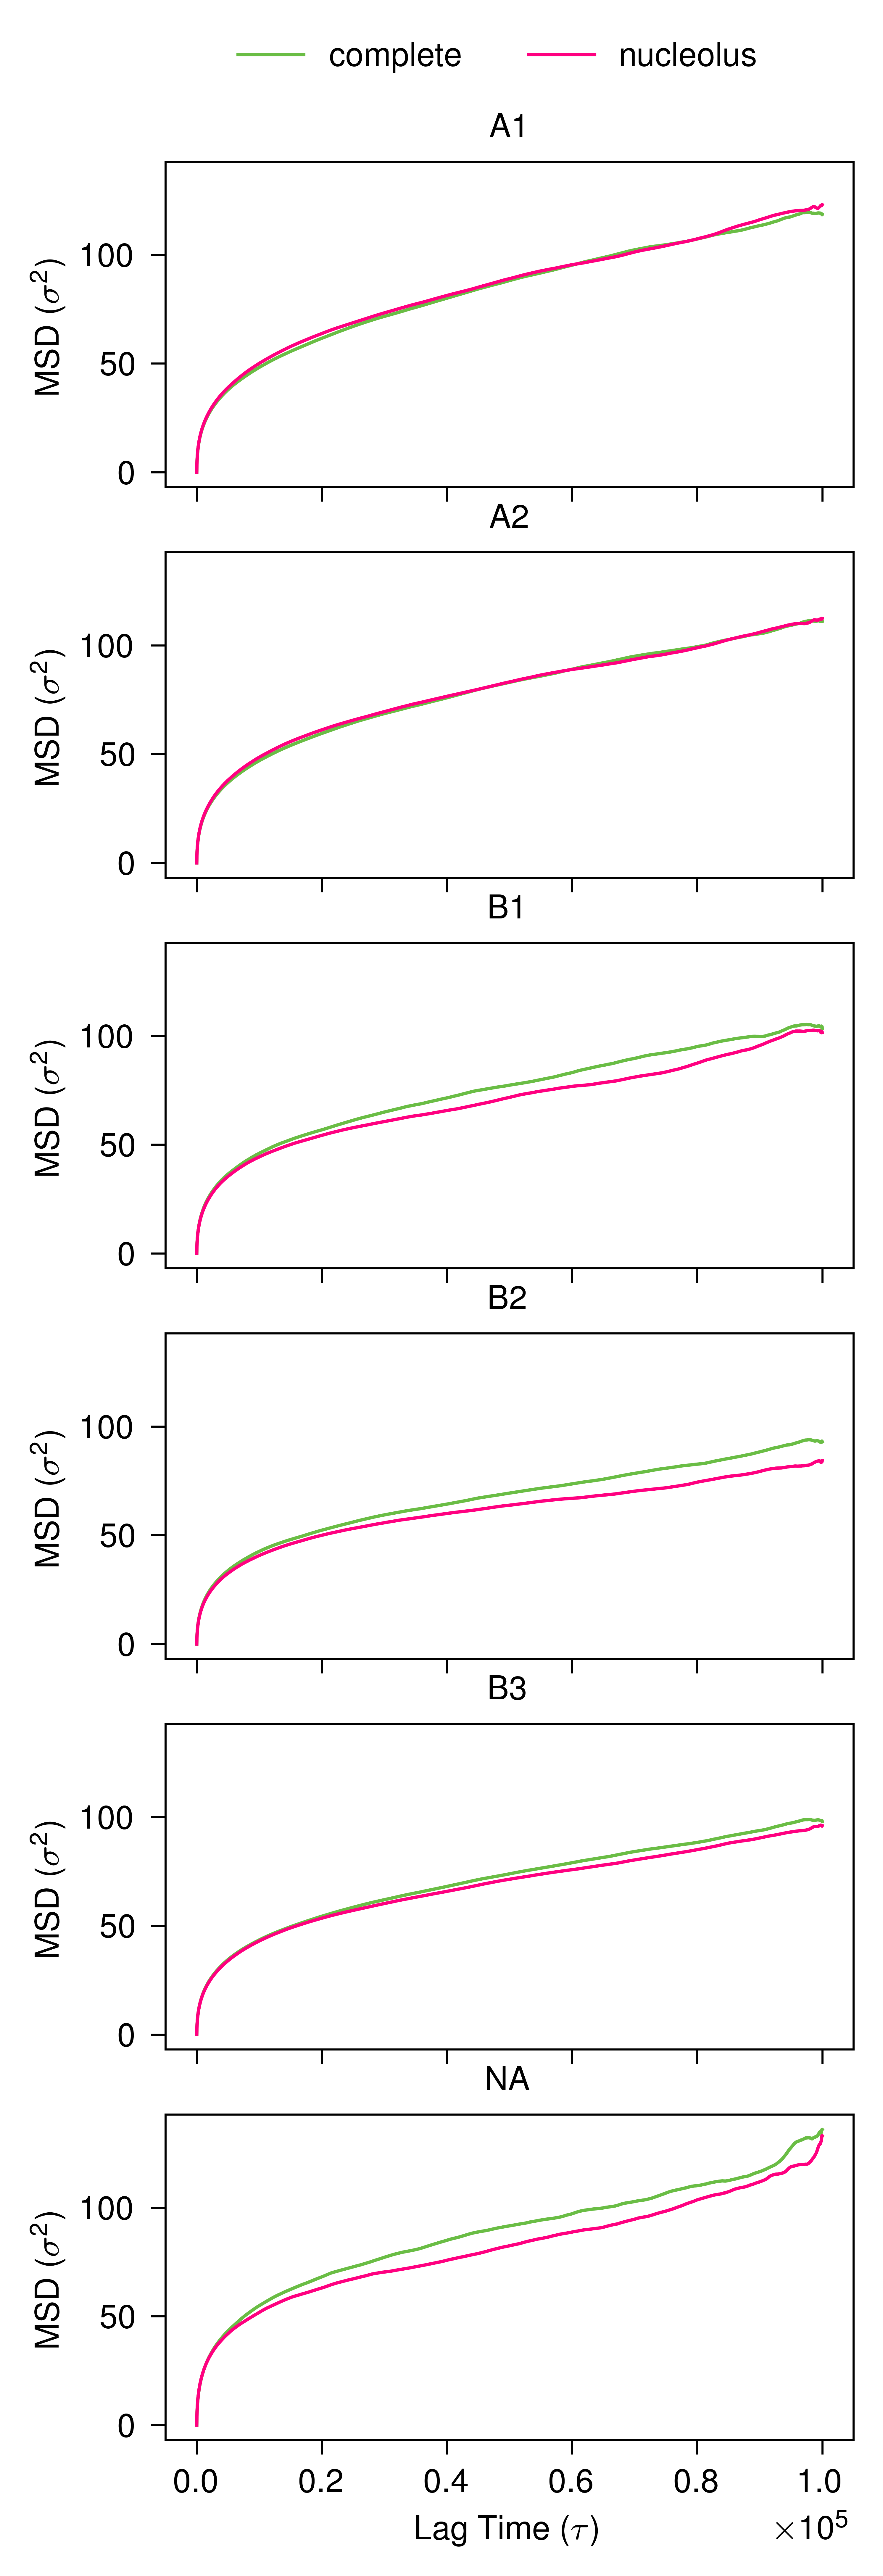

In [ ]:
fig, ax = plt.subplots(
    6, 1, figsize=(3, 10), sharex=True, sharey=True
)

lag = np.arange(msd["complete"]["A"].shape[0]) * 1000 * 0.01  # in tau

# conditions = ["complete", "nucleolus", "lamina", "control"]

colors = {
    "complete": "#6abd45",
    "nucleolus": "#ff0080",
    "control": "#404040",
    "lamina": "#25C8FA",
    # "isolation": "#FFC083",
}

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation

for i, subcompartment in enumerate(
    ["A1", "A2", "B1", "B2", "B3", "NA"]
):
    for condition in conditions:
        ax[i].plot(
            lag,
            msd[condition][subcompartment],
            label=condition,
            color=colors[condition],
        )

    ax[i].set_title(f"{subcompartment}")
    ax[i].set_ylabel(r"MSD ($\sigma^2$)")
    if i == 5:
        ax[i].set_xlabel(r"Lag Time ($\tau$)")

    ax[i].xaxis.set_major_formatter(formatter)

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.9),
)

## chr17

In [17]:
chromosome = 17
folder_num = 4 if chromosome == 1 else 5

data_path = f"/scratch/mm146/Polarization/{folder_num}_IMR-90_hg38_chr{chromosome}/7_analysis/msd/data/msd-average-per-compartment.h5"

In [18]:
msd = {}
with h5py.File(
    data_path,
    "r",
) as f_in:
    for condition in f_in.keys():
        msd[condition] = {}
        for compartment in f_in[condition].keys():
            msd[condition][compartment] = f_in[condition][
                compartment
            ][()]

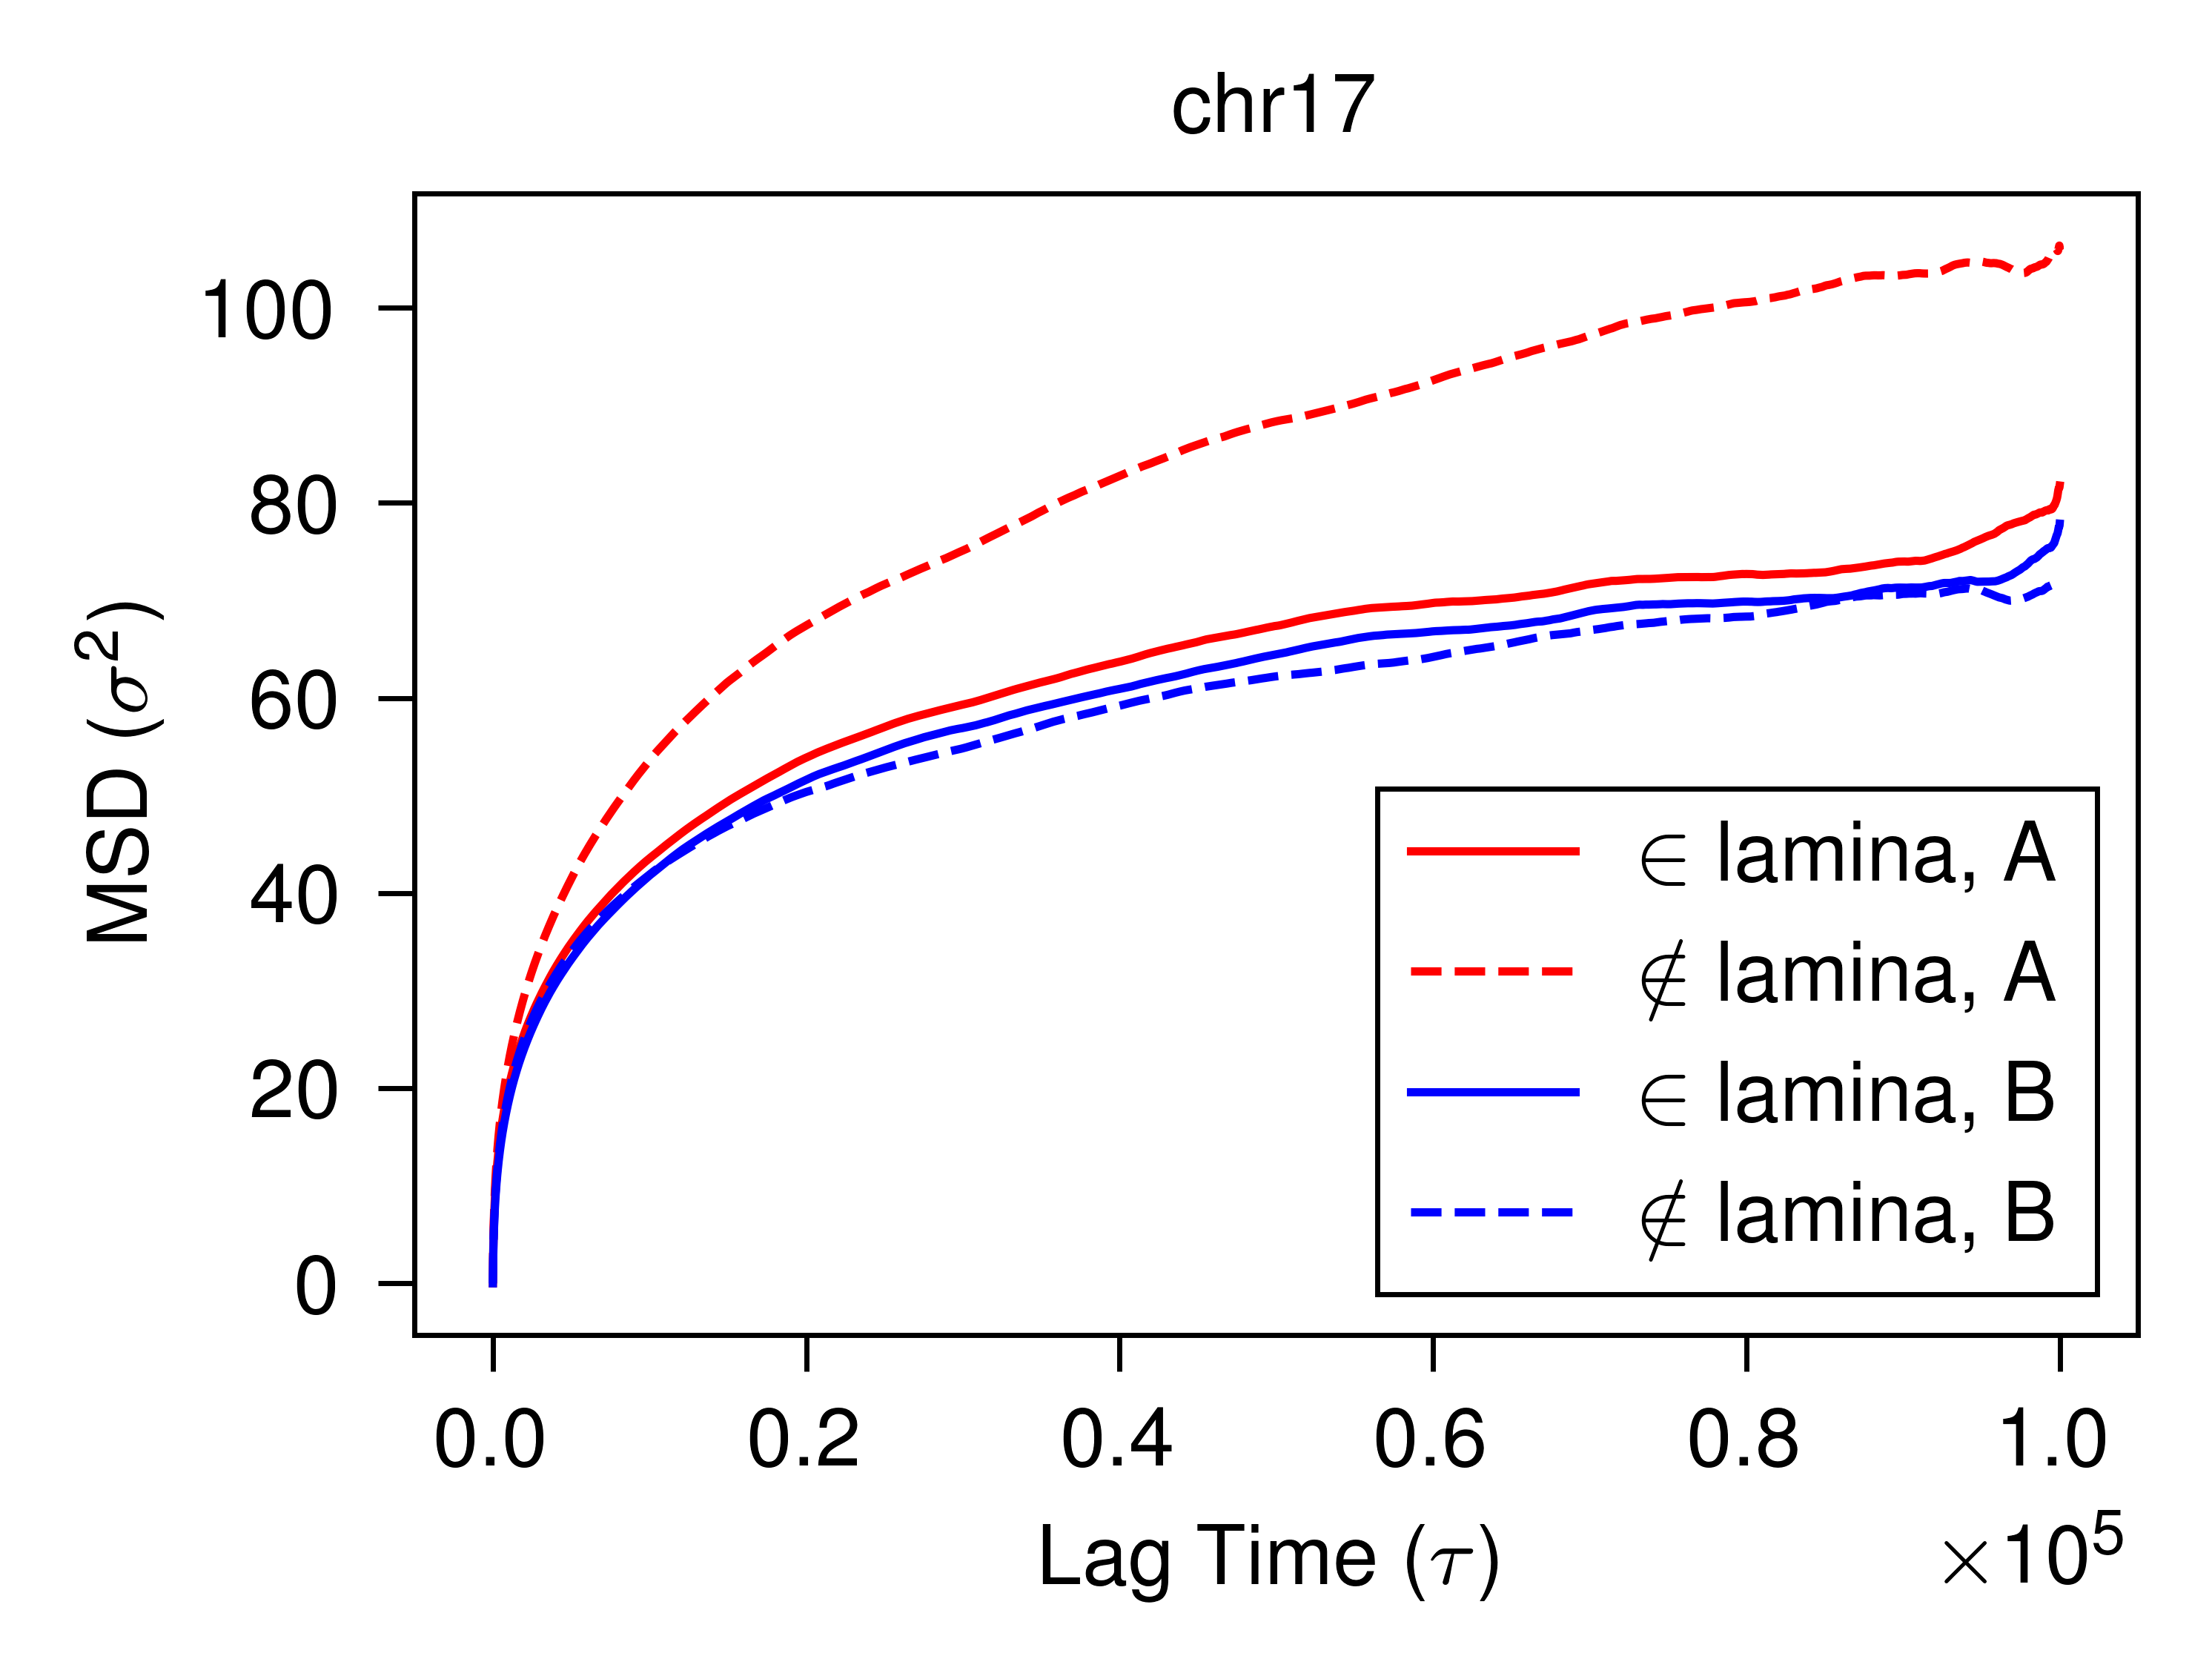

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

lag = np.arange(msd["complete"]["A"].shape[0]) * 1000 * 0.01  # in tau

ax.plot(
    lag,
    msd["complete"]["A"],
    label=r"$\in$ lamina, A",
    color="red",
)
ax.plot(
    lag,
    msd["nucleolus"]["A"],
    "--",
    label=r"$\notin$ lamina, A",
    color="red",
)
ax.plot(
    lag,
    msd["complete"]["B"],
    label=r"$\in$ lamina, B",
    color="blue",
)
ax.plot(
    lag,
    msd["nucleolus"]["B"],
    "--",
    label=r"$\notin$ lamina, B",
    color="blue",
)

ax.set_ylabel(r"MSD ($\sigma^2$)")
ax.set_xlabel(r"Lag Time ($\tau$)")

ax.legend()

ax.set_title(f"chr{chromosome}", fontsize=8)

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation
ax.xaxis.set_major_formatter(formatter)

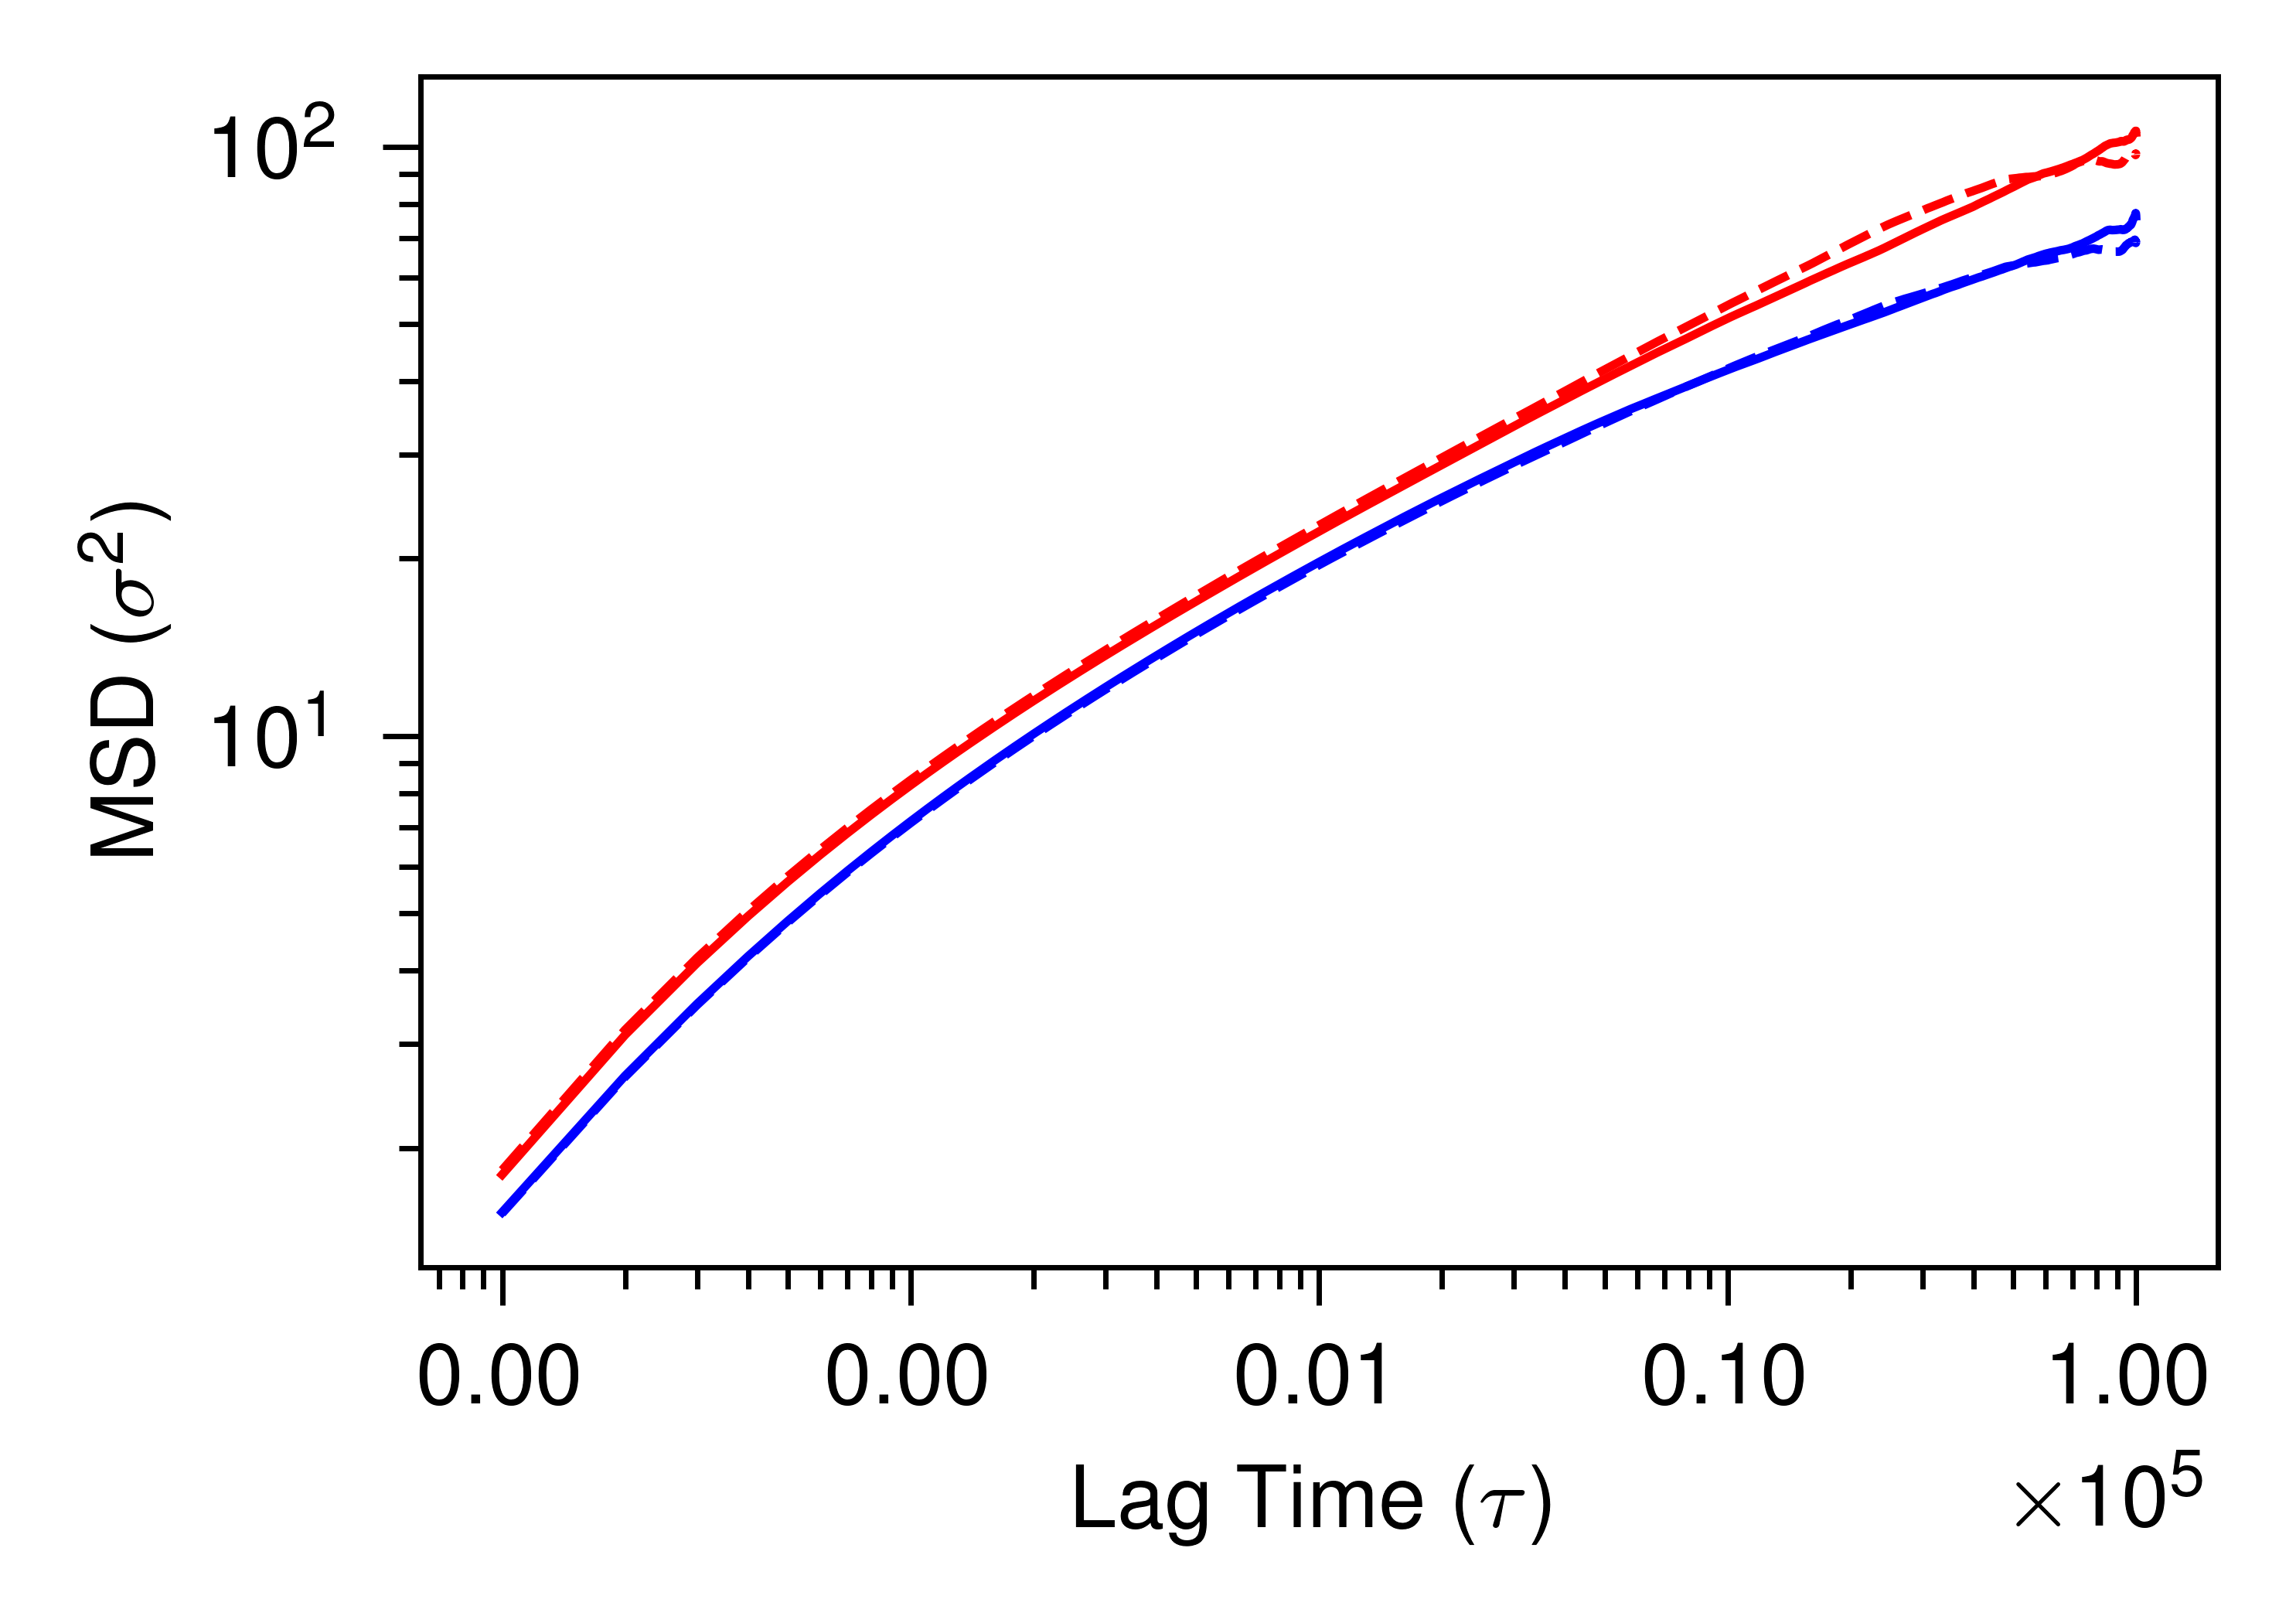

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

lag = np.arange(msd["complete"]["A"].shape[0]) * 1000 * 0.01  # in tau

ax.loglog(
    lag[1:],
    msd["complete"]["A"][1:],
    label="A",
    color="red",
)
ax.loglog(
    lag[1:],
    msd["nucleolus"]["A"][1:],
    "--",
    label="A",
    color="red",
)
ax.loglog(
    lag[1:],
    msd["complete"]["B"][1:],
    label="B",
    color="blue",
)
ax.loglog(
    lag[1:],
    msd["nucleolus"]["B"][1:],
    "--",
    label="B",
    color="blue",
)

ax.set_ylabel(r"MSD ($\sigma^2$)")
ax.set_xlabel(r"Lag Time ($\tau$)")

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation

# Apply formatter
ax.xaxis.set_major_formatter(formatter)

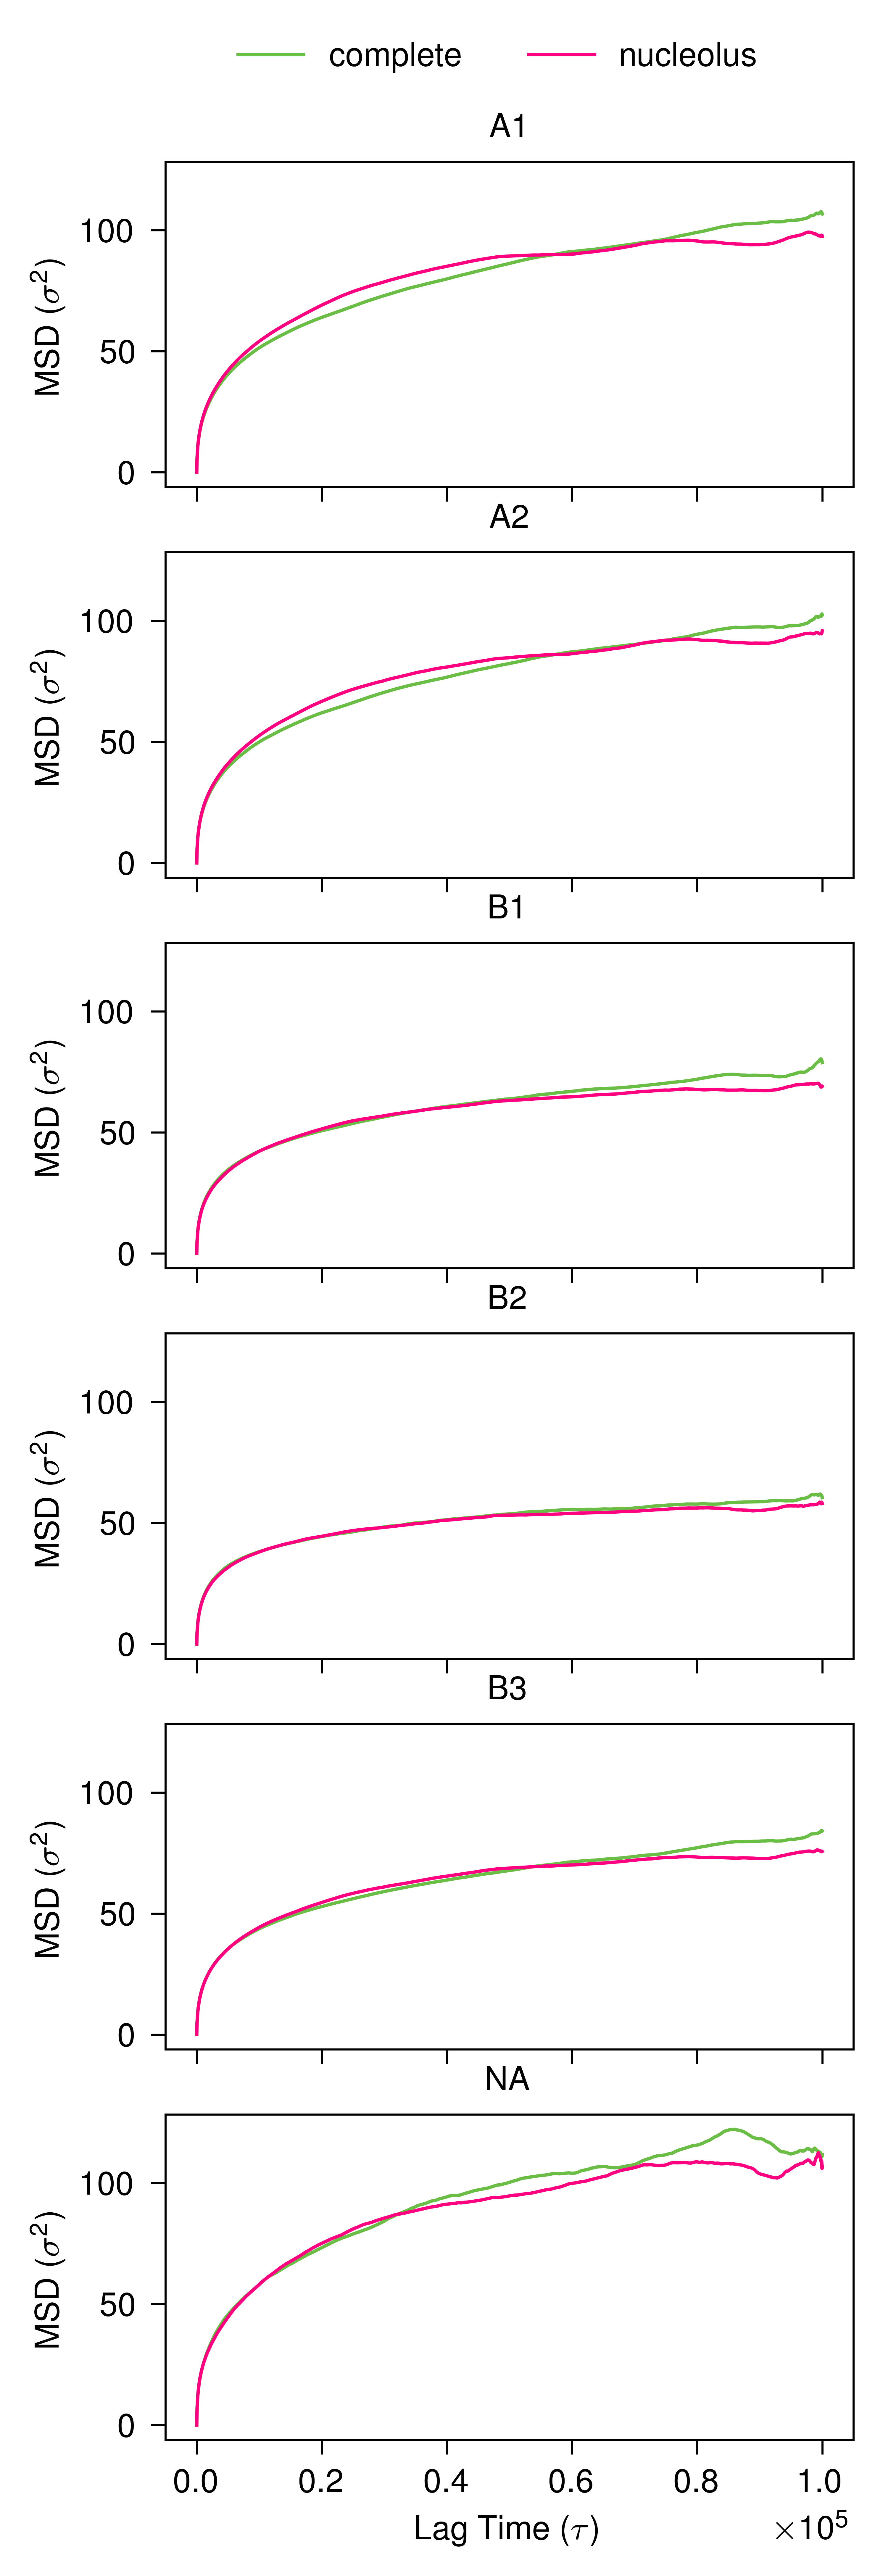

In [13]:
fig, ax = plt.subplots(6, 1, figsize=(3, 10), sharex=True, sharey=True)

lag = np.arange(msd["complete"]["A"].shape[0]) * 1000 * 0.01  # in tau

conditions = [
    "complete",
    "nucleolus",
    # "lamina",
    # "control",
]

colors = {
    "complete": "#6abd45",
    "nucleolus": "#ff0080",
    "control": "#404040",
    "lamina": "#25C8FA",
    # "isolation": "#FFC083",
}

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation

for i, subcompartment in enumerate(["A1", "A2", "B1", "B2", "B3", "NA"]):
    for condition in conditions:
        ax[i].plot(
            lag,
            msd[condition][subcompartment],
            label=condition,
            color=colors[condition],
        )

    ax[i].set_title(f"{subcompartment}")
    ax[i].set_ylabel(r"MSD ($\sigma^2$)")
    if i == 5:
        ax[i].set_xlabel(r"Lag Time ($\tau$)")

    ax[i].xaxis.set_major_formatter(formatter)

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.9),
)

### lamina contact

In [ ]:
data_path_lamina = f"/scratch/mm146/Polarization/{folder_num}_IMR-90_hg38_chr{chromosome}/7_analysis/msd/data/msd-average-per-compartment-lamina.h5"

msd_lamina = {}
with h5py.File(
    data_path_lamina,
    "r",
) as f_in:
    for group in f_in.keys():
        msd_lamina[group] = {}
        for compartment in f_in[group].keys():
            msd_lamina[group][compartment] = f_in[group][
                compartment
            ][()]

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

lag = np.arange(msd_lamina["in-contact"]["B"].shape[0]) * 1000 * 0.01  # in tau

ax.plot(
    lag,
    msd_lamina["in-contact"]["B"],
    label="in-contact",
    color="#25C8FA",
)
ax.plot(
    lag,
    msd_lamina["not-in-contact"]["B"],
    "--",
    label="not-in-contact",
    color="#404040",
)

ax.set_ylabel(r"MSD ($\sigma^2$)")
ax.set_xlabel(r"Lag Time ($\tau$)")

ax.legend()

ax.set_title(f"chr{chromosome}, B beads", fontsize=8)

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation
ax.xaxis.set_major_formatter(formatter)

In [ ]:
fig, ax = plt.subplots(4, 1, figsize=(3, 7), sharex=True, sharey=True)

lag = np.arange(msd_lamina["in-contact"]["B"].shape[0]) * 1000 * 0.01  # in tau

groups = ["in-contact", "not-in-contact"]
colors = {
    "in-contact": "#25C8FA",
    "not-in-contact": "#404040",
}

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation

for i, subcompartment in enumerate(["B", "B1", "B2", "B3"]):
    for group in groups:
        ax[i].plot(
            lag,
            msd_lamina[group][subcompartment],
            label=group,
            color=colors[group],
        )

    ax[i].set_title(f"{subcompartment}")
    ax[i].set_ylabel(r"MSD ($\sigma^2$)")
    if i == 3:
        ax[i].set_xlabel(r"Lag Time ($\tau$)")

    ax[i].xaxis.set_major_formatter(formatter)

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.92),
)